In [1]:
import pandas as pd  
import numpy as np  
import matplotlib.pyplot as plt 
from lightgbm import LGBMRegressor 
from sklearn.model_selection import GridSearchCV  
from scipy.stats import ttest_1samp  
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

读取公司基本数据

In [6]:
co_data = pd.read_csv("C:/Users/刘子暄/Desktop/金融计量学pre2/TRD_Co.csv", encoding='utf-8')
co_data.rename(columns={
    'Stkcd': 'ts_code',
    'Stknme': 'name',
    'Listdt': 'list_date',
    'Indcd': 'industry_code'  #行业代码是0001-0006，这个字段很重要
}, inplace=True)

# 再确保股票代码是6位数字
co_data['ts_code'] = co_data['ts_code'].astype(str).str.zfill(6)

print("公司数据共有", len(co_data), "只股票")
print("前3只股票的信息：")
print(co_data[['ts_code', 'name', 'industry_code']].head(3))

公司数据共有 5352 只股票
前3只股票的信息：
  ts_code  name  industry_code
0  000002   万科A              3
1  000006  深振业A              3
2  000007   全新好              3


读取月度个股回报率

In [7]:
mnth_data = pd.read_csv("C:/Users/刘子暄/Desktop/金融计量学pre2/TRD_Mnth.csv", encoding='utf-8')

mnth_data.rename(columns={
    'Stkcd': 'ts_code',
    'date': 'trade_month',  # 格式应该是199901（1999年1月）
    'close_price': 'close',
    'tmcap': 'total_mv',
    'cmcap': 'circ_mv',
    'ret': 'return_pct'  # 这就是每月的收益率
}, inplace=True)

In [8]:
# 1. 将 'Nov-00' 格式的字符串解析为 datetime 类型
# 格式说明：%b是月份缩写（如Nov），%y是年份后两位（如00→2000）
mnth_data['trade_month'] = pd.to_datetime(mnth_data['trade_month'], format='%b-%y')

# 2. 将 datetime 类型转换为 '2000-11' 这样的年月格式（period类型，也可以转成字符串）
mnth_data['trade_month'] = mnth_data['trade_month'].dt.to_period('M')  # 得到的是 period 类型（如2000-11）
# （可选）如果需要字符串格式，用下面这行：
# df['year_month'] = df['date'].dt.strftime('%Y-%m')

In [9]:
# 算“超额收益”：股票收益减去无风险收益（后面会读无风险收益数据）
# 先留个空，等下填
mnth_data['excess_return'] = 0.0
mnth_data['year_month']=mnth_data['trade_month']
# 确保股票代码是6位
mnth_data['ts_code'] = mnth_data['ts_code'].astype(str).str.zfill(6)
mnth_data['year'] = mnth_data['year_month'].dt.year

print("月度收益数据共有", len(mnth_data), "条月度记录")

月度收益数据共有 637884 条月度记录


In [10]:
mnth_data

,ts_code,trade_month,close,circ_mv,total_mv,return_pct,excess_return,year_month,year
0,000002,1999-01,7.85,2235682.38,3024264.91,-0.069905,0.0,1999-01,1999
1,000002,1999-02,7.68,2187266.33,2958771.28,-0.021656,0.0,1999-02,1999
2,000002,1999-03,7.84,2232834.38,3020412.35,0.020833,0.0,1999-03,1999
3,000002,1999-04,9.09,2588834.75,3501983.19,0.159439,0.0,1999-04,1999
4,000002,1999-05,11.25,3204003.41,4334137.62,0.237624,0.0,1999-05,1999
...,...,...,...,...,...,...,...,...,...
637879,920992,2023-08,7.44,207562.44,719678.15,-0.174251,0.0,2023-08,2023
637880,920992,2023-09,7.28,203098.73,704201.20,-0.021505,0.0,2023-09,2023
637881,920992,2023-10,6.61,184406.95,639391.47,-0.092033,0.0,2023-10,2023
637882,920992,2023-11,9.12,254431.37,882186.12,0.379727,0.0,2023-11,2023


读取无风险收益率

In [11]:
# 读取无风险收益率：比如存银行的利息，用来算“超额收益”
nrrate_data = pd.read_csv("C:/Users/刘子暄/Desktop/金融计量学pre2/TRD_Nrrate.csv", encoding='utf-8')

nrrate_data.rename(columns={
    'Clsdt': 'date',  # 格式应该是199901（1999年1月）
    'Nrrmtdt': 'risk_free_rate'  # 比如每月0.3%（0.003）
}, inplace=True)

# 处理时间：和月度收益数据的时间对应上
nrrate_data['date'] = pd.to_datetime(nrrate_data['date'])
nrrate_data['year_month'] = nrrate_data['date'].dt.to_period('M')
nrrate_data['year']=nrrate_data['year_month'].dt.year

#百分比转化为小数
nrrate_data['risk_free_rate']=nrrate_data['risk_free_rate']/100

#每月数据仅保存一条
nrrate_data= nrrate_data.drop_duplicates(subset=['year_month'], keep='first').reset_index(drop=True)
nrrate_data

,date,risk_free_rate,year_month,year
0,1999-01-01,0.003097,1999-01,1999
1,1999-02-01,0.003097,1999-02,1999
2,1999-03-01,0.003097,1999-03,1999
3,1999-04-01,0.003097,1999-04,1999
4,1999-05-01,0.003097,1999-05,1999
...,...,...,...,...
295,2023-08-01,0.001365,2023-08,2023
296,2023-09-01,0.001283,2023-09,2023
297,2023-10-01,0.001283,2023-10,2023
298,2023-11-01,0.001283,2023-11,2023


处理得到年度个股总收益和年度无风险收益
文中计算公式：
个股年度总收益 = （1+月度个股收益）连乘 - 1
年度无风险收益 = （1+月度无风险收益）连乘 - 1

In [12]:
mnth_data['annual_rp'] = (
    mnth_data.groupby(['ts_code', 'year'])['return_pct']
    .transform(lambda r: (1 + r).prod() - 1)
)

In [13]:
nrrate_data['annual_rf'] = (
    nrrate_data.groupby('year')['risk_free_rate']
    .transform(lambda r: (1 + r).prod() - 1)
)
nrrate_data

,date,risk_free_rate,year_month,year,annual_rf
0,1999-01-01,0.003097,1999-01,1999,0.030124
1,1999-02-01,0.003097,1999-02,1999,0.030124
2,1999-03-01,0.003097,1999-03,1999,0.030124
3,1999-04-01,0.003097,1999-04,1999,0.030124
4,1999-05-01,0.003097,1999-05,1999,0.030124
...,...,...,...,...,...
295,2023-08-01,0.001365,2023-08,2023,0.016171
296,2023-09-01,0.001283,2023-09,2023,0.016171
297,2023-10-01,0.001283,2023-10,2023,0.016171
298,2023-11-01,0.001283,2023-11,2023,0.016171


In [14]:
# 把无风险收益率合并到月度收益数据里，算“超额收益”
mnth_data = pd.merge(
    mnth_data,  
    nrrate_data[['year_month', 'annual_rf','risk_free_rate']],  # 无风险收益数据
    on='year_month',  # 按“年月”匹配（1999-01对应1999-01的无风险收益）
    how='left'
)

In [15]:
# 算超额收益：股票收益 - 无风险收益
mnth_data['excess_return'] = mnth_data['annual_rp'] - mnth_data['annual_rf']
# 处理异常值：
mnth_data['excess_return'] = mnth_data['excess_return'].clip(
    mnth_data['excess_return'].quantile(0.01),  # 1%分位（最低值）
    mnth_data['excess_return'].quantile(0.99)   # 99%分位（最高值）
)

In [16]:
mnth_data['monthly_excess_return']=mnth_data['return_pct']-mnth_data['risk_free_rate']
mnth_data

,ts_code,trade_month,close,circ_mv,total_mv,return_pct,excess_return,year_month,year,annual_rp,annual_rf,risk_free_rate,monthly_excess_return
0,000002,1999-01,7.85,2235682.38,3024264.91,-0.069905,0.250319,1999-01,1999,0.280443,0.030124,0.003097,-0.073002
1,000002,1999-02,7.68,2187266.33,2958771.28,-0.021656,0.250319,1999-02,1999,0.280443,0.030124,0.003097,-0.024753
2,000002,1999-03,7.84,2232834.38,3020412.35,0.020833,0.250319,1999-03,1999,0.280443,0.030124,0.003097,0.017736
3,000002,1999-04,9.09,2588834.75,3501983.19,0.159439,0.250319,1999-04,1999,0.280443,0.030124,0.003097,0.156342
4,000002,1999-05,11.25,3204003.41,4334137.62,0.237624,0.250319,1999-05,1999,0.280443,0.030124,0.003097,0.234527
...,...,...,...,...,...,...,...,...,...,...,...,...,...
637879,920992,2023-08,7.44,207562.44,719678.15,-0.174251,0.101222,2023-08,2023,0.117393,0.016171,0.001365,-0.175616
637880,920992,2023-09,7.28,203098.73,704201.20,-0.021505,0.101222,2023-09,2023,0.117393,0.016171,0.001283,-0.022788
637881,920992,2023-10,6.61,184406.95,639391.47,-0.092033,0.101222,2023-10,2023,0.117393,0.016171,0.001283,-0.093316
637882,920992,2023-11,9.12,254431.37,882186.12,0.379727,0.101222,2023-11,2023,0.117393,0.016171,0.001283,0.378444


读取资产负债表

In [17]:
# 读取资产负债表：有多少钱、有多少存货、欠多少钱
asset_li = pd.read_csv("C:/Users/刘子暄/Desktop/金融计量学pre2/FS_asset_li.csv", encoding='utf-8')
asset_li.rename(columns={
    'Stkcd': 'ts_code',
    'Typrep': 'report_type',
    'Accper':'report_date',
    'A001101000':'cash',
    'A001123000':'inventory',
    'A001212000':'fixed_assets',
    'A001000000':'total_assets',
    'A002000000':'total_liab',
    'A003000000':'total_eq',
    'A002100000':'current_liab',
    'A001100000':'current_assets'
}, inplace=True)
# 只留“合并报表”（A类）
asset_li = asset_li[asset_li['report_type'] == 'A']

# 处理时间：提取“年份”（比如19991231→1999年）
asset_li['report_date'] = pd.to_datetime(asset_li['report_date'])  # 转换日期格式
#asset_li['report_month'] = asset_li['report_date'].dt.month  # 提取月份
#asset_li = asset_li[asset_li['report_month'] == 12]
asset_li['year'] = asset_li['report_date'].dt.year
asset_li['year_month'] = asset_li['report_date'].dt.to_period('M')
# 确保股票代码是6位
asset_li['ts_code'] = asset_li['ts_code'].astype(str).str.zfill(6)

print("资产负债表共有", len(asset_li), "条年度记录")

资产负债表共有 276979 条年度记录


In [18]:
asset_li

,ts_code,ShortName,report_date,report_type,cash,inventory,current_assets,fixed_assets,total_assets,current_liab,total_liab,total_eq,year,year_month
0,000002,深万科A,1999-06-30,A,4.680110e+08,2.658693e+09,3.832600e+09,2.091754e+08,4.341586e+09,2.111074e+09,2.188179e+09,2.153407e+09,1999,1999-06
1,000002,深万科A,1999-12-31,A,7.609226e+08,2.462247e+09,3.817275e+09,3.789304e+08,4.494664e+09,2.289915e+09,2.348354e+09,2.146311e+09,1999,1999-12
2,000002,深万科A,2000-01-01,A,7.728318e+08,2.541902e+09,3.896930e+09,2.992756e+08,4.494664e+09,2.265108e+09,2.348354e+09,2.146311e+09,2000,2000-01
3,000002,深万科A,2000-06-30,A,9.119660e+08,2.981957e+09,4.450482e+09,3.890573e+08,5.045245e+09,2.059944e+09,2.157344e+09,2.887902e+09,2000,2000-06
4,000002,深万科A,2000-12-31,A,9.957452e+08,3.499235e+09,5.032578e+09,3.382824e+08,5.622247e+09,2.532706e+09,2.656602e+09,2.965645e+09,2000,2000-12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
513292,920992,中科美菱,2023-01-01,A,5.820909e+08,4.807474e+07,6.494524e+08,1.312332e+08,8.071261e+08,1.902570e+08,2.059728e+08,6.011533e+08,2023,2023-01
513294,920992,中科美菱,2023-03-31,A,4.950991e+08,4.999121e+07,6.604328e+08,1.287153e+08,8.135207e+08,1.924133e+08,2.064742e+08,6.070465e+08,2023,2023-03
513296,920992,中科美菱,2023-06-30,A,5.293437e+08,4.657419e+07,6.035080e+08,1.264304e+08,7.527358e+08,1.468454e+08,1.597234e+08,5.930124e+08,2023,2023-06
513298,920992,中科美菱,2023-09-30,A,2.577674e+08,3.599126e+07,5.923540e+08,1.239251e+08,7.378876e+08,1.293289e+08,1.403704e+08,5.975172e+08,2023,2023-09


读取现金流量表

In [19]:
# 读取现金流量表：经营活动赚了多少现金
currency = pd.read_csv("C:/Users/刘子暄/Desktop/金融计量学pre2/FS_currency.csv", encoding='utf-8')

# 给数据“改名”
currency.rename(columns={
    'Stkcd': 'ts_code',
    'Accper': 'report_date',
    'Typrep': 'report_type',
    'C001000000': 'operate_cash',
    'C002000000':'invest_cash',
    'C003000000':'finance_cash'
}, inplace=True)

# 只留“合并报表”（A类）
currency = currency[currency['report_type'] == 'A']

# 提取年份
currency['report_date'] = pd.to_datetime(currency['report_date'])  # 转换日期格式
#currency['report_month'] = currency['report_date'].dt.month  # 提取月份
#currency = currency[currency['report_month'] == 12]
currency['year'] = currency['report_date'].dt.year
currency['year_month'] = currency['report_date'].dt.to_period('M')
# 确保股票代码是6位
currency['ts_code'] = currency['ts_code'].astype(str).str.zfill(6)

# 只留需要的字段：股票代码、年份、经营现金流
currency = currency[['ts_code', 'year', 'operate_cash','invest_cash','finance_cash','year_month']]
currency

,ts_code,year,operate_cash,invest_cash,finance_cash,year_month
0,000002,1999,-2.651082e+08,-6.739426e+07,2.238659e+08,1999-06
1,000002,1999,4.278587e+07,-5.243319e+07,1.938086e+08,1999-12
2,000002,2000,-3.032047e+08,-1.102003e+07,4.653021e+08,2000-06
3,000002,2000,8.604837e+07,-3.646198e+07,1.734380e+08,2000-12
4,000002,2001,-7.249809e+08,-1.742534e+07,5.096891e+08,2001-06
...,...,...,...,...,...,...
498977,920992,2023,-3.801038e+07,-8.544439e+06,3.132168e+08,2023-01
498979,920992,2023,1.088624e+07,-9.774855e+07,-4.395854e+06,2023-03
498982,920992,2023,-1.367915e+07,-1.656821e+07,-2.687459e+07,2023-06
498983,920992,2023,-1.841902e+07,-2.873003e+08,-2.308448e+07,2023-09


读取利润表

In [20]:
# 读取利润表：赚了多少净利润、有多少收入
profit = pd.read_csv("C:/Users/刘子暄/Desktop/金融计量学pre2/FS_profit.csv", encoding='utf-8')

# 给数据“改名”
profit.rename(columns={
    'Stkcd': 'ts_code',
    'Accper': 'report_date',
    'Typrep': 'report_type',
    'B002000000': 'net_profit',
    'B001100000': 'revenue',
    'B001200000': 'cost',
    'B001216000': 'rd_expense',
    'B001300000':'operating_profit'
}, inplace=True)

# 只留“合并报表”（A类）
profit = profit[profit['report_type'] == 'A']

# 提取年份
profit['report_date'] = pd.to_datetime(profit['report_date'])  # 转换日期格式
#profit['report_month'] = profit['report_date'].dt.month  # 提取月份
#profit = profit[profit['report_month'] == 12]
profit['year'] = profit['report_date'].dt.year
profit['year_month'] = profit['report_date'].dt.to_period('M')

# 确保股票代码是6位
profit['ts_code'] = profit['ts_code'].astype(str).str.zfill(6)

# 只留需要的字段：股票代码、年份、净利润、收入、成本
profit = profit[['ts_code', 'year', 'net_profit', 'revenue', 'cost','rd_expense','operating_profit','year_month']]
profit

,ts_code,year,net_profit,revenue,cost,rd_expense,operating_profit,year_month
0,000002,1999,8.669298e+07,9.933363e+08,8.999736e+08,NaN,1.086971e+08,1999-06
1,000002,1999,2.401269e+08,2.872796e+09,2.618778e+09,NaN,2.707768e+08,1999-12
2,000002,2000,2.401269e+08,2.872796e+09,2.618778e+09,NaN,2.707768e+08,2000-01
3,000002,2000,1.198963e+08,1.404665e+09,1.279961e+09,NaN,1.399674e+08,2000-06
4,000002,2000,3.111773e+08,3.783669e+09,3.436558e+09,NaN,3.688866e+08,2000-12
...,...,...,...,...,...,...,...,...
514672,920992,2023,5.258694e+07,4.064891e+08,3.719927e+08,28272829.67,5.934591e+07,2023-01
514674,920992,2023,5.290570e+06,7.681011e+07,7.380420e+07,8189437.30,5.812255e+06,2023-03
514676,920992,2023,8.290187e+06,1.447662e+08,1.451346e+08,16443463.53,1.013550e+07,2023-06
514678,920992,2023,1.231051e+07,2.256859e+08,2.267715e+08,25556137.44,1.429199e+07,2023-09


In [21]:
profit['rd_expense'].isna().sum()

169176

合并三张报表

In [22]:
# 第一步：合并资产负债表和利润表（按股票代码+年份）
finance_data = pd.merge(
    asset_li[['ts_code', 'year_month', 'cash', 'inventory', 'fixed_assets', 'total_assets', 'total_liab', 'total_eq','current_assets','current_liab']],
    profit,
    on=['ts_code', 'year_month'],
    how='left'
)

# 第二步：再合并现金流量表
finance_data = pd.merge(
    finance_data,
    currency,
    on=['ts_code', 'year_month'],
    how='left'
)

# 填充缺失值：如果某家公司某一年的数据缺了，用“同行业同年的平均值”填
# 先把行业代码合并进来（从公司基本数据里拿）
finance_data = pd.merge(
    finance_data,
    co_data[['ts_code', 'industry_code']],
    on='ts_code',
    how='left'
)

# 填充缺失值（比如存货缺了，用同行业同年的平均存货填）
for col in ['cash', 'inventory', 'fixed_assets', 'total_assets', 'total_liab', 'total_eq', 'net_profit', 'revenue', 'cost', 'operate_cash']:
    finance_data[col] = finance_data.groupby(['year_month', 'industry_code'])[col].transform(
        lambda x: x.fillna(x.median())  # 用中位数更稳妥，避免极端值影响
    )

print("三张财务表合并好了", len(finance_data), "条年度财务记录")

三张财务表合并好了 276979 条年度财务记录


In [23]:
#用行业均值填充研发费用缺失值
finance_data['year']=finance_data['year_month'].dt.year
finance_data['rd_expense'] = finance_data.groupby(['year', 'industry_code'])['rd_expense'].transform(
    lambda x: x.fillna(x.median())
)

In [24]:
#若某行业某年度所有公司都缺失（极端情况），用0填充
finance_data['rd_expense'] = finance_data['rd_expense'].fillna(0)

In [25]:
finance_data.isna().sum()

ts_code                 0
year_month              0
cash                    0
inventory               0
fixed_assets            0
total_assets            0
total_liab              0
total_eq                0
current_assets          4
current_liab            3
year_x                 24
net_profit              1
revenue                 1
cost                    1
rd_expense              0
operating_profit       24
year_y              10160
operate_cash         2066
invest_cash         10586
finance_cash        14099
industry_code           0
year                    0
dtype: int64

In [26]:
finance_data.drop(columns=['year_x','year_y'],inplace=True)

In [27]:
finance_data['ts_code'].nunique()

5184

In [28]:
#填补NaN
finance_data['current_assets'] = finance_data.groupby(['year', 'industry_code'])['current_assets'].transform(
    lambda x: x.fillna(x.median())
)
finance_data['current_assets'] = finance_data['current_assets'].fillna(0)


finance_data['current_liab'] = finance_data.groupby(['year', 'industry_code'])['current_liab'].transform(
    lambda x: x.fillna(x.median())
)
finance_data['current_liab'] = finance_data['current_liab'].fillna(0)


finance_data['net_profit'] = finance_data.groupby(['year', 'industry_code'])['net_profit'].transform(
    lambda x: x.fillna(x.median())
)
finance_data['net_profit'] = finance_data['net_profit'].fillna(0)


finance_data['revenue'] = finance_data.groupby(['year', 'industry_code'])['revenue'].transform(
    lambda x: x.fillna(x.median())
)
finance_data['revenue'] = finance_data['revenue'].fillna(0)


finance_data['cost'] = finance_data.groupby(['year', 'industry_code'])['cost'].transform(
    lambda x: x.fillna(x.median())
)
finance_data['cost'] = finance_data['cost'].fillna(0)


finance_data['operating_profit'] = finance_data.groupby(['year', 'industry_code'])['operating_profit'].transform(
    lambda x: x.fillna(x.median())
)
finance_data['operating_profit'] = finance_data['operating_profit'].fillna(0)


finance_data['operate_cash'] = finance_data.groupby(['year', 'industry_code'])['operate_cash'].transform(
    lambda x: x.fillna(x.median())
)
finance_data['operate_cash'] = finance_data['operate_cash'].fillna(0)


finance_data['invest_cash'] = finance_data.groupby(['year', 'industry_code'])['invest_cash'].transform(
    lambda x: x.fillna(x.median())
)
finance_data['invest_cash'] = finance_data['invest_cash'].fillna(0)


finance_data['finance_cash'] = finance_data.groupby(['year', 'industry_code'])['finance_cash'].transform(
    lambda x: x.fillna(x.median())
)
finance_data['finance_cash'] = finance_data['finance_cash'].fillna(0)

In [29]:
finance_data.isna().sum()

ts_code             0
year_month          0
cash                0
inventory           0
fixed_assets        0
total_assets        0
total_liab          0
total_eq            0
current_assets      0
current_liab        0
net_profit          0
revenue             0
cost                0
rd_expense          0
operating_profit    0
operate_cash        0
invest_cash         0
finance_cash        0
industry_code       0
year                0
dtype: int64

In [30]:
finance_data['year_month'].dtype

period[M]

In [31]:
finance_data

,ts_code,year_month,cash,inventory,fixed_assets,total_assets,total_liab,total_eq,current_assets,current_liab,net_profit,revenue,cost,rd_expense,operating_profit,operate_cash,invest_cash,finance_cash,industry_code,year
0,000002,1999-06,4.680110e+08,2.658693e+09,2.091754e+08,4.341586e+09,2.188179e+09,2.153407e+09,3.832600e+09,2.111074e+09,8.669298e+07,9.933363e+08,8.999736e+08,0.00,1.086971e+08,-2.651082e+08,-6.739426e+07,2.238659e+08,3,1999
1,000002,1999-12,7.609226e+08,2.462247e+09,3.789304e+08,4.494664e+09,2.348354e+09,2.146311e+09,3.817275e+09,2.289915e+09,2.401269e+08,2.872796e+09,2.618778e+09,0.00,2.707768e+08,4.278587e+07,-5.243319e+07,1.938086e+08,3,1999
2,000002,2000-01,7.728318e+08,2.541902e+09,2.992756e+08,4.494664e+09,2.348354e+09,2.146311e+09,3.896930e+09,2.265108e+09,2.401269e+08,2.872796e+09,2.618778e+09,0.00,2.707768e+08,8.028110e+06,-2.069352e+07,2.826014e+07,3,2000
3,000002,2000-06,9.119660e+08,2.981957e+09,3.890573e+08,5.045245e+09,2.157344e+09,2.887902e+09,4.450482e+09,2.059944e+09,1.198963e+08,1.404665e+09,1.279961e+09,0.00,1.399674e+08,-3.032047e+08,-1.102003e+07,4.653021e+08,3,2000
4,000002,2000-12,9.957452e+08,3.499235e+09,3.382824e+08,5.622247e+09,2.656602e+09,2.965645e+09,5.032578e+09,2.532706e+09,3.111773e+08,3.783669e+09,3.436558e+09,0.00,3.688866e+08,8.604837e+07,-3.646198e+07,1.734380e+08,3,2000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
276974,920992,2023-01,5.820909e+08,4.807474e+07,1.312332e+08,8.071261e+08,2.059728e+08,6.011533e+08,6.494524e+08,1.902570e+08,5.258694e+07,4.064891e+08,3.719927e+08,28272829.67,5.934591e+07,-3.801038e+07,-8.544439e+06,3.132168e+08,5,2023
276975,920992,2023-03,4.950991e+08,4.999121e+07,1.287153e+08,8.135207e+08,2.064742e+08,6.070465e+08,6.604328e+08,1.924133e+08,5.290570e+06,7.681011e+07,7.380420e+07,8189437.30,5.812255e+06,1.088624e+07,-9.774855e+07,-4.395854e+06,5,2023
276976,920992,2023-06,5.293437e+08,4.657419e+07,1.264304e+08,7.527358e+08,1.597234e+08,5.930124e+08,6.035080e+08,1.468454e+08,8.290187e+06,1.447662e+08,1.451346e+08,16443463.53,1.013550e+07,-1.367915e+07,-1.656821e+07,-2.687459e+07,5,2023
276977,920992,2023-09,2.577674e+08,3.599126e+07,1.239251e+08,7.378876e+08,1.403704e+08,5.975172e+08,5.923540e+08,1.293289e+08,1.231051e+07,2.256859e+08,2.267715e+08,25556137.44,1.429199e+07,-1.841902e+07,-2.873003e+08,-2.308448e+07,5,2023


In [32]:
# 填充其他月份数据
df1 = finance_data.copy()

# 确保数据类型正确
df1['year_month'] = pd.to_datetime(df1['year_month'].astype(str))
df1['ts_code'] = df1['ts_code'].astype(str).str.strip()
df1['year'] = df1['year'].astype(int)

# 排序
df1 = df1.sort_values(['ts_code', 'year_month'])

# 取财务字段（排除标识列）
id_cols = ['ts_code', 'year_month', 'year']
val_cols = [c for c in df1.columns if c not in id_cols]

print(f"原始数据形状: {df1.shape}")
print(f"股票代码数量: {df1['ts_code'].nunique()}")
print(f"年份范围: {df1['year'].min()} - {df1['year'].max()}")

# === 更安全的补全函数 ===
def expand_and_fill(g):
    # 获取分组信息
    ts_code_val = g['ts_code'].iloc[0]
    year_val = g['year'].iloc[0]
    
    # 构造完整月份范围
    full_months = pd.date_range(
        start=f"{year_val}-01-01",
        end=f"{year_val}-12-01",
        freq='MS'
    )
    
    # 创建完整月份的DataFrame
    result = pd.DataFrame({
        'year_month': full_months,
        'ts_code': ts_code_val,
        'year': year_val
    })
    
    # 合并原始数据
    result = result.merge(
        g[['year_month'] + val_cols],
        on='year_month',
        how='left'
    )
    
    # 对财务数据列进行填充
    # 先向后填充（用未来的数据填充过去的空缺）
    # 再向前填充（用过去的数据填充未来的空缺）
    result[val_cols] = result[val_cols].bfill().ffill()
    
    return result

# 按股票和年份分组处理
df_filled2 = pd.DataFrame()

# 分批处理，避免内存问题
for (ts_code, year), group in df1.groupby(['ts_code', 'year']):
    try:
        filled_group = expand_and_fill(group)
        df_filled2 = pd.concat([df_filled2, filled_group], ignore_index=True)
    except Exception as e:
        print(f"处理股票 {ts_code}, 年份 {year} 时出错: {e}")
        continue

# 检查结果
print(f"\n填充后数据形状: {df_filled2.shape}")
print(f"填充后股票代码数量: {df_filled2['ts_code'].nunique()}")

# 检查缺失值
print("\n缺失值统计:")
print(df_filled2.isnull().sum())

# 如果有缺失值，进一步处理
if df_filled2['ts_code'].isnull().sum() > 0:
    print("\n发现ts_code缺失值，尝试修复...")
    
    # 方法1：使用原始数据填充
    # 创建一个字典，映射(year_month, year)到ts_code
    ts_code_map = df1.set_index(['year_month', 'year'])['ts_code'].to_dict()
    
    # 填充缺失的ts_code
    missing_idx = df_filled2[df_filled2['ts_code'].isnull()].index
    for idx in missing_idx:
        row = df_filled2.loc[idx]
        key = (row['year_month'], row['year'])
        if key in ts_code_map:
            df_filled2.at[idx, 'ts_code'] = ts_code_map[key]
    
    # 如果仍有缺失，使用前向填充
    df_filled2['ts_code'] = df_filled2['ts_code'].ffill().bfill()
    
    print(f"修复后ts_code缺失值: {df_filled2['ts_code'].isnull().sum()}")

# 确保数据类型
df_filled2['ts_code'] = df_filled2['ts_code'].astype(str)
df_filled2['year'] = df_filled2['year'].astype(int)

# 排序最终结果
df_filled2 = df_filled2.sort_values(['ts_code', 'year_month']).reset_index(drop=True)

# 验证每个股票每年都有12个月的数据
print("\n验证数据完整性:")
for ts_code in df_filled2['ts_code'].unique()[:5]:  # 只检查前5个股票
    stock_data = df_filled2[df_filled2['ts_code'] == ts_code]
    years = stock_data['year'].unique()
    print(f"股票 {ts_code}: {len(years)} 年数据")
    
    for year in years[:3]:  # 只检查前3年
        year_data = stock_data[stock_data['year'] == year]
        print(f"  年份 {year}: {len(year_data)} 个月")

df_filled2

原始数据形状: (276979, 20)
股票代码数量: 5184
年份范围: 1999 - 2023

填充后数据形状: (706152, 20)
填充后股票代码数量: 5184

缺失值统计:
year_month          0
ts_code             0
year                0
cash                0
inventory           0
fixed_assets        0
total_assets        0
total_liab          0
total_eq            0
current_assets      0
current_liab        0
net_profit          0
revenue             0
cost                0
rd_expense          0
operating_profit    0
operate_cash        0
invest_cash         0
finance_cash        0
industry_code       0
dtype: int64

验证数据完整性:
股票 000002: 25 年数据
  年份 1999: 12 个月
  年份 2000: 12 个月
  年份 2001: 12 个月
股票 000006: 25 年数据
  年份 1999: 12 个月
  年份 2000: 12 个月
  年份 2001: 12 个月
股票 000007: 25 年数据
  年份 1999: 12 个月
  年份 2000: 12 个月
  年份 2001: 12 个月
股票 000008: 25 年数据
  年份 1999: 12 个月
  年份 2000: 12 个月
  年份 2001: 12 个月
股票 000009: 25 年数据
  年份 1999: 12 个月
  年份 2000: 12 个月
  年份 2001: 12 个月


,year_month,ts_code,year,cash,inventory,fixed_assets,total_assets,total_liab,total_eq,current_assets,current_liab,net_profit,revenue,cost,rd_expense,operating_profit,operate_cash,invest_cash,finance_cash,industry_code
0,1999-01-01,000002,1999,4.680110e+08,2.658693e+09,2.091754e+08,4.341586e+09,2.188179e+09,2.153407e+09,3.832600e+09,2.111074e+09,86692984.86,9.933363e+08,8.999736e+08,0.00,1.086971e+08,-2.651082e+08,-6.739426e+07,2.238659e+08,3.0
1,1999-02-01,000002,1999,4.680110e+08,2.658693e+09,2.091754e+08,4.341586e+09,2.188179e+09,2.153407e+09,3.832600e+09,2.111074e+09,86692984.86,9.933363e+08,8.999736e+08,0.00,1.086971e+08,-2.651082e+08,-6.739426e+07,2.238659e+08,3.0
2,1999-03-01,000002,1999,4.680110e+08,2.658693e+09,2.091754e+08,4.341586e+09,2.188179e+09,2.153407e+09,3.832600e+09,2.111074e+09,86692984.86,9.933363e+08,8.999736e+08,0.00,1.086971e+08,-2.651082e+08,-6.739426e+07,2.238659e+08,3.0
3,1999-04-01,000002,1999,4.680110e+08,2.658693e+09,2.091754e+08,4.341586e+09,2.188179e+09,2.153407e+09,3.832600e+09,2.111074e+09,86692984.86,9.933363e+08,8.999736e+08,0.00,1.086971e+08,-2.651082e+08,-6.739426e+07,2.238659e+08,3.0
4,1999-05-01,000002,1999,4.680110e+08,2.658693e+09,2.091754e+08,4.341586e+09,2.188179e+09,2.153407e+09,3.832600e+09,2.111074e+09,86692984.86,9.933363e+08,8.999736e+08,0.00,1.086971e+08,-2.651082e+08,-6.739426e+07,2.238659e+08,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
706147,2023-08-01,920992,2023,2.577674e+08,3.599126e+07,1.239251e+08,7.378876e+08,1.403704e+08,5.975172e+08,5.923540e+08,1.293289e+08,12310510.11,2.256859e+08,2.267715e+08,25556137.44,1.429199e+07,-1.841902e+07,-2.873003e+08,-2.308448e+07,5.0
706148,2023-09-01,920992,2023,2.577674e+08,3.599126e+07,1.239251e+08,7.378876e+08,1.403704e+08,5.975172e+08,5.923540e+08,1.293289e+08,12310510.11,2.256859e+08,2.267715e+08,25556137.44,1.429199e+07,-1.841902e+07,-2.873003e+08,-2.308448e+07,5.0
706149,2023-10-01,920992,2023,5.572548e+08,2.739697e+07,1.213872e+08,7.328239e+08,1.313039e+08,6.015200e+08,5.908444e+08,1.208743e+08,16126507.82,3.027857e+08,3.034225e+08,33335275.72,1.914188e+07,-9.706150e+06,5.085655e+06,-2.474023e+07,5.0
706150,2023-11-01,920992,2023,5.572548e+08,2.739697e+07,1.213872e+08,7.328239e+08,1.313039e+08,6.015200e+08,5.908444e+08,1.208743e+08,16126507.82,3.027857e+08,3.034225e+08,33335275.72,1.914188e+07,-9.706150e+06,5.085655e+06,-2.474023e+07,5.0


In [33]:
df_filled2['year_month'].dtype

dtype('<M8[ns]')

构建20个核心会计变量+5类转换 → 100个全量信号

In [34]:
# ========== 第一步：明确20个核心会计变量 ========== 
core_20_vars = [
    # 一、资产负债表核心变量（8个）
    'cash',               # 货币资金
    'inventory',          # 存货净额
    'fixed_assets',       # 固定资产
    'total_assets',       # 总资产
    'total_liab',         # 总负债
    'total_eq',           # 总所有者权益
    'current_assets',     # 流动资产
    'current_liab',       # 流动负债
    # 二、利润表核心变量（6个）
    'net_profit',         # 净利润
    'revenue',            # 营业收入
    'cost',               # 营业成本
    'gross_profit',       # 毛利润（营业收入-营业成本）
    'operating_profit',   # 营业利润
    'rd_expense',         # 研发费用
    # 三、现金流量表核心变量（3个）
    'operate_cash',       # 经营活动现金流量
    'invest_cash',        # 投资活动现金流量
    'finance_cash',       # 筹资活动现金流量）
    # 四、衍生核心变量（3个）
    'profit_margin',      # 销售净利率
    'asset_turnover',     # 资产周转率
    'eq_ratio',           # 权益比率
]

# ========== 第二步：给推导变量赋值 ==========

# 使用 df_filled 作为新的财务数据集
finance_extended = df_filled2.copy()  # 基于已经填充的月度数据

# 1. 毛利润 = 营业收入 - 营业成本（直接计算）
finance_extended['gross_profit'] = finance_extended['revenue'] - finance_extended['cost']
# 2. 销售净利率 = 净利润/营业收入（避免除以0，用0填充）
finance_extended['profit_margin'] = (finance_extended['net_profit'] / finance_extended['revenue']).fillna(0)
# 3. 资产周转率 = 营业收入/总资产
finance_extended['asset_turnover'] = (finance_extended['revenue'] / finance_extended['total_assets']).fillna(0)
# 4. 权益比率 = 总所有者权益/总资产
finance_extended['eq_ratio'] = (finance_extended['total_eq'] / finance_extended['total_assets']).fillna(0)

# 验证20个核心变量都存在
for var in core_20_vars:
    if var not in finance_extended.columns:
        raise ValueError(f"核心变量{var}缺失，请检查推导逻辑！")
print(f"20个核心会计变量已全部准备就绪")

# ========== 第三步：5类转换方式 ==========

full_signals = finance_extended[['ts_code', 'year', 'industry_code', 'year_month']].copy()  # 保留基础字段，并加入 year_month
signal_list = []  # 记录所有信号名，确保100个

# 转换1：比率类（X/总资产、X/营业收入、X/总所有者权益 ）
print("正在构建100个全量信号...")

# 1. 转换一：标准化比率（X/总资产，消除规模影响）→ 20个信号
for var in core_20_vars:
    signal_name = f'{var}_over_total_assets'
    full_signals[signal_name] = finance_extended[var] / finance_extended['total_assets']
    signal_list.append(signal_name)

# 2. 转换二：同比变化率（(当年X-上年X)/上年X → 增长趋势）→ 20个信号
for var in core_20_vars:
    signal_name = f'{var}_yoy_growth'
    full_signals[signal_name] = finance_extended.groupby('ts_code')[var].pct_change().fillna(0)
    signal_list.append(signal_name)

# 3. 转换三：滞后1期（上年X → 历史惯性）→ 20个信号
for var in core_20_vars:
    signal_name = f'{var}_lag1'
    full_signals[signal_name] = finance_extended.groupby('ts_code')[var].shift(1).fillna(0)
    signal_list.append(signal_name)

# 4. 转换四：行业相对值（X/行业年度均值 → 行业内竞争力）→ 20个信号
for var in core_20_vars:
    signal_name = f'{var}_relative_industry'
    # 计算行业年度均值
    industry_mean = finance_extended.groupby(['year', 'industry_code'])[var].transform('mean')
    # 避免除以0，用1替代均值为0的情况
    industry_mean = industry_mean.replace(0, 1)
    full_signals[signal_name] = finance_extended[var] / industry_mean
    signal_list.append(signal_name)

# 5. 转换五：3年滚动累积（过去3年X均值 → 长期稳定性）→ 20个信号
for var in core_20_vars:
    signal_name = f'{var}_roll3_avg'
    full_signals[signal_name] = finance_extended.groupby('ts_code')[var].rolling(window=3, min_periods=1).mean().reset_index(level=0, drop=True)
    signal_list.append(signal_name)

# ========== 第四步：验证信号数量+处理极端值 ==========

# 验证是否正好100个信号
if len(signal_list) != 100:
    raise ValueError(f"信号数量错误！实际{len(signal_list)}个，目标100个")
print(f"成功构建{len(signal_list)}个全量信号（20个核心变量×5类转换）")

# 处理极端值（剔除1%和99%分位外的异常值，避免影响模型）
for signal in signal_list:
    # 用quantile计算分位数，避免inf和nan影响
    q1 = full_signals[signal].quantile(0.01)
    q99 = full_signals[signal].quantile(0.99)
    full_signals[signal] = full_signals[signal].clip(q1, q99).fillna(0)

# 最终保留的字段：基础字段+100个信号
full_signals_final = full_signals[['ts_code', 'year', 'industry_code', 'year_month'] + signal_list]

# 打印前5个信号的示例数据
print("\n前5个信号的示例数据（股票代码、年份、信号值）：")
print(full_signals_final[['ts_code', 'year', 'year_month'] + signal_list[:5]].head())


20个核心会计变量已全部准备就绪
正在构建100个全量信号...
成功构建100个全量信号（20个核心变量×5类转换）

前5个信号的示例数据（股票代码、年份、信号值）：
  ts_code  year year_month  cash_over_total_assets  \
0  000002  1999 1999-01-01                0.107797   
1  000002  1999 1999-02-01                0.107797   
2  000002  1999 1999-03-01                0.107797   
3  000002  1999 1999-04-01                0.107797   
4  000002  1999 1999-05-01                0.107797   

   inventory_over_total_assets  fixed_assets_over_total_assets  \
0                     0.612378                        0.048179   
1                     0.612378                        0.048179   
2                     0.612378                        0.048179   
3                     0.612378                        0.048179   
4                     0.612378                        0.048179   

   total_assets_over_total_assets  total_liab_over_total_assets  
0                             1.0                      0.504005  
1                             1.0                      0.504

In [35]:
full_signals_final['year_month'] = full_signals_final['year_month'].dt.to_period('M')
#full_signals_final['year_month']=full_signals_final['year_month'].

In [36]:
full_signals_final

,ts_code,year,industry_code,year_month,cash_over_total_assets,inventory_over_total_assets,fixed_assets_over_total_assets,total_assets_over_total_assets,total_liab_over_total_assets,total_eq_over_total_assets,...,cost_roll3_avg,gross_profit_roll3_avg,operating_profit_roll3_avg,rd_expense_roll3_avg,operate_cash_roll3_avg,invest_cash_roll3_avg,finance_cash_roll3_avg,profit_margin_roll3_avg,asset_turnover_roll3_avg,eq_ratio_roll3_avg
0,000002,1999,3.0,1999-01,0.107797,0.612378,0.048179,1.0,0.504005,0.495995,...,8.999736e+08,9.336277e+07,1.086971e+08,0.000000e+00,-2.651082e+08,-6.739426e+07,2.238659e+08,0.087275,0.228796,0.495995
1,000002,1999,3.0,1999-02,0.107797,0.612378,0.048179,1.0,0.504005,0.495995,...,8.999736e+08,9.336277e+07,1.086971e+08,0.000000e+00,-2.651082e+08,-6.739426e+07,2.238659e+08,0.087275,0.228796,0.495995
2,000002,1999,3.0,1999-03,0.107797,0.612378,0.048179,1.0,0.504005,0.495995,...,8.999736e+08,9.336277e+07,1.086971e+08,0.000000e+00,-2.651082e+08,-6.739426e+07,2.238659e+08,0.087275,0.228796,0.495995
3,000002,1999,3.0,1999-04,0.107797,0.612378,0.048179,1.0,0.504005,0.495995,...,8.999736e+08,9.336277e+07,1.086971e+08,0.000000e+00,-2.651082e+08,-6.739426e+07,2.238659e+08,0.087275,0.228796,0.495995
4,000002,1999,3.0,1999-05,0.107797,0.612378,0.048179,1.0,0.504005,0.495995,...,8.999736e+08,9.336277e+07,1.086971e+08,0.000000e+00,-2.651082e+08,-6.739426e+07,2.238659e+08,0.087275,0.228796,0.495995
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
706147,920992,2023,5.0,2023-08,0.349331,0.048776,0.167946,1.0,0.190233,0.809767,...,1.995592e+08,-8.465493e+05,1.290650e+07,2.251858e+07,-1.683906e+07,-1.970563e+08,-2.434785e+07,0.055453,0.268009,0.802448
706148,920992,2023,5.0,2023-09,0.349331,0.048776,0.167946,1.0,0.190233,0.809767,...,2.267715e+08,-1.085602e+06,1.429199e+07,2.555614e+07,-1.841902e+07,-2.873003e+08,-2.308448e+07,0.054547,0.305854,0.809767
706149,920992,2023,5.0,2023-10,0.688095,0.037385,0.165643,1.0,0.179175,0.820825,...,2.523218e+08,-9.360049e+05,1.590862e+07,2.814918e+07,-1.551473e+07,-1.898383e+08,-2.363640e+07,0.054118,0.341628,0.813453
706150,920992,2023,5.0,2023-11,0.688095,0.037385,0.165643,1.0,0.179175,0.820825,...,2.778722e+08,-7.864081e+05,1.752525e+07,3.074223e+07,-1.261044e+07,-9.237634e+07,-2.418832e+07,0.053689,0.377402,0.817139


lightgbm模型

In [37]:
annual_market_cap = mnth_data.groupby(['ts_code', 'year_month'])['circ_mv'].last().reset_index()
annual_market_cap

,ts_code,year_month,circ_mv
0,000002,1999-01,2235682.38
1,000002,1999-02,2187266.33
2,000002,1999-03,2232834.38
3,000002,1999-04,2588834.75
4,000002,1999-05,3204003.41
...,...,...,...
637879,920992,2023-08,207562.44
637880,920992,2023-09,203098.73
637881,920992,2023-10,184406.95
637882,920992,2023-11,254431.37


In [62]:
annual_market_cap

,ts_code,year_month,circ_mv
0,000002,1999-01,2235682.38
1,000002,1999-02,2187266.33
2,000002,1999-03,2232834.38
3,000002,1999-04,2588834.75
4,000002,1999-05,3204003.41
...,...,...,...
637879,920992,2023-08,207562.44
637880,920992,2023-09,203098.73
637881,920992,2023-10,184406.95
637882,920992,2023-11,254431.37


In [39]:
monthly_return= mnth_data.groupby(['ts_code', 'year_month'])['monthly_excess_return'].last().reset_index()
monthly_return

,ts_code,year_month,monthly_excess_return
0,000002,1999-01,-0.073002
1,000002,1999-02,-0.024753
2,000002,1999-03,0.017736
3,000002,1999-04,0.156342
4,000002,1999-05,0.234527
...,...,...,...
637879,920992,2023-08,-0.175616
637880,920992,2023-09,-0.022788
637881,920992,2023-10,-0.093316
637882,920992,2023-11,0.378444


In [51]:
features=full_signals_final.columns.tolist()
del features[:4]
features

['cash_over_total_assets',
 'inventory_over_total_assets',
 'fixed_assets_over_total_assets',
 'total_assets_over_total_assets',
 'total_liab_over_total_assets',
 'total_eq_over_total_assets',
 'current_assets_over_total_assets',
 'current_liab_over_total_assets',
 'net_profit_over_total_assets',
 'revenue_over_total_assets',
 'cost_over_total_assets',
 'gross_profit_over_total_assets',
 'operating_profit_over_total_assets',
 'rd_expense_over_total_assets',
 'operate_cash_over_total_assets',
 'invest_cash_over_total_assets',
 'finance_cash_over_total_assets',
 'profit_margin_over_total_assets',
 'asset_turnover_over_total_assets',
 'eq_ratio_over_total_assets',
 'cash_yoy_growth',
 'inventory_yoy_growth',
 'fixed_assets_yoy_growth',
 'total_assets_yoy_growth',
 'total_liab_yoy_growth',
 'total_eq_yoy_growth',
 'current_assets_yoy_growth',
 'current_liab_yoy_growth',
 'net_profit_yoy_growth',
 'revenue_yoy_growth',
 'cost_yoy_growth',
 'gross_profit_yoy_growth',
 'operating_profit_yoy_g

30个精选信号的lightGBM训练

In [186]:
import statsmodels.api as sm
from scipy.stats import ttest_1samp
from lightgbm import LGBMRegressor, Dataset, early_stopping, log_evaluation
import warnings
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge  # 修复导入
from sklearn.feature_selection import SelectFromModel
from sklearn.model_selection import TimeSeriesSplit
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

# 全局配置
LAGS = 12  # Newey-West滞后阶数

def newey_west_t_stat(series, lags=LAGS):
    """
    计算Newey-West调整的t统计量
    """
    series = pd.Series(series).dropna()
    if len(series) < lags + 1:
        return np.nan
    
    X = np.ones(len(series))
    try:
        model = sm.OLS(series.values, X).fit(cov_type='HAC', cov_kwds={'maxlags': lags})
        return model.tvalues[0]
    except:
        return np.nan

def optimize_lightgbm_params(X_train, y_train):
    """
    根据训练数据自动优化LightGBM参数
    """
    n_samples = len(X_train)
    n_features = X_train.shape[1]
    
    base_params = {
        'objective': 'regression',
        'boosting_type': 'gbdt',
        'metric': 'rmse',
        'random_state': 42,
        'verbose': -1,
        'n_jobs': -1
    }
    
    if n_samples < 1000:
        params = {
            **base_params,
            'learning_rate': 0.02,
            'n_estimators': 100,
            'max_depth': 3,
            'num_leaves': 15,
            'min_child_samples': 30,
            'min_child_weight': 0.001,
            'reg_alpha': 0.5,
            'reg_lambda': 0.5,
            'subsample': 0.8,
            'colsample_bytree': 0.8,
            'feature_fraction': 0.8,
            'bagging_fraction': 0.8,
            'bagging_freq': 5,
        }
    else:
        params = {
            **base_params,
            'learning_rate': 0.05,
            'n_estimators': 200,
            'max_depth': 5,
            'num_leaves': 31,
            'min_child_samples': 20,
            'min_child_weight': 0.001,
            'reg_alpha': 0.1,
            'reg_lambda': 0.1,
            'subsample': 0.8,
            'colsample_bytree': 0.8,
            'feature_fraction': 0.8,
            'bagging_fraction': 0.8,
            'bagging_freq': 5,
        }
    
    return params

def prepare_lightgbm_data(X_train, X_test, y_train, max_features=30):
    """
    为LightGBM准备数据，包括特征选择和缺失值处理
    """
    # 1. 处理缺失值
    X_train_filled = X_train.fillna(X_train.mean())
    X_test_filled = X_test.fillna(X_train.mean())  # 使用训练集的统计量
    
    # 2. 特征选择（当特征数较多时）
    if X_train_filled.shape[1] > max_features:
        print(f"  进行特征选择，从{X_train_filled.shape[1]}个特征中选择最重要的{max_features}个")
        
        # 使用随机森林进行特征重要性评估
        try:
            selector = RandomForestRegressor(
                n_estimators=50,
                max_depth=5,
                random_state=42,
                n_jobs=-1
            )
            selector.fit(X_train_filled, y_train)
            
            # 选择最重要的特征
            importances = selector.feature_importances_
            feature_indices = np.argsort(importances)[-max_features:]
            
            X_train_selected = X_train_filled.iloc[:, feature_indices]
            X_test_selected = X_test_filled.iloc[:, feature_indices]
            
            selected_features = X_train_filled.columns[feature_indices].tolist()
            print(f"  选择了{len(selected_features)}个特征")
            
            return X_train_selected, X_test_selected, selected_features
        except:
            print("  特征选择失败，使用所有特征")
            return X_train_filled, X_test_filled, X_train_filled.columns.tolist()
    else:
        return X_train_filled, X_test_filled, X_train_filled.columns.tolist()

def train_lightgbm_with_validation(X_train, y_train, params):
    """
    使用时间序列交叉验证训练LightGBM
    """
    # 创建时间序列交叉验证
    tscv = TimeSeriesSplit(n_splits=min(5, len(X_train) // 50))  # 确保有足够的数据
    
    best_score = -np.inf
    best_model = None
    
    scores = []
    
    for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train)):
        # 划分训练集和验证集
        X_tr = X_train.iloc[train_idx]
        y_tr = y_train.iloc[train_idx]
        X_val = X_train.iloc[val_idx]
        y_val = y_train.iloc[val_idx]
        
        if len(X_tr) < 10 or len(X_val) < 10:
            continue
        
        # 创建数据集
        train_data = Dataset(X_tr, label=y_tr)
        val_data = Dataset(X_val, label=y_val, reference=train_data)
        
        # 训练模型
        try:
            model = LGBMRegressor(**params)
            model.fit(X_tr, y_tr, 
                      eval_set=[(X_val, y_val)],
                      callbacks=[
                          early_stopping(50, verbose=False),
                          log_evaluation(0)
                      ])
            
            # 评估模型
            val_pred = model.predict(X_val)
            score = -np.sqrt(np.mean((y_val - val_pred) ** 2))  # 负RMSE
            
            scores.append(score)
            
            if score > best_score:
                best_score = score
                best_model = model
        except:
            continue
    
    if scores:
        print(f"  交叉验证RMSE平均: {-np.mean(scores):.6f}")
    
    return best_model

def get_fallback_prediction(train_data, test_data, high_quality_features):
    """
    当LightGBM失败时使用的备用预测方法
    """
    X_train = train_data[high_quality_features].fillna(0)
    y_train = train_data['monthly_excess_return']
    X_test = test_data[high_quality_features].fillna(0)
    
    # 方法1: 使用岭回归
    try:
        model = Ridge(alpha=1.0, random_state=42)
        model.fit(X_train, y_train)
        pred_ridge = model.predict(X_test)
        
        if np.std(pred_ridge) > 0.001:
            print("  使用岭回归作为预测")
            return pred_ridge
    except:
        pass
    
    # 方法2: 使用简单的随机森林
    try:
        model = RandomForestRegressor(
            n_estimators=50,
            max_depth=5,
            min_samples_split=10,
            random_state=42,
            n_jobs=-1
        )
        model.fit(X_train, y_train)
        pred_rf = model.predict(X_test)
        
        if np.std(pred_rf) > 0.001:
            print("  使用随机森林作为预测")
            return pred_rf
    except:
        pass
    
    # 方法3: 使用历史平均
    historical_mean = y_train.mean()
    print(f"  使用历史平均收益率作为预测: {historical_mean:.6f}")
    return np.full(len(test_data), historical_mean)

def analyze_feature_importance(full_signals, high_quality_features, monthly_return, top_n=20):
    """
    分析特征重要性，帮助理解哪些信号最有预测力
    """
    print("\n" + "="*60)
    print("特征重要性分析")
    print("="*60)
    
    # 准备数据
    merged_data = pd.merge(
        full_signals,
        monthly_return[['ts_code', 'year_month', 'monthly_excess_return']],
        on=['ts_code', 'year_month'],
        how='inner'
    )
    
    # 去除缺失值
    data = merged_data.dropna(subset=['monthly_excess_return'] + high_quality_features)
    
    if len(data) < 100:
        print("数据量不足，跳过特征重要性分析")
        return None
    
    X = data[high_quality_features].fillna(0)
    y = data['monthly_excess_return']
    
    # 训练随机森林获取特征重要性
    rf = RandomForestRegressor(
        n_estimators=100,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    )
    rf.fit(X, y)
    
    # 获取特征重要性
    importances = rf.feature_importances_
    indices = np.argsort(importances)[-top_n:]  # 取最重要的特征
    
    # 打印最重要的特征
    print(f"最重要的{top_n}个特征:")
    for i in indices[::-1]:
        print(f"  {high_quality_features[i]}: {importances[i]:.6f}")
    
    return importances, high_quality_features


In [187]:
def reproduce_table1_optimized(full_signals, high_quality_features, monthly_return, monthly_market_cap):
    """
    复现原文Table 1：基于全量基本面信号+LightGBM的10组组合表现（优化版）
    参数：
    - full_signals: 全量信号数据（含ts_code, year_month, industry_code, 100个信号）
    - high_quality_features: 30个全量信号列名列表
    - monthly_return: 月度超额收益数据（含ts_code, year_month, monthly_excess_return）
    - monthly_market_cap: 月度流通市值数据（含ts_code, year_month, circ_mv）
    """
    print("="*80)
    print("开始复现Table 1（优化版）")
    print("="*80)
    
    # ---------------------- 1. 准备信号-收益匹配数据 ----------------------
    print("\n1. 准备信号-收益匹配数据...")
    
    signals_with_predict = full_signals.copy()
    signals_with_predict['predict_return_month'] = signals_with_predict['year_month']
    
    # 合并"信号+月度收益+月度市值"
    signal_return = pd.merge(
        signals_with_predict,
        monthly_return[['ts_code', 'year_month', 'monthly_excess_return']],
        left_on=['ts_code', 'predict_return_month'],
        right_on=['ts_code', 'year_month'],
        how='inner'
    )
    signal_return = signal_return.drop(columns=['year_month_y'])
    signal_return = signal_return.rename(columns={'year_month_x': 'year_month'})
    
    # 合并月度市值
    signal_return_mv = pd.merge(
        signal_return,
        monthly_market_cap,
        left_on=['ts_code', 'year_month'],
        right_on=['ts_code', 'year_month'],
        how='left'
    )

    # 数据清洗：删除市值缺失的行
    signal_return_mv = signal_return_mv.dropna(subset=['circ_mv', 'monthly_excess_return'] + high_quality_features)
    
    # 兼容非Period类型的year_month（避免转换报错）
    if pd.api.types.is_period_dtype(signal_return_mv['year_month']):
        signal_return_mv['year_month'] = signal_return_mv['year_month'].dt.strftime('%Y%m').astype(int)
        signal_return_mv['predict_return_month'] = signal_return_mv['predict_return_month'].dt.strftime('%Y%m').astype(int)
    else:
        # 若已是数值型，直接格式化为6位整数
        signal_return_mv['year_month'] = signal_return_mv['year_month'].astype(str).str.zfill(6).astype(int)
        signal_return_mv['predict_return_month'] = signal_return_mv['predict_return_month'].astype(str).str.zfill(6).astype(int)
    
    # 编码股票代码
    label_encoder = LabelEncoder()
    signal_return_mv['ts_code_encoded'] = label_encoder.fit_transform(signal_return_mv['ts_code'].astype(str))
    
    # 限制样本期
    signal_return_mv = signal_return_mv[
        (signal_return_mv['predict_return_month'] >= 199901) & 
        (signal_return_mv['predict_return_month'] <= 202312)
    ]

    print(f"  信号-收益-市值数据准备完成：共{len(signal_return_mv)}条有效记录")
    print(f"  时间范围: {signal_return_mv['predict_return_month'].min()} - {signal_return_mv['predict_return_month'].max()}")
    print(f"  股票数量: {signal_return_mv['ts_code'].nunique()}")
    print(f"  特征数量: {len(high_quality_features)}")

    # ---------------------- 2. 逐月训练模型，预测收益并分10组 ----------------------
    print("\n2. 逐月训练模型并预测...")
    
    monthly_group_results_eq = []  # 等权组合月度结果
    monthly_group_results_vw = []  # 市值加权组合月度结果
    
    # 用于时间序列分析的数据结构
    eq_time_series = {i: [] for i in range(1, 11)}  # 等权组合时间序列
    vw_time_series = {i: [] for i in range(1, 11)}  # 市值加权组合时间序列
    
    # 遍历每个月份（每月重新训练模型）
    predict_months = sorted(signal_return_mv['predict_return_month'].unique())
    
    for i, predict_month in enumerate(predict_months):
        if i % 12 == 0:  # 每年打印一次进度
            print(f"  正在处理 {predict_month}...")
        
        # 划分训练集和测试集
        train_data = signal_return_mv[signal_return_mv['year_month'] <= predict_month - 1]
        test_data = signal_return_mv[signal_return_mv['predict_return_month'] == predict_month].copy()

        if len(train_data) < 300 or len(test_data) < 50:
            continue
        
        # 提取特征和目标变量
        X_train = train_data[high_quality_features]
        y_train = train_data['monthly_excess_return']
        X_test = test_data[high_quality_features]
        
        predictions = None
        
        try:
            # 准备数据（包括特征选择和缺失值处理）
            X_train_processed, X_test_processed, selected_features = prepare_lightgbm_data(
                X_train, X_test, y_train, max_features=30
            )
            
            # 获取优化的参数
            params = optimize_lightgbm_params(X_train_processed, y_train)
            
            # 训练LightGBM模型（使用交叉验证）
            model = train_lightgbm_with_validation(X_train_processed, y_train, params)
            
            if model is not None:
                # 预测测试集收益
                predictions = model.predict(X_test_processed)
                
                # 检查预测值的分布
                pred_mean = predictions.mean()
                pred_std = predictions.std()
                
                if pred_std < 0.001:
                    print(f"  {predict_month}: 预测值变化太小({pred_std:.6f})，使用备用模型")
                    predictions = get_fallback_prediction(train_data, test_data, high_quality_features)
        except Exception as e:
            print(f"  {predict_month}: LightGBM训练失败 ({str(e)[:50]}...)，使用备用模型")
            predictions = get_fallback_prediction(train_data, test_data, high_quality_features)
        
        if predictions is None:
            predictions = get_fallback_prediction(train_data, test_data, high_quality_features)
        
        # 将预测结果添加到测试数据
        test_data['pred_return'] = predictions
        
        # 按预测收益分10组
        test_data['group'] = (test_data['pred_return'].rank(pct=True) // 0.1).astype(int)
        test_data['group'] = test_data['group'] + 1
        
        # 确保有10个组
        if test_data['group'].nunique() < 10:
            # 重新分配以确保有10个组
            test_data['group'] = pd.qcut(test_data['pred_return'], 10, labels=False, duplicates='drop') + 1
        
        # ---------------------- 3. 计算等权组合的月度指标 ----------------------
        eq_group_stats = test_data.groupby('group').agg({
            'pred_return': 'mean',
            'monthly_excess_return': ['mean', 'std', 'count']
        }).round(6)

        eq_group_stats.columns = ['avg_pred_return', 'avg_actual_return', 'return_std', 'sample_count']
        eq_group_stats.reset_index(inplace=True)
        eq_group_stats['predict_month'] = predict_month
        
        # 存储时间序列数据
        for _, row in eq_group_stats.iterrows():
            group = int(row['group'])
            eq_time_series[group].append(row['avg_actual_return'])
        
        # 加入等权结果列表
        monthly_group_results_eq.append(eq_group_stats)

        # ---------------------- 4. 计算市值加权组合的月度指标 ----------------------
        vw_group_stats = []
        for group in range(1, 11):
            group_data = test_data[test_data['group'] == group].copy()
            
            if len(group_data) == 0:
                vw_return = 0
                group_return_std = 0
                sample_count = 0
                avg_pred_return = 0
            else:
                # 计算组内总市值
                total_mv = group_data['circ_mv'].sum()
                
                if total_mv == 0:
                    vw_return = 0
                else:
                    vw_return = (group_data['monthly_excess_return'] * group_data['circ_mv']).sum() / total_mv
                
                # 计算组内收益标准差
                group_return_std = group_data['monthly_excess_return'].std()
                sample_count = len(group_data)
                avg_pred_return = group_data['pred_return'].mean()
            
            vw_group_stats.append({
                'group': group,
                'avg_pred_return': avg_pred_return,
                'avg_actual_return': vw_return,
                'return_std': group_return_std,
                'sample_count': sample_count,
                'predict_month': predict_month
            })
            
            # 存储时间序列数据
            vw_time_series[group].append(vw_return)
        
        # 转换为DataFrame并加入市值加权结果列表
        vw_group_df = pd.DataFrame(vw_group_stats)
        monthly_group_results_vw.append(vw_group_df)

    print(f"\n  处理完成，共处理了{len(monthly_group_results_eq)}个月份")

    # ---------------------- 5. 汇总等权组合结果 ----------------------
    print("\n3. 汇总等权组合结果...")
    
    if not monthly_group_results_eq:
        print("警告：无有效等权组合结果")
        table1_eq_final = pd.DataFrame()
    else:
        # 汇总月度结果
        table1_eq = pd.concat(monthly_group_results_eq, ignore_index=True)
        
        # 基于时间序列计算统计量
        eq_results = []
        for group in range(1, 11):
            if eq_time_series[group]:
                series = pd.Series(eq_time_series[group]).dropna()
                
                if len(series) > 0:
                    # 计算平均预测收益（从月度结果中获取）
                    avg_pred = table1_eq[table1_eq['group'] == group]['avg_pred_return'].mean()
                    avg_actual = series.mean()
                    t_stat = newey_west_t_stat(series)
                    std_dev = series.std()
                    
                    # 计算夏普比率
                    if std_dev > 0:
                        sharpe = (avg_actual / std_dev) * np.sqrt(12)
                    else:
                        sharpe = 0
                    
                    eq_results.append({
                        'group': group,
                        'Pred': avg_pred * 100,  # 转换为百分数
                        'Avg': avg_actual * 100,
                        't-stat': t_stat,
                        'SD': std_dev * 100,
                        'SR': sharpe
                    })
        
        if eq_results:
            table1_eq_final = pd.DataFrame(eq_results).set_index('group').round(4)
            
            # 计算多空组合（10-1）
            if 10 in table1_eq_final.index and 1 in table1_eq_final.index:
                # 计算时间序列的多空组合
                if eq_time_series[10] and eq_time_series[1]:
                    long_series = pd.Series(eq_time_series[10]).dropna()
                    short_series = pd.Series(eq_time_series[1]).dropna()
                    
                    # 对齐时间序列
                    min_len = min(len(long_series), len(short_series))
                    if min_len > 0:
                        long_series_aligned = long_series[:min_len]
                        short_series_aligned = short_series[:min_len]
                        ls_series = long_series_aligned - short_series_aligned
                        
                        ls_avg = ls_series.mean() * 100
                        ls_t = newey_west_t_stat(ls_series)
                        ls_std = ls_series.std() * 100
                        ls_sharpe = (ls_series.mean() / ls_series.std()) * np.sqrt(12) if ls_series.std() > 0 else 0
                        
                        long_short_row = pd.Series({
                            'Pred': table1_eq_final.loc[10, 'Pred'] - table1_eq_final.loc[1, 'Pred'],
                            'Avg': ls_avg,
                            't-stat': ls_t,
                            'SD': ls_std,
                            'SR': ls_sharpe
                        }, name='10-1（多空）')
                        
                        table1_eq_final = pd.concat([table1_eq_final, long_short_row.to_frame().T])
        else:
            table1_eq_final = pd.DataFrame()

    # ---------------------- 6. 汇总市值加权组合结果 ----------------------
    print("\n4. 汇总市值加权组合结果...")
    
    if not monthly_group_results_vw:
        print("警告：无有效市值加权组合结果")
        table1_vw_final = pd.DataFrame()
    else:
        # 汇总月度结果
        table1_vw = pd.concat(monthly_group_results_vw, ignore_index=True)
        
        # 基于时间序列计算统计量
        vw_results = []
        for group in range(1, 11):
            if vw_time_series[group]:
                series = pd.Series(vw_time_series[group]).dropna()
                
                if len(series) > 0:
                    # 计算平均预测收益（从月度结果中获取）
                    avg_pred = table1_vw[table1_vw['group'] == group]['avg_pred_return'].mean()
                    avg_actual = series.mean()
                    t_stat = newey_west_t_stat(series)
                    std_dev = series.std()
                    
                    # 计算夏普比率
                    if std_dev > 0:
                        sharpe = (avg_actual / std_dev) * np.sqrt(12)
                    else:
                        sharpe = 0
                    
                    vw_results.append({
                        'group': group,
                        'Pred': avg_pred * 100,  # 转换为百分数
                        'Avg': avg_actual * 100,
                        't-stat': t_stat,
                        'SD': std_dev * 100,
                        'SR': sharpe
                    })
        
        if vw_results:
            table1_vw_final = pd.DataFrame(vw_results).set_index('group').round(4)
            
            # 计算多空组合（10-1）
            if 10 in table1_vw_final.index and 1 in table1_vw_final.index:
                # 计算时间序列的多空组合
                if vw_time_series[10] and vw_time_series[1]:
                    long_series = pd.Series(vw_time_series[10]).dropna()
                    short_series = pd.Series(vw_time_series[1]).dropna()
                    
                    # 对齐时间序列
                    min_len = min(len(long_series), len(short_series))
                    if min_len > 0:
                        long_series_aligned = long_series[:min_len]
                        short_series_aligned = short_series[:min_len]
                        ls_series = long_series_aligned - short_series_aligned
                        
                        ls_avg = ls_series.mean() * 100
                        ls_t = newey_west_t_stat(ls_series)
                        ls_std = ls_series.std() * 100
                        ls_sharpe = (ls_series.mean() / ls_series.std()) * np.sqrt(12) if ls_series.std() > 0 else 0
                        
                        long_short_row = pd.Series({
                            'Pred': table1_vw_final.loc[10, 'Pred'] - table1_vw_final.loc[1, 'Pred'],
                            'Avg': ls_avg,
                            't-stat': ls_t,
                            'SD': ls_std,
                            'SR': ls_sharpe
                        }, name='10-1')
                        
                        table1_vw_final = pd.concat([table1_vw_final, long_short_row.to_frame().T])
        else:
            table1_vw_final = pd.DataFrame()

    print("\n" + "="*80)
    print("Table 1复现完成")
    print("="*80)
    
    return table1_eq_final, table1_vw_final

def generate_latex_table(table_df, title):
    """
    生成LaTeX格式的表格
    """
    if table_df.empty:
        return f"% {title}: 无数据"
    
    latex_code = []
    latex_code.append(f"% {title}")
    latex_code.append("\\begin{table}[htbp]")
    latex_code.append("\\centering")
    latex_code.append("\\caption{" + title + "}")
    latex_code.append("\\begin{tabular}{c c c c c c}")
    latex_code.append("\\toprule")
    latex_code.append("分组 & 平均预测收益（\\%） & 平均实际收益（\\%） & t统计量 & 标准差 & 夏普比率 \\\\")
    latex_code.append("\\midrule")
    
    for idx, row in table_df.iterrows():
        if isinstance(idx, str) and ('多空' in idx or '10-1' in idx):
            group_name = idx
        else:
            group_name = f"Group {int(idx)}"
        
        pred = f"{row['Pred']:.4f}" if not pd.isna(row['Pred']) else "N/A"
        avg = f"{row['Avg']:.4f}" if not pd.isna(row['Avg']) else "N/A"
        t_stat = f"{row['t-stat']:.4f}" if not pd.isna(row['t-stat']) else "N/A"
        std = f"{row['SD']:.4f}" if not pd.isna(row['SD']) else "N/A"
        sharpe = f"{row['SR']:.4f}" if not pd.isna(row['SR']) else "N/A"
        
        latex_code.append(f"{group_name} & {pred} & {avg} & {t_stat} & {std} & {sharpe} \\\\")
    
    latex_code.append("\\bottomrule")
    latex_code.append("\\end{tabular}")
    latex_code.append("\\end{table}")
    
    return "\n".join(latex_code)

In [188]:
# ========== 主程序 ==========
if __name__ == "__main__":
    print("="*80)
    print("全量基本面信号+LightGBM策略回测")
    print("="*80)
    
    # 可选：分析特征重要性
    analyze_feature_importance(full_signals_final, features, monthly_return, top_n=10)
    
    # 调用函数复现Table 1
    print("\n" + "="*80)
    print("开始复现Table 1...")
    print("="*80)
    
    try:
        table1_eq, table1_vw = reproduce_table1_optimized(
            full_signals=full_signals_final,
            high_quality_features=final_features_30,
            monthly_return=monthly_return,
            monthly_market_cap=annual_market_cap
        )
        
        # 输出Table 1结果
        print("\n" + "="*80)
        print("原文Table 1复现结果（全量基本面信号+LightGBM）——等权组合")
        print("="*80)
        if not table1_eq.empty:
            print(table1_eq)
            
            # 生成LaTeX表格
            latex_eq = generate_latex_table(table1_eq, "等权组合结果")
            with open('table1_eq_latex.tex', 'w', encoding='utf-8') as f:
                f.write(latex_eq)
            print("\n等权组合LaTeX表格已保存到 table1_eq_latex.tex")
        else:
            print("无等权组合结果")
        
        print("\n" + "="*80)
        print("原文Table 1复现结果（全量基本面信号+LightGBM）——市值加权组合")
        print("="*80)
        if not table1_vw.empty:
            print(table1_vw)
            
            # 生成LaTeX表格
            latex_vw = generate_latex_table(table1_vw, "市值加权组合结果")
            with open('table1_vw_latex.tex', 'w', encoding='utf-8') as f:
                f.write(latex_vw)
            print("\n市值加权组合LaTeX表格已保存到 table1_vw_latex.tex")
        else:
            print("无市值加权组合结果")
        
        # 保存结果到CSV
        if not table1_eq.empty:
            table1_eq.to_csv('table1_eq_results.csv', encoding='utf-8-sig')
            print("等权组合结果已保存到 table1_eq_results.csv")
        
        if not table1_vw.empty:
            table1_vw.to_csv('table1_vw_results.csv', encoding='utf-8-sig')
            print("市值加权组合结果已保存到 table1_vw_results.csv")
            
    except Exception as e:
        print(f"运行过程中出现错误: {e}")
        import traceback
        traceback.print_exc()
    
    print("\n" + "="*80)
    print("程序执行完成")
    print("="*80)

全量基本面信号+LightGBM策略回测

特征重要性分析
最重要的10个特征:
  asset_turnover_yoy_growth: 0.066772
  profit_margin_relative_industry: 0.051730
  rd_expense_yoy_growth: 0.050542
  rd_expense_lag1: 0.045253
  rd_expense_roll3_avg: 0.043012
  eq_ratio_relative_industry: 0.036751
  net_profit_over_total_assets: 0.035421
  revenue_yoy_growth: 0.027158
  total_eq_yoy_growth: 0.025530
  total_assets_relative_industry: 0.024132

开始复现Table 1...
开始复现Table 1（优化版）

1. 准备信号-收益匹配数据...
  信号-收益-市值数据准备完成：共633318条有效记录
  时间范围: 199901 - 202312
  股票数量: 5130
  特征数量: 30

2. 逐月训练模型并预测...
  正在处理 199901...
  交叉验证RMSE平均: 0.070466
  交叉验证RMSE平均: 0.060871
  交叉验证RMSE平均: 0.087039
  交叉验证RMSE平均: 0.089692
  交叉验证RMSE平均: 0.109169
  交叉验证RMSE平均: 0.172857
  交叉验证RMSE平均: 0.165393
  交叉验证RMSE平均: 0.160057
  交叉验证RMSE平均: 0.154125
  交叉验证RMSE平均: 0.148858
  交叉验证RMSE平均: 0.143965
  正在处理 200001...
  交叉验证RMSE平均: 0.140519
  交叉验证RMSE平均: 0.146756
  交叉验证RMSE平均: 0.148696
  交叉验证RMSE平均: 0.152080
  交叉验证RMSE平均: 0.149812
  交叉验证RMSE平均: 0.147608
  交叉验证RMSE平均: 0.145454
 

  交叉验证RMSE平均: 0.155920
  交叉验证RMSE平均: 0.155601
  交叉验证RMSE平均: 0.155389
  交叉验证RMSE平均: 0.155119
  交叉验证RMSE平均: 0.154962
  交叉验证RMSE平均: 0.154706
  交叉验证RMSE平均: 0.154318
  交叉验证RMSE平均: 0.153977
  交叉验证RMSE平均: 0.153574
  交叉验证RMSE平均: 0.153166
  交叉验证RMSE平均: 0.152881
  交叉验证RMSE平均: 0.152992

  处理完成，共处理了299个月份

3. 汇总等权组合结果...

4. 汇总市值加权组合结果...

Table 1复现完成

原文Table 1复现结果（全量基本面信号+LightGBM）——等权组合
            Pred       Avg    t-stat        SD        SR
1        -1.9110  0.740200  1.041400  9.661100  0.265400
2        -0.3607  0.767500  1.142200  9.292400  0.286100
3         0.3262  1.029300  1.494300  9.293300  0.383700
4         0.8771  1.176300  1.669500  9.185300  0.443600
5         1.4436  1.202500  1.772000  9.049700  0.460300
6         1.9664  1.292200  1.905100  9.108500  0.491400
7         2.4578  1.427800  2.045800  9.241200  0.535200
8         3.0901  1.583500  2.156300  9.435900  0.581300
9         3.9169  1.753100  2.547400  9.257500  0.656000
10        6.5749  2.032700  2.788800  9.417500  0

In [185]:
final_features_30

['finance_cash_lag1',
 'total_eq_relative_industry',
 'asset_turnover_relative_industry',
 'cash_yoy_growth',
 'inventory_roll3_avg',
 'operating_profit_roll3_avg',
 'gross_profit_roll3_avg',
 'inventory_over_total_assets',
 'cash_over_total_assets',
 'cash_relative_industry',
 'profit_margin_roll3_avg',
 'operate_cash_over_total_assets',
 'operating_profit_relative_industry',
 'finance_cash_over_total_assets',
 'profit_margin_over_total_assets',
 'current_assets_over_total_assets',
 'eq_ratio_over_total_assets',
 'cost_relative_industry',
 'total_assets_relative_industry',
 'rd_expense_relative_industry',
 'cost_yoy_growth',
 'revenue_yoy_growth',
 'total_eq_yoy_growth',
 'net_profit_over_total_assets',
 'eq_ratio_relative_industry',
 'rd_expense_roll3_avg',
 'rd_expense_lag1',
 'rd_expense_yoy_growth',
 'profit_margin_relative_industry',
 'asset_turnover_yoy_growth']

100个信号中筛选30个信号

In [58]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor
from sklearn.preprocessing import LabelEncoder


# =========================================================
#       （1）一次性筛选最终 top-30 特征（全局特征）
# =========================================================
def select_final_30_features(full_signals, high_quality_features, monthly_return):
    """
    使用全样本随机森林 importance 筛选最终 30 个有效特征
    """
    print("\n===== Step 1：筛选全局 top-30 特征 =====")

    merged = pd.merge(
        full_signals,
        monthly_return[['ts_code', 'year_month', 'monthly_excess_return']],
        on=['ts_code', 'year_month'],
        how='inner'
    ).dropna(subset=['monthly_excess_return'] + high_quality_features)

    X = merged[high_quality_features].fillna(0)
    y = merged['monthly_excess_return']

    rf = RandomForestRegressor(
        n_estimators=200,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    )
    rf.fit(X, y)

    importances = rf.feature_importances_
    top_idx = np.argsort(importances)[-30:]

    final_features_30 = X.columns[top_idx].tolist()

    print("最终筛选出的 30 个特征：")
    for f in final_features_30:
        print("  ", f)

    return final_features_30


# =========================================================
#       （2）使用固定的 30 个特征训练 LightGBM 并预测月度收益
# =========================================================
def generate_pred_return(full_signals, monthly_return, monthly_market_cap, features_30):
    """
    生成 pred_return（用于 Table 6）
    返回：pred_df（含 ts_code, year_month, pred_return）
    """
    print("\n===== Step 2：生成月度模型预测收益 pred_return =====")

    df = full_signals.copy()
    df['predict_return_month'] = df['year_month']

    df = pd.merge(
        df,
        monthly_return[['ts_code','year_month','monthly_excess_return']],
        left_on=['ts_code','predict_return_month'],
        right_on=['ts_code','year_month'],
        how='inner'
    ).drop(columns=['year_month_y']).rename(columns={'year_month_x':'year_month'})

    df = pd.merge(
        df,
        monthly_market_cap[['ts_code','year_month','circ_mv']],
        on=['ts_code','year_month'],
        how='left'
    ).dropna(subset=['circ_mv','monthly_excess_return'] + features_30)

    # 格式化 year_month
    if pd.api.types.is_period_dtype(df['year_month']):
        df['year_month'] = df['year_month'].dt.strftime('%Y%m').astype(int)
        df['predict_return_month'] = df['predict_return_month'].dt.strftime('%Y%m').astype(int)
    else:
        df['year_month'] = df['year_month'].astype(str).str.zfill(6).astype(int)
        df['predict_return_month'] = df['predict_return_month'].astype(str).str.zfill(6).astype(int)

    # LightGBM 训练数据（使用全样本一次训练）
    X = df[features_30].fillna(0)
    y = df['monthly_excess_return']

    model = LGBMRegressor(
        n_estimators=300,
        learning_rate=0.03,
        max_depth=6,
        num_leaves=48,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        verbose=-1
    )
    model.fit(X, y)

    # 对每个月、每只股票预测
    df['pred_return'] = model.predict(X)

    pred_df = df[['ts_code','year_month','pred_return','monthly_excess_return','circ_mv'] + features_30]

    print("pred_return 生成完成，共", len(pred_df), "条记录")

    return pred_df


# =========================================================
#       （3）主函数（你调用的唯一入口）
# =========================================================
def run_signal_prediction(full_signals_final, features, monthly_return, annual_market_cap):

    # Step 1：筛选最终 30 特征
    final_features_30 = select_final_30_features(
        full_signals_final, features, monthly_return
    )

    # Step 2：生成 pred_return
    pred_df = generate_pred_return(
        full_signals_final, monthly_return, annual_market_cap, final_features_30
    )

    return final_features_30, pred_df


In [59]:
final_features_30, pred_df = run_signal_prediction(
    full_signals_final, features, monthly_return, annual_market_cap
)



===== Step 1：筛选全局 top-30 特征 =====
最终筛选出的 30 个特征：
   finance_cash_lag1
   total_eq_relative_industry
   asset_turnover_relative_industry
   cash_yoy_growth
   inventory_roll3_avg
   operating_profit_roll3_avg
   gross_profit_roll3_avg
   inventory_over_total_assets
   cash_over_total_assets
   cash_relative_industry
   profit_margin_roll3_avg
   operate_cash_over_total_assets
   operating_profit_relative_industry
   finance_cash_over_total_assets
   profit_margin_over_total_assets
   current_assets_over_total_assets
   eq_ratio_over_total_assets
   cost_relative_industry
   total_assets_relative_industry
   rd_expense_relative_industry
   cost_yoy_growth
   revenue_yoy_growth
   total_eq_yoy_growth
   net_profit_over_total_assets
   eq_ratio_relative_industry
   rd_expense_roll3_avg
   rd_expense_lag1
   rd_expense_yoy_growth
   profit_margin_relative_industry
   asset_turnover_yoy_growth

===== Step 2：生成月度模型预测收益 pred_return =====
pred_return 生成完成，共 633318 条记录


100个全量信号lightGBM训练

In [38]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit
import lightgbm as lgb
from lightgbm import LGBMRegressor
import warnings
warnings.filterwarnings('ignore')

LAGS = 12  # Newey-West滞后阶数

def newey_west_t_stat(series, lags=LAGS):
    """
    计算Newey-West调整的t统计量
    """
    series = pd.Series(series).dropna()
    if len(series) < lags + 1:
        return np.nan
    
    X = np.ones(len(series))
    try:
        model = sm.OLS(series.values, X).fit(cov_type='HAC', cov_kwds={'maxlags': lags})
        return model.tvalues[0]
    except:
        return np.nan

def optimize_lightgbm_params(X_train, y_train):
    """
    针对100个信号 + 有限样本的保守LightGBM配置
    """
    n_samples = len(X_train)
    
    # 强正则化 + 浅树 + 低学习率（修正参数名：verbosity而非verbose）
    params = {
        'objective': 'regression',
        'boosting_type': 'gbdt',
        'metric': 'rmse',
        'random_state': 42,
        'verbosity': -1,  
        'n_jobs': -1,
        
        # 核心：极浅树，避免过拟合
        'max_depth': 2,          # 最大深度=2（只能分3层）
        'num_leaves': 4,         # 最多4个叶子（2^2=4）
        
        # 低学习率 + 适中迭代次数
        'learning_rate': 0.01,   # 降低学习率
        'n_estimators': 300,     # 允许更多迭代，配合早停
        
        # 强正则化
        'reg_alpha': 1.0,        # L1正则
        'reg_lambda': 1.0,       # L2正则
        
        # 严格限制分裂条件
        'min_child_samples': 50, # 每个叶子至少50个样本（A股月度数据需放宽）
        'min_split_gain': 0.1,   # 分裂增益阈值（默认0，设为0.1过滤弱分裂）
        
        # 随机性（提升泛化）
        'subsample': 0.8,
        'colsample_bytree': 0.6,
        'feature_fraction': 0.6,
        'bagging_fraction': 0.8,
        'bagging_freq': 1,
    }
    
    return params

def prepare_lightgbm_data(X_train, X_test, y_train, max_features=30):
    """
    仅做缺失值处理，不进行特征选择（避免额外过拟合）
    """
    X_train_filled = X_train.fillna(X_train.mean())
    X_test_filled = X_test.fillna(X_train.mean())
    return X_train_filled, X_test_filled, X_train_filled.columns.tolist()

def train_lightgbm_with_validation(X_train, y_train, params):
    """
    使用时间序列交叉验证训练LightGBM（修正sklearn接口参数错误）
    """
    # 创建时间序列交叉验证（限制折数）
    n_splits = min(3, max(2, len(X_train) // 100))  # 至少2折，最多3折
    tscv = TimeSeriesSplit(n_splits=n_splits)
    
    best_model = None
    best_score = -np.inf
    
    for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train)):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
        
        if len(X_tr) < 50 or len(X_val) < 20:
            continue
        
        try:
            # 修正1：sklearn接口的LGBMRegressor不支持early_stopping_rounds/eval_metric
            model = LGBMRegressor(**params)
            
            # 修正2：fit()方法用verbose_eval替代verbose，且需要callbacks实现早停
            model.fit(
                X_tr, y_tr,
                eval_set=[(X_val, y_val)],
                callbacks=[
                    lgb.early_stopping(stopping_rounds=30, verbose=False),  # 早停回调
                    lgb.log_evaluation(0)  # 关闭日志输出
                ]
            )
            
            # 评估
            val_pred = model.predict(X_val)
            score = -np.sqrt(np.mean((y_val - val_pred) ** 2))
            
            if score > best_score:
                best_score = score
                best_model = model
                
        except Exception as e:
            print(f"  训练失败: {str(e)[:50]}")
            continue
    
    # 如果所有折都失败，返回一个极简模型（修正参数名：verbosity）
    if best_model is None:
        print("  所有CV失败，返回默认模型")
        fallback_params = {
            'objective': 'regression',
            'max_depth': 1,
            'num_leaves': 2,
            'learning_rate': 0.1,
            'n_estimators': 50,
            'random_state': 42,
            'verbosity': -1  # 修正：替换verbose为verbosity
        }
        best_model = LGBMRegressor(**fallback_params)
        try:
            best_model.fit(X_train, y_train)
        except:
            return None
    
    return best_model

def get_fallback_prediction(train_data, test_data, high_quality_features):
    """
    当LightGBM失败时使用的备用预测方法
    """
    X_train = train_data[high_quality_features].fillna(0)
    y_train = train_data['monthly_excess_return']
    X_test = test_data[high_quality_features].fillna(0)
    
    # 方法1: 使用岭回归
    try:
        model = Ridge(alpha=1.0, random_state=42)
        model.fit(X_train, y_train)
        pred_ridge = model.predict(X_test)
        
        if np.std(pred_ridge) > 0.001:
            print("  使用岭回归作为预测")
            return pred_ridge
    except:
        pass
    
    # 方法2: 使用简单的随机森林
    try:
        model = RandomForestRegressor(
            n_estimators=50,
            max_depth=5,
            min_samples_split=10,
            random_state=42,
            n_jobs=-1
        )
        model.fit(X_train, y_train)
        pred_rf = model.predict(X_test)
        
        if np.std(pred_rf) > 0.001:
            print("  使用随机森林作为预测")
            return pred_rf
    except:
        pass
    
    # 方法3: 使用历史平均
    historical_mean = y_train.mean()
    print(f"  使用历史平均收益率作为预测: {historical_mean:.6f}")
    return np.full(len(test_data), historical_mean)

def analyze_feature_importance(full_signals, high_quality_features, monthly_return, top_n=20):
    """
    分析特征重要性，帮助理解哪些信号最有预测力
    """
    print("\n" + "="*60)
    print("特征重要性分析")
    print("="*60)
    
    # 准备数据
    merged_data = pd.merge(
        full_signals,
        monthly_return[['ts_code', 'year_month', 'monthly_excess_return']],
        on=['ts_code', 'year_month'],
        how='inner'
    )
    
    # 去除缺失值
    data = merged_data.dropna(subset=['monthly_excess_return'] + high_quality_features)
    
    if len(data) < 100:
        print("数据量不足，跳过特征重要性分析")
        return None
    
    X = data[high_quality_features].fillna(0)
    y = data['monthly_excess_return']
    
    # 训练随机森林获取特征重要性
    rf = RandomForestRegressor(
        n_estimators=100,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    )
    rf.fit(X, y)
    
    # 获取特征重要性
    importances = rf.feature_importances_
    indices = np.argsort(importances)[-top_n:]  # 取最重要的特征
    
    # 打印最重要的特征
    print(f"最重要的{top_n}个特征:")
    for i in indices[::-1]:
        print(f"  {high_quality_features[i]}: {importances[i]:.6f}")
    
    return importances, high_quality_features

def reproduce_table1_optimized(full_signals, high_quality_features, monthly_return, monthly_market_cap):
    """
    复现原文Table 1：基于全量基本面信号+LightGBM的10组组合表现（优化版）
    """
    print("="*80)
    print("开始复现Table 1（优化版）")
    print("="*80)
    
    # ---------------------- 1. 准备信号-收益匹配数据 ----------------------
    print("\n1. 准备信号-收益匹配数据...")
    
    signals_with_predict = full_signals.copy()
    signals_with_predict['predict_return_month'] = signals_with_predict['year_month']
    
    # 合并"信号+月度收益+月度市值"
    signal_return = pd.merge(
        signals_with_predict,
        monthly_return[['ts_code', 'year_month', 'monthly_excess_return']],
        left_on=['ts_code', 'predict_return_month'],
        right_on=['ts_code', 'year_month'],
        how='inner'
    )
    signal_return = signal_return.drop(columns=['year_month_y'])
    signal_return = signal_return.rename(columns={'year_month_x': 'year_month'})
    
    # 合并月度市值
    signal_return_mv = pd.merge(
        signal_return,
        monthly_market_cap,
        left_on=['ts_code', 'year_month'],
        right_on=['ts_code', 'year_month'],
        how='left'
    )

    # 数据清洗：删除市值缺失的行
    signal_return_mv = signal_return_mv.dropna(subset=['circ_mv', 'monthly_excess_return'] + high_quality_features)
    
    # 兼容非Period类型的year_month（避免转换报错）
    if pd.api.types.is_period_dtype(signal_return_mv['year_month']):
        signal_return_mv['year_month'] = signal_return_mv['year_month'].dt.strftime('%Y%m').astype(int)
        signal_return_mv['predict_return_month'] = signal_return_mv['predict_return_month'].dt.strftime('%Y%m').astype(int)
    else:
        # 若已是数值型，直接格式化为6位整数
        signal_return_mv['year_month'] = signal_return_mv['year_month'].astype(str).str.zfill(6).astype(int)
        signal_return_mv['predict_return_month'] = signal_return_mv['predict_return_month'].astype(str).str.zfill(6).astype(int)
    
    # 编码股票代码
    label_encoder = LabelEncoder()
    signal_return_mv['ts_code_encoded'] = label_encoder.fit_transform(signal_return_mv['ts_code'].astype(str))
    
    # 限制样本期
    signal_return_mv = signal_return_mv[
        (signal_return_mv['predict_return_month'] >= 200001) & 
        (signal_return_mv['predict_return_month'] <= 202312)
    ]

    print(f"  信号-收益-市值数据准备完成：共{len(signal_return_mv)}条有效记录")
    print(f"  时间范围: {signal_return_mv['predict_return_month'].min()} - {signal_return_mv['predict_return_month'].max()}")
    print(f"  股票数量: {signal_return_mv['ts_code'].nunique()}")
    print(f"  特征数量: {len(high_quality_features)}")

    # ---------------------- 2. 逐月训练模型，预测收益并分10组 ----------------------
    print("\n2. 逐月训练模型并预测...")
    
    monthly_group_results_eq = []  # 等权组合月度结果
    monthly_group_results_vw = []  # 市值加权组合月度结果
    
    # 用于时间序列分析的数据结构
    eq_time_series = {i: [] for i in range(1, 11)}  # 等权组合时间序列
    vw_time_series = {i: [] for i in range(1, 11)}  # 市值加权组合时间序列
    
    # 遍历每个月份（每月重新训练模型）
    predict_months = sorted(signal_return_mv['predict_return_month'].unique())
    
    for i, predict_month in enumerate(predict_months):
        if i % 12 == 0:  # 每年打印一次进度
            print(f"  正在处理 {predict_month}...")
        
        # 划分训练集和测试集
        train_data = signal_return_mv[signal_return_mv['year_month'] <= predict_month - 1]
        test_data = signal_return_mv[signal_return_mv['predict_return_month'] == predict_month].copy()

        if len(train_data) < 300 or len(test_data) < 50:
            continue
        
        # 提取特征和目标变量
        X_train = train_data[high_quality_features]
        y_train = train_data['monthly_excess_return']
        X_test = test_data[high_quality_features]
        
        predictions = None
        
        try:
            # 准备数据（包括特征选择和缺失值处理）
            X_train_processed, X_test_processed, selected_features = prepare_lightgbm_data(
                X_train, X_test, y_train, max_features=30
            )
            
            # 获取优化的参数
            params = optimize_lightgbm_params(X_train_processed, y_train)
            
            # 训练LightGBM模型（使用交叉验证）
            model = train_lightgbm_with_validation(X_train_processed, y_train, params)
            
            if model is not None:
                # 预测测试集收益
                predictions = model.predict(X_test_processed)
                
                # 检查预测值的分布
                pred_mean = predictions.mean()
                pred_std = predictions.std()
                
                if pred_std < 0.001:
                    print(f"  {predict_month}: 预测值变化太小({pred_std:.6f})，使用备用模型")
                    predictions = get_fallback_prediction(train_data, test_data, high_quality_features)
        except Exception as e:
            print(f"  {predict_month}: LightGBM训练失败 ({str(e)[:50]}...)，使用备用模型")
            predictions = get_fallback_prediction(train_data, test_data, high_quality_features)
        
        if predictions is None:
            predictions = get_fallback_prediction(train_data, test_data, high_quality_features)
        
        # 将预测结果添加到测试数据
        test_data['pred_return'] = predictions
        
        # 按预测收益分10组
        test_data['group'] = (test_data['pred_return'].rank(pct=True) // 0.1).astype(int)
        test_data['group'] = test_data['group'] + 1
        
        # 确保有10个组
        if test_data['group'].nunique() < 10:
            # 重新分配以确保有10个组
            test_data['group'] = pd.qcut(test_data['pred_return'], 10, labels=False, duplicates='drop') + 1
        
        # ---------------------- 3. 计算等权组合的月度指标 ----------------------
        eq_group_stats = test_data.groupby('group').agg({
            'pred_return': 'mean',
            'monthly_excess_return': ['mean', 'std', 'count']
        }).round(6)

        eq_group_stats.columns = ['avg_pred_return', 'avg_actual_return', 'return_std', 'sample_count']
        eq_group_stats.reset_index(inplace=True)
        eq_group_stats['predict_month'] = predict_month
        
        # 存储时间序列数据
        for _, row in eq_group_stats.iterrows():
            group = int(row['group'])
            eq_time_series[group].append(row['avg_actual_return'])
        
        # 加入等权结果列表
        monthly_group_results_eq.append(eq_group_stats)

        # ---------------------- 4. 计算市值加权组合的月度指标 ----------------------
        vw_group_stats = []
        for group in range(1, 11):
            group_data = test_data[test_data['group'] == group].copy()
            
            if len(group_data) == 0:
                vw_return = 0
                group_return_std = 0
                sample_count = 0
                avg_pred_return = 0
            else:
                # 计算组内总市值
                total_mv = group_data['circ_mv'].sum()
                
                if total_mv == 0:
                    vw_return = 0
                else:
                    vw_return = (group_data['monthly_excess_return'] * group_data['circ_mv']).sum() / total_mv
                
                # 计算组内收益标准差
                group_return_std = group_data['monthly_excess_return'].std()
                sample_count = len(group_data)
                avg_pred_return = group_data['pred_return'].mean()
            
            vw_group_stats.append({
                'group': group,
                'avg_pred_return': avg_pred_return,
                'avg_actual_return': vw_return,
                'return_std': group_return_std,
                'sample_count': sample_count,
                'predict_month': predict_month
            })
            
            # 存储时间序列数据
            vw_time_series[group].append(vw_return)
        
        # 转换为DataFrame并加入市值加权结果列表
        vw_group_df = pd.DataFrame(vw_group_stats)
        monthly_group_results_vw.append(vw_group_df)

    print(f"\n  处理完成，共处理了{len(monthly_group_results_eq)}个月份")

    # ---------------------- 5. 汇总等权组合结果 ----------------------
    print("\n3. 汇总等权组合结果...")
    
    if not monthly_group_results_eq:
        print("警告：无有效等权组合结果")
        table1_eq_final = pd.DataFrame()
    else:
        # 汇总月度结果
        table1_eq = pd.concat(monthly_group_results_eq, ignore_index=True)
        
        # 基于时间序列计算统计量
        eq_results = []
        for group in range(1, 11):
            if eq_time_series[group]:
                series = pd.Series(eq_time_series[group]).dropna()
                
                if len(series) > 0:
                    # 计算平均预测收益（从月度结果中获取）
                    avg_pred = table1_eq[table1_eq['group'] == group]['avg_pred_return'].mean()
                    avg_actual = series.mean()
                    t_stat = newey_west_t_stat(series)
                    std_dev = series.std()
                    
                    # 计算夏普比率
                    if std_dev > 0:
                        sharpe = (avg_actual / std_dev) * np.sqrt(12)
                    else:
                        sharpe = 0
                    
                    eq_results.append({
                        'group': group,
                        'Pred': avg_pred * 100,  # 转换为百分数
                        'Avg': avg_actual * 100,
                        't-stat': t_stat,
                        'SD': std_dev * 100,
                        'SR': sharpe
                    })
        
        if eq_results:
            table1_eq_final = pd.DataFrame(eq_results).set_index('group').round(4)
            
            # 计算多空组合（10-1）
            if 10 in table1_eq_final.index and 1 in table1_eq_final.index:
                # 计算时间序列的多空组合
                if eq_time_series[10] and eq_time_series[1]:
                    long_series = pd.Series(eq_time_series[10]).dropna()
                    short_series = pd.Series(eq_time_series[1]).dropna()
                    
                    # 对齐时间序列
                    min_len = min(len(long_series), len(short_series))
                    if min_len > 0:
                        long_series_aligned = long_series[:min_len]
                        short_series_aligned = short_series[:min_len]
                        ls_series = long_series_aligned - short_series_aligned
                        
                        ls_avg = ls_series.mean() * 100
                        ls_t = newey_west_t_stat(ls_series)
                        ls_std = ls_series.std() * 100
                        ls_sharpe = (ls_series.mean() / ls_series.std()) * np.sqrt(12) if ls_series.std() > 0 else 0
                        
                        long_short_row = pd.Series({
                            'Pred': table1_eq_final.loc[10, 'Pred'] - table1_eq_final.loc[1, 'Pred'],
                            'Avg': ls_avg,
                            't-stat': ls_t,
                            'SD': ls_std,
                            'SR': ls_sharpe
                        }, name='10-1（多空）')
                        
                        table1_eq_final = pd.concat([table1_eq_final, long_short_row.to_frame().T])
        else:
            table1_eq_final = pd.DataFrame()

    # ---------------------- 6. 汇总市值加权组合结果 ----------------------
    print("\n4. 汇总市值加权组合结果...")
    
    if not monthly_group_results_vw:
        print("警告：无有效市值加权组合结果")
        table1_vw_final = pd.DataFrame()
    else:
        # 汇总月度结果
        table1_vw = pd.concat(monthly_group_results_vw, ignore_index=True)
        
        # 基于时间序列计算统计量
        vw_results = []
        for group in range(1, 11):
            if vw_time_series[group]:
                series = pd.Series(vw_time_series[group]).dropna()
                
                if len(series) > 0:
                    # 计算平均预测收益（从月度结果中获取）
                    avg_pred = table1_vw[table1_vw['group'] == group]['avg_pred_return'].mean()
                    avg_actual = series.mean()
                    t_stat = newey_west_t_stat(series)
                    std_dev = series.std()
                    
                    # 计算夏普比率
                    if std_dev > 0:
                        sharpe = (avg_actual / std_dev) * np.sqrt(12)
                    else:
                        sharpe = 0
                    
                    vw_results.append({
                        'group': group,
                        'Pred': avg_pred * 100,  # 转换为百分数
                        'Avg': avg_actual * 100,
                        't-stat': t_stat,
                        'SD': std_dev * 100,
                        'SR': sharpe
                    })
        
        if vw_results:
            table1_vw_final = pd.DataFrame(vw_results).set_index('group').round(4)
            
            # 计算多空组合（10-1）
            if 10 in table1_vw_final.index and 1 in table1_vw_final.index:
                # 计算时间序列的多空组合
                if vw_time_series[10] and vw_time_series[1]:
                    long_series = pd.Series(vw_time_series[10]).dropna()
                    short_series = pd.Series(vw_time_series[1]).dropna()
                    
                    # 对齐时间序列
                    min_len = min(len(long_series), len(short_series))
                    if min_len > 0:
                        long_series_aligned = long_series[:min_len]
                        short_series_aligned = short_series[:min_len]
                        ls_series = long_series_aligned - short_series_aligned
                        
                        ls_avg = ls_series.mean() * 100
                        ls_t = newey_west_t_stat(ls_series)
                        ls_std = ls_series.std() * 100
                        ls_sharpe = (ls_series.mean() / ls_series.std()) * np.sqrt(12) if ls_series.std() > 0 else 0
                        
                        long_short_row = pd.Series({
                            'Pred': table1_vw_final.loc[10, 'Pred'] - table1_vw_final.loc[1, 'Pred'],
                            'Avg': ls_avg,
                            't-stat': ls_t,
                            'SD': ls_std,
                            'SR': ls_sharpe
                        }, name='10-1')
                        
                        table1_vw_final = pd.concat([table1_vw_final, long_short_row.to_frame().T])
        else:
            table1_vw_final = pd.DataFrame()

    print("\n" + "="*80)
    print("Table 1复现完成")
    print("="*80)
    
    return table1_eq_final, table1_vw_final

def generate_latex_table(table_df, title):
    """
    生成LaTeX格式的表格
    """
    if table_df.empty:
        return f"% {title}: 无数据"
    
    latex_code = []
    latex_code.append(f"% {title}")
    latex_code.append("\\begin{table}[htbp]")
    latex_code.append("\\centering")
    latex_code.append("\\caption{" + title + "}")
    latex_code.append("\\begin{tabular}{c c c c c c}")
    latex_code.append("\\toprule")
    latex_code.append("分组 & 平均预测收益（\\%） & 平均实际收益（\\%） & t统计量 & 标准差 & 夏普比率 \\\\")
    latex_code.append("\\midrule")
    
    for idx, row in table_df.iterrows():
        if isinstance(idx, str) and ('多空' in idx or '10-1' in idx):
            group_name = idx
        else:
            group_name = f"Group {int(idx)}"
        
        pred = f"{row['Pred']:.4f}" if not pd.isna(row['Pred']) else "N/A"
        avg = f"{row['Avg']:.4f}" if not pd.isna(row['Avg']) else "N/A"
        t_stat = f"{row['t-stat']:.4f}" if not pd.isna(row['t-stat']) else "N/A"
        std = f"{row['SD']:.4f}" if not pd.isna(row['SD']) else "N/A"
        sharpe = f"{row['SR']:.4f}" if not pd.isna(row['SR']) else "N/A"
        
        latex_code.append(f"{group_name} & {pred} & {avg} & {t_stat} & {std} & {sharpe} \\\\")
    
    latex_code.append("\\bottomrule")
    latex_code.append("\\end{tabular}")
    latex_code.append("\\end{table}")
    
    return "\n".join(latex_code)

# ========== 主程序 ==========
if __name__ == "__main__":
    print("="*80)
    print("全量基本面信号+LightGBM策略回测")
    print("="*80)
    
    # 注意：请先定义以下变量（替换为你的实际数据）
    # full_signals_final: 全量信号数据
    # features: 100个全量信号列名列表
    # monthly_return: 月度超额收益数据
    # annual_market_cap: 月度流通市值数据
    # 示例占位（请替换为你的实际数据加载逻辑）
    # full_signals_final = pd.read_csv('full_signals.csv')
    # features = [col for col in full_signals_final.columns if col not in ['ts_code', 'year_month', 'industry_code']]
    # monthly_return = pd.read_csv('monthly_return.csv')
    # annual_market_cap = pd.read_csv('monthly_market_cap.csv')
    
    # 可选：分析特征重要性（需先定义变量）
    # analyze_feature_importance(full_signals_final, features, monthly_return, top_n=10)
    
    # 调用函数复现Table 1（需先定义变量）
    print("\n" + "="*80)
    print("开始复现Table 1...")
    print("="*80)
    
    try:
        # 请替换为你的实际数据变量
        table1_eq, table1_vw = reproduce_table1_optimized(
            full_signals=full_signals_final,
            high_quality_features=features,
            monthly_return=monthly_return,
            monthly_market_cap=annual_market_cap
        )
        
        # 输出Table 1结果
        print("\n" + "="*80)
        print("原文Table 1复现结果（全量基本面信号+LightGBM）——等权组合")
        print("="*80)
        if not table1_eq.empty:
            print(table1_eq)
            
            # 生成LaTeX表格
            latex_eq = generate_latex_table(table1_eq, "等权组合结果")
            with open('table1_eq_latex.tex', 'w', encoding='utf-8') as f:
                f.write(latex_eq)
            print("\n等权组合LaTeX表格已保存到 table1_eq_latex.tex")
        else:
            print("无等权组合结果")
        
        print("\n" + "="*80)
        print("原文Table 1复现结果（全量基本面信号+LightGBM）——市值加权组合")
        print("="*80)
        if not table1_vw.empty:
            print(table1_vw)
            
            # 生成LaTeX表格
            latex_vw = generate_latex_table(table1_vw, "市值加权组合结果")
            with open('table1_vw_latex.tex', 'w', encoding='utf-8') as f:
                f.write(latex_vw)
            print("\n市值加权组合LaTeX表格已保存到 table1_vw_latex.tex")
        else:
            print("无市值加权组合结果")
        
        # 保存结果到CSV
        if not table1_eq.empty:
            table1_eq.to_csv('table1_eq_results.csv', encoding='utf-8-sig')
            print("等权组合结果已保存到 table1_eq_results.csv")
         
        if not table1_vw.empty:
            table1_vw.to_csv('table1_vw_results.csv', encoding='utf-8-sig')
            print("市值加权组合结果已保存到 table1_vw_results.csv")
            
    except Exception as e:
        print(f"运行过程中出现错误: {e}")
        import traceback
        traceback.print_exc()
    
    print("\n" + "="*80)
    print("程序执行完成")
    print("="*80)

全量基本面信号+LightGBM策略回测

开始复现Table 1...
开始复现Table 1（优化版）

1. 准备信号-收益匹配数据...
  信号-收益-市值数据准备完成：共624530条有效记录
  时间范围: 200001 - 202312
  股票数量: 5130
  特征数量: 100

2. 逐月训练模型并预测...
  正在处理 200001...
  正在处理 200101...
  正在处理 200201...
  正在处理 200301...
  正在处理 200401...
  正在处理 200501...
  正在处理 200601...
  正在处理 200701...
  正在处理 200801...
  正在处理 200901...
  正在处理 201001...
  正在处理 201101...
  正在处理 201201...
  正在处理 201301...
  正在处理 201401...
  正在处理 201501...
  正在处理 201601...
  正在处理 201701...
  正在处理 201801...
  正在处理 201901...
  正在处理 202001...
  正在处理 202101...
  正在处理 202201...
  正在处理 202301...

  处理完成，共处理了287个月份

3. 汇总等权组合结果...

4. 汇总市值加权组合结果...

Table 1复现完成

原文Table 1复现结果（全量基本面信号+LightGBM）——等权组合
            Pred       Avg    t-stat         SD        SR
1        -0.3251  0.490300  0.693700   9.432000  0.180100
2         0.3985  0.804400  1.172300   9.135200  0.305000
3         0.6804  1.084900  1.485200   9.200500  0.408500
4         1.0818  1.086800  1.521700   8.962700  0.420100
5         1.5896  1.315500  

In [39]:
analyze_feature_importance(full_signals_final, features, monthly_return, top_n=10)


特征重要性分析


KeyboardInterrupt: 

100个全量信号+导出预测分组 

In [40]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from lightgbm import LGBMRegressor
import lightgbm as lgb
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder

LAGS = 12  # Newey-West滞后阶数

def newey_west_t_stat(series, lags=LAGS):
    """
    计算Newey-West调整的t统计量
    """
    series = pd.Series(series).dropna()
    if len(series) < lags + 1:
        return np.nan
    
    X = np.ones(len(series))
    try:
        model = sm.OLS(series.values, X).fit(cov_type='HAC', cov_kwds={'maxlags': lags})
        return model.tvalues[0]
    except:
        return np.nan

def optimize_lightgbm_params(X_train, y_train):
    """
    针对100个信号 + 有限样本的保守LightGBM配置
    """
    n_samples = len(X_train)
    
    # 强正则化 + 浅树 + 低学习率（修正参数名：verbosity而非verbose）
    params = {
        'objective': 'regression',
        'boosting_type': 'gbdt',
        'metric': 'rmse',
        'random_state': 42,
        'verbosity': -1,  
        'n_jobs': -1,
        
        # 核心：极浅树，避免过拟合
        'max_depth': 2,          # 最大深度=2（只能分3层）
        'num_leaves': 4,         # 最多4个叶子（2^2=4）
        
        # 低学习率 + 适中迭代次数
        'learning_rate': 0.01,   # 降低学习率
        'n_estimators': 300,     # 允许更多迭代，配合早停
        
        # 强正则化
        'reg_alpha': 1.0,        # L1正则
        'reg_lambda': 1.0,       # L2正则
        
        # 严格限制分裂条件
        'min_child_samples': 50, # 每个叶子至少50个样本（A股月度数据需放宽）
        'min_split_gain': 0.1,   # 分裂增益阈值（默认0，设为0.1过滤弱分裂）
        
        # 随机性（提升泛化）
        'subsample': 0.8,
        'colsample_bytree': 0.6,
        'feature_fraction': 0.6,
        'bagging_fraction': 0.8,
        'bagging_freq': 1,
    }
    
    return params

def prepare_lightgbm_data(X_train, X_test, y_train, max_features=30):
    """
    仅做缺失值处理，不进行特征选择（避免额外过拟合）
    """
    X_train_filled = X_train.fillna(X_train.mean())
    X_test_filled = X_test.fillna(X_train.mean())
    return X_train_filled, X_test_filled, X_train_filled.columns.tolist()

def train_lightgbm_with_validation(X_train, y_train, params):
    """
    使用时间序列交叉验证训练LightGBM（修正sklearn接口参数错误）
    """
    # 创建时间序列交叉验证（限制折数）
    n_splits = min(3, max(2, len(X_train) // 100))  # 至少2折，最多3折
    tscv = TimeSeriesSplit(n_splits=n_splits)
    
    best_model = None
    best_score = -np.inf
    
    for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train)):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
        
        if len(X_tr) < 50 or len(X_val) < 20:
            continue
        
        try:
            # 修正1：sklearn接口的LGBMRegressor不支持early_stopping_rounds/eval_metric
            model = LGBMRegressor(**params)
            
            # 修正2：fit()方法用verbose_eval替代verbose，且需要callbacks实现早停
            model.fit(
                X_tr, y_tr,
                eval_set=[(X_val, y_val)],
                callbacks=[
                    lgb.early_stopping(stopping_rounds=30, verbose=False),  # 早停回调
                    lgb.log_evaluation(0)  # 关闭日志输出
                ]
            )
            
            # 评估
            val_pred = model.predict(X_val)
            score = -np.sqrt(np.mean((y_val - val_pred) ** 2))
            
            if score > best_score:
                best_score = score
                best_model = model
                
        except Exception as e:
            print(f"  训练失败: {str(e)[:50]}")
            continue
    
    # 如果所有折都失败，返回一个极简模型（修正参数名：verbosity）
    if best_model is None:
        print("  所有CV失败，返回默认模型")
        fallback_params = {
            'objective': 'regression',
            'max_depth': 1,
            'num_leaves': 2,
            'learning_rate': 0.1,
            'n_estimators': 50,
            'random_state': 42,
            'verbosity': -1  # 修正：替换verbose为verbosity
        }
        best_model = LGBMRegressor(**fallback_params)
        try:
            best_model.fit(X_train, y_train)
        except:
            return None
    
    return best_model

def get_fallback_prediction(train_data, test_data, high_quality_features):
    """
    当LightGBM失败时使用的备用预测方法
    """
    X_train = train_data[high_quality_features].fillna(0)
    y_train = train_data['monthly_excess_return']
    X_test = test_data[high_quality_features].fillna(0)
    
    # 方法1: 使用岭回归
    try:
        model = Ridge(alpha=1.0, random_state=42)
        model.fit(X_train, y_train)
        pred_ridge = model.predict(X_test)
        
        if np.std(pred_ridge) > 0.001:
            print("  使用岭回归作为预测")
            return pred_ridge
    except:
        pass
    
    # 方法2: 使用简单的随机森林
    try:
        model = RandomForestRegressor(
            n_estimators=50,
            max_depth=5,
            min_samples_split=10,
            random_state=42,
            n_jobs=-1
        )
        model.fit(X_train, y_train)
        pred_rf = model.predict(X_test)
        
        if np.std(pred_rf) > 0.001:
            print("  使用随机森林作为预测")
            return pred_rf
    except:
        pass
    
    # 方法3: 使用历史平均
    historical_mean = y_train.mean()
    print(f"  使用历史平均收益率作为预测: {historical_mean:.6f}")
    return np.full(len(test_data), historical_mean)

def analyze_feature_importance(full_signals, high_quality_features, monthly_return, top_n=20):
    """
    分析特征重要性，帮助理解哪些信号最有预测力
    """
    print("\n" + "="*60)
    print("特征重要性分析")
    print("="*60)
    
    # 准备数据
    merged_data = pd.merge(
        full_signals,
        monthly_return[['ts_code', 'year_month', 'monthly_excess_return']],
        on=['ts_code', 'year_month'],
        how='inner'
    )
    
    # 去除缺失值
    data = merged_data.dropna(subset=['monthly_excess_return'] + high_quality_features)
    
    if len(data) < 100:
        print("数据量不足，跳过特征重要性分析")
        return None
    
    X = data[high_quality_features].fillna(0)
    y = data['monthly_excess_return']
    
    # 训练随机森林获取特征重要性
    rf = RandomForestRegressor(
        n_estimators=100,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    )
    rf.fit(X, y)
    
    # 获取特征重要性
    importances = rf.feature_importances_
    indices = np.argsort(importances)[-top_n:]  # 取最重要的特征
    
    # 打印最重要的特征
    print(f"最重要的{top_n}个特征:")
    for i in indices[::-1]:
        print(f"  {high_quality_features[i]}: {importances[i]:.6f}")
    
    return importances, high_quality_features

def reproduce_table1_optimized(full_signals, high_quality_features, monthly_return, monthly_market_cap):
    """
    复现原文Table 1：基于全量基本面信号+LightGBM的10组组合表现（优化版）
    新增：收集并返回df_stock_group（个股-月度-分组数据）
    """
    print("="*80)
    print("开始复现Table 1（优化版）")
    print("="*80)
    
    # ---------------------- 1. 准备信号-收益匹配数据 ----------------------
    print("\n1. 准备信号-收益匹配数据...")
    
    signals_with_predict = full_signals.copy()
    signals_with_predict['predict_return_month'] = signals_with_predict['year_month']
    
    # 合并"信号+月度收益+月度市值"
    signal_return = pd.merge(
        signals_with_predict,
        monthly_return[['ts_code', 'year_month', 'monthly_excess_return']],
        left_on=['ts_code', 'predict_return_month'],
        right_on=['ts_code', 'year_month'],
        how='inner'
    )
    signal_return = signal_return.drop(columns=['year_month_y'])
    signal_return = signal_return.rename(columns={'year_month_x': 'year_month'})
    
    # 合并月度市值
    signal_return_mv = pd.merge(
        signal_return,
        monthly_market_cap,
        left_on=['ts_code', 'year_month'],
        right_on=['ts_code', 'year_month'],
        how='left'
    )

    # 数据清洗：删除市值缺失的行
    signal_return_mv = signal_return_mv.dropna(subset=['circ_mv', 'monthly_excess_return'] + high_quality_features)
    
    # 兼容非Period类型的year_month（避免转换报错）
    if pd.api.types.is_period_dtype(signal_return_mv['year_month']):
        signal_return_mv['year_month'] = signal_return_mv['year_month'].dt.strftime('%Y%m').astype(int)
        signal_return_mv['predict_return_month'] = signal_return_mv['predict_return_month'].dt.strftime('%Y%m').astype(int)
    else:
        # 若已是数值型，直接格式化为6位整数
        signal_return_mv['year_month'] = signal_return_mv['year_month'].astype(str).str.zfill(6).astype(int)
        signal_return_mv['predict_return_month'] = signal_return_mv['predict_return_month'].astype(str).str.zfill(6).astype(int)
    
    # 编码股票代码
    label_encoder = LabelEncoder()
    signal_return_mv['ts_code_encoded'] = label_encoder.fit_transform(signal_return_mv['ts_code'].astype(str))
    
    # 限制样本期
    signal_return_mv = signal_return_mv[
        (signal_return_mv['predict_return_month'] >= 200001) & 
        (signal_return_mv['predict_return_month'] <= 202312)
    ]

    print(f"  信号-收益-市值数据准备完成：共{len(signal_return_mv)}条有效记录")
    print(f"  时间范围: {signal_return_mv['predict_return_month'].min()} - {signal_return_mv['predict_return_month'].max()}")
    print(f"  股票数量: {signal_return_mv['ts_code'].nunique()}")
    print(f"  特征数量: {len(high_quality_features)}")

    # ---------------------- 2. 逐月训练模型，预测收益并分10组 ----------------------
    print("\n2. 逐月训练模型并预测...")
    
    monthly_group_results_eq = []  # 等权组合月度结果
    monthly_group_results_vw = []  # 市值加权组合月度结果
    
    # 用于时间序列分析的数据结构
    eq_time_series = {i: [] for i in range(1, 11)}  # 等权组合时间序列
    vw_time_series = {i: [] for i in range(1, 11)}  # 市值加权组合时间序列
    
    # 新增：收集个股-月度-分组数据（核心！）
    all_stock_group = []  # 存储每月的个股分组信息
    
    # 遍历每个月份（每月重新训练模型）
    predict_months = sorted(signal_return_mv['predict_return_month'].unique())
    
    for i, predict_month in enumerate(predict_months):
        if i % 12 == 0:  # 每年打印一次进度
            print(f"  正在处理 {predict_month}...")
        
        # 划分训练集和测试集
        train_data = signal_return_mv[signal_return_mv['year_month'] <= predict_month - 1]
        test_data = signal_return_mv[signal_return_mv['predict_return_month'] == predict_month].copy()

        if len(train_data) < 300 or len(test_data) < 50:
            continue
        
        # 提取特征和目标变量
        X_train = train_data[high_quality_features]
        y_train = train_data['monthly_excess_return']
        X_test = test_data[high_quality_features]
        
        predictions = None
        
        try:
            # 准备数据（包括特征选择和缺失值处理）
            X_train_processed, X_test_processed, selected_features = prepare_lightgbm_data(
                X_train, X_test, y_train, max_features=30
            )
            
            # 获取优化的参数
            params = optimize_lightgbm_params(X_train_processed, y_train)
            
            # 训练LightGBM模型（使用交叉验证）
            model = train_lightgbm_with_validation(X_train_processed, y_train, params)
            
            if model is not None:
                # 预测测试集收益
                predictions = model.predict(X_test_processed)
                
                # 检查预测值的分布
                pred_mean = predictions.mean()
                pred_std = predictions.std()
                
                if pred_std < 0.001:
                    print(f"  {predict_month}: 预测值变化太小({pred_std:.6f})，使用备用模型")
                    predictions = get_fallback_prediction(train_data, test_data, high_quality_features)
        except Exception as e:
            print(f"  {predict_month}: LightGBM训练失败 ({str(e)[:50]}...)，使用备用模型")
            predictions = get_fallback_prediction(train_data, test_data, high_quality_features)
        
        if predictions is None:
            predictions = get_fallback_prediction(train_data, test_data, high_quality_features)
        
        # 将预测结果添加到测试数据
        test_data['pred_return'] = predictions
        
        # 按预测收益分10组
        test_data['group'] = (test_data['pred_return'].rank(pct=True) // 0.1).astype(int)
        test_data['group'] = test_data['group'] + 1
        
        # 确保有10个组
        if test_data['group'].nunique() < 10:
            # 重新分配以确保有10个组
            test_data['group'] = pd.qcut(test_data['pred_return'], 10, labels=False, duplicates='drop') + 1
        
        # ---------------------- 核心新增：收集个股-月度-分组+预测值 ----------------------
        stock_group_temp = test_data[["ts_code", "year_month", "group", "pred_return"]].copy()
        # 格式标准化（确保和Table2兼容）
        stock_group_temp["ts_code"] = stock_group_temp["ts_code"].astype(str).str.zfill(6)
        stock_group_temp["year_month"] = stock_group_temp["year_month"].astype(int)
        stock_group_temp["group"] = stock_group_temp["group"].astype(int)
        all_stock_group.append(stock_group_temp)
        
        # ---------------------- 3. 计算等权组合的月度指标 ----------------------
        eq_group_stats = test_data.groupby('group').agg({
            'pred_return': 'mean',
            'monthly_excess_return': ['mean', 'std', 'count']
        }).round(6)

        eq_group_stats.columns = ['avg_pred_return', 'avg_actual_return', 'return_std', 'sample_count']
        eq_group_stats.reset_index(inplace=True)
        eq_group_stats['predict_month'] = predict_month
        
        # 存储时间序列数据
        for _, row in eq_group_stats.iterrows():
            group = int(row['group'])
            eq_time_series[group].append(row['avg_actual_return'])
        
        # 加入等权结果列表
        monthly_group_results_eq.append(eq_group_stats)

        # ---------------------- 4. 计算市值加权组合的月度指标 ----------------------
        vw_group_stats = []
        for group in range(1, 11):
            group_data = test_data[test_data['group'] == group].copy()
            
            if len(group_data) == 0:
                vw_return = 0
                group_return_std = 0
                sample_count = 0
                avg_pred_return = 0
            else:
                # 计算组内总市值
                total_mv = group_data['circ_mv'].sum()
                
                if total_mv == 0:
                    vw_return = 0
                else:
                    vw_return = (group_data['monthly_excess_return'] * group_data['circ_mv']).sum() / total_mv
                
                # 计算组内收益标准差
                group_return_std = group_data['monthly_excess_return'].std()
                sample_count = len(group_data)
                avg_pred_return = group_data['pred_return'].mean()
            
            vw_group_stats.append({
                'group': group,
                'avg_pred_return': avg_pred_return,
                'avg_actual_return': vw_return,
                'return_std': group_return_std,
                'sample_count': sample_count,
                'predict_month': predict_month
            })
            
            # 存储时间序列数据
            vw_time_series[group].append(vw_return)
        
        # 转换为DataFrame并加入市值加权结果列表
        vw_group_df = pd.DataFrame(vw_group_stats)
        monthly_group_results_vw.append(vw_group_df)

    print(f"\n  处理完成，共处理了{len(monthly_group_results_eq)}个月份")

    # ---------------------- 新增：生成并保存df_stock_group ----------------------
    print("\n5. 生成并保存个股-月度-分组数据（df_stock_group）...")
    df_stock_group = pd.concat(all_stock_group, ignore_index=True)
    # 最终格式校验
    df_stock_group = df_stock_group[["ts_code", "year_month", "group"]].drop_duplicates()
    df_stock_group = df_stock_group[df_stock_group["group"].between(1, 10)]  # 仅保留1-10组
    # 保存到CSV（Table2直接加载）
    df_stock_group.to_csv("table1_stock_group.csv", index=False, encoding="utf-8-sig")
    print(f"  个股-月度-分组数据已保存：共{len(df_stock_group)}条记录")
    print(f"  保存路径：table1_stock_group.csv")

    # ---------------------- 5. 汇总等权组合结果 ----------------------
    print("\n3. 汇总等权组合结果...")
    
    if not monthly_group_results_eq:
        print("警告：无有效等权组合结果")
        table1_eq_final = pd.DataFrame()
    else:
        # 汇总月度结果
        table1_eq = pd.concat(monthly_group_results_eq, ignore_index=True)
        
        # 基于时间序列计算统计量
        eq_results = []
        for group in range(1, 11):
            if eq_time_series[group]:
                series = pd.Series(eq_time_series[group]).dropna()
                
                if len(series) > 0:
                    # 计算平均预测收益（从月度结果中获取）
                    avg_pred = table1_eq[table1_eq['group'] == group]['avg_pred_return'].mean()
                    avg_actual = series.mean()
                    t_stat = newey_west_t_stat(series)
                    std_dev = series.std()
                    
                    # 计算夏普比率
                    if std_dev > 0:
                        sharpe = (avg_actual / std_dev) * np.sqrt(12)
                    else:
                        sharpe = 0
                    
                    eq_results.append({
                        'group': group,
                        'Pred': avg_pred * 100,  # 转换为百分数
                        'Avg': avg_actual * 100,
                        't-stat': t_stat,
                        'SD': std_dev * 100,
                        'SR': sharpe
                    })
        
        if eq_results:
            table1_eq_final = pd.DataFrame(eq_results).set_index('group').round(4)
            
            # 计算多空组合（10-1）
            if 10 in table1_eq_final.index and 1 in table1_eq_final.index:
                # 计算时间序列的多空组合
                if eq_time_series[10] and eq_time_series[1]:
                    long_series = pd.Series(eq_time_series[10]).dropna()
                    short_series = pd.Series(eq_time_series[1]).dropna()
                    
                    # 对齐时间序列
                    min_len = min(len(long_series), len(short_series))
                    if min_len > 0:
                        long_series_aligned = long_series[:min_len]
                        short_series_aligned = short_series[:min_len]
                        ls_series = long_series_aligned - short_series_aligned
                        
                        ls_avg = ls_series.mean() * 100
                        ls_t = newey_west_t_stat(ls_series)
                        ls_std = ls_series.std() * 100
                        ls_sharpe = (ls_series.mean() / ls_series.std()) * np.sqrt(12) if ls_series.std() > 0 else 0
                        
                        long_short_row = pd.Series({
                            'Pred': table1_eq_final.loc[10, 'Pred'] - table1_eq_final.loc[1, 'Pred'],
                            'Avg': ls_avg,
                            't-stat': ls_t,
                            'SD': ls_std,
                            'SR': ls_sharpe
                        }, name='10-1（多空）')
                        
                        table1_eq_final = pd.concat([table1_eq_final, long_short_row.to_frame().T])
        else:
            table1_eq_final = pd.DataFrame()

    # ---------------------- 6. 汇总市值加权组合结果 ----------------------
    print("\n4. 汇总市值加权组合结果...")
    
    if not monthly_group_results_vw:
        print("警告：无有效市值加权组合结果")
        table1_vw_final = pd.DataFrame()
    else:
        # 汇总月度结果
        table1_vw = pd.concat(monthly_group_results_vw, ignore_index=True)
        
        # 基于时间序列计算统计量
        vw_results = []
        for group in range(1, 11):
            if vw_time_series[group]:
                series = pd.Series(vw_time_series[group]).dropna()
                
                if len(series) > 0:
                    # 计算平均预测收益（从月度结果中获取）
                    avg_pred = table1_vw[table1_vw['group'] == group]['avg_pred_return'].mean()
                    avg_actual = series.mean()
                    t_stat = newey_west_t_stat(series)
                    std_dev = series.std()
                    
                    # 计算夏普比率
                    if std_dev > 0:
                        sharpe = (avg_actual / std_dev) * np.sqrt(12)
                    else:
                        sharpe = 0
                    
                    vw_results.append({
                        'group': group,
                        'Pred': avg_pred * 100,  # 转换为百分数
                        'Avg': avg_actual * 100,
                        't-stat': t_stat,
                        'SD': std_dev * 100,
                        'SR': sharpe
                    })
        
        if vw_results:
            table1_vw_final = pd.DataFrame(vw_results).set_index('group').round(4)
            
            # 计算多空组合（10-1）
            if 10 in table1_vw_final.index and 1 in table1_vw_final.index:
                # 计算时间序列的多空组合
                if vw_time_series[10] and vw_time_series[1]:
                    long_series = pd.Series(vw_time_series[10]).dropna()
                    short_series = pd.Series(vw_time_series[1]).dropna()
                    
                    # 对齐时间序列
                    min_len = min(len(long_series), len(short_series))
                    if min_len > 0:
                        long_series_aligned = long_series[:min_len]
                        short_series_aligned = short_series[:min_len]
                        ls_series = long_series_aligned - short_series_aligned
                        
                        ls_avg = ls_series.mean() * 100
                        ls_t = newey_west_t_stat(ls_series)
                        ls_std = ls_series.std() * 100
                        ls_sharpe = (ls_series.mean() / ls_series.std()) * np.sqrt(12) if ls_series.std() > 0 else 0
                        
                        long_short_row = pd.Series({
                            'Pred': table1_vw_final.loc[10, 'Pred'] - table1_vw_final.loc[1, 'Pred'],
                            'Avg': ls_avg,
                            't-stat': ls_t,
                            'SD': ls_std,
                            'SR': ls_sharpe
                        }, name='10-1')
                        
                        table1_vw_final = pd.concat([table1_vw_final, long_short_row.to_frame().T])
        else:
            table1_vw_final = pd.DataFrame()

    print("\n" + "="*80)
    print("Table 1复现完成")
    print("="*80)
    
    # 新增：返回df_stock_group
    return table1_eq_final, table1_vw_final, df_stock_group

def generate_latex_table(table_df, title):
    """
    生成LaTeX格式的表格
    """
    if table_df.empty:
        return f"% {title}: 无数据"
    
    latex_code = []
    latex_code.append(f"% {title}")
    latex_code.append("\\begin{table}[htbp]")
    latex_code.append("\\centering")
    latex_code.append("\\caption{" + title + "}")
    latex_code.append("\\begin{tabular}{c c c c c c}")
    latex_code.append("\\toprule")
    latex_code.append("分组 & 平均预测收益（\\%） & 平均实际收益（\\%） & t统计量 & 标准差 & 夏普比率 \\\\")
    latex_code.append("\\midrule")
    
    for idx, row in table_df.iterrows():
        if isinstance(idx, str) and ('多空' in idx or '10-1' in idx):
            group_name = idx
        else:
            group_name = f"Group {int(idx)}"
        
        pred = f"{row['Pred']:.4f}" if not pd.isna(row['Pred']) else "N/A"
        avg = f"{row['Avg']:.4f}" if not pd.isna(row['Avg']) else "N/A"
        t_stat = f"{row['t-stat']:.4f}" if not pd.isna(row['t-stat']) else "N/A"
        std = f"{row['SD']:.4f}" if not pd.isna(row['SD']) else "N/A"
        sharpe = f"{row['SR']:.4f}" if not pd.isna(row['SR']) else "N/A"
        
        latex_code.append(f"{group_name} & {pred} & {avg} & {t_stat} & {std} & {sharpe} \\\\")
    
    latex_code.append("\\bottomrule")
    latex_code.append("\\end{tabular}")
    latex_code.append("\\end{table}")
    
    return "\n".join(latex_code)

# ========== 主程序 ==========
if __name__ == "__main__":
    print("="*80)
    print("全量基本面信号+LightGBM策略回测")
    print("="*80)
    
    # 注意：请先定义以下变量（替换为你的实际数据）
    # full_signals_final: 全量信号数据
    # features: 100个全量信号列名列表
    # monthly_return: 月度超额收益数据
    # annual_market_cap: 月度流通市值数据
    # 示例占位（请替换为你的实际数据加载逻辑）
    # full_signals_final = pd.read_csv('full_signals.csv')
    # features = [col for col in full_signals_final.columns if col not in ['ts_code', 'year_month', 'industry_code']]
    # monthly_return = pd.read_csv('monthly_return.csv')
    # annual_market_cap = pd.read_csv('monthly_market_cap.csv')
    
    # 可选：分析特征重要性（需先定义变量）
    # analyze_feature_importance(full_signals_final, features, monthly_return, top_n=10)
    
    # 调用函数复现Table 1（需先定义变量）
    print("\n" + "="*80)
    print("开始复现Table 1...")
    print("="*80)
    
    try:
        # 请替换为你的实际数据变量
        table1_eq, table1_vw, df_stock_group = reproduce_table1_optimized(
            full_signals=full_signals_final,
            high_quality_features=features,
            monthly_return=monthly_return,
            monthly_market_cap=annual_market_cap
        )
        
        # 输出Table 1结果
        print("\n" + "="*80)
        print("原文Table 1复现结果（全量基本面信号+LightGBM）——等权组合")
        print("="*80)
        if not table1_eq.empty:
            print(table1_eq)
            
            # 生成LaTeX表格
            latex_eq = generate_latex_table(table1_eq, "等权组合结果")
            with open('table1_eq_latex.tex', 'w', encoding='utf-8') as f:
                f.write(latex_eq)
            print("\n等权组合LaTeX表格已保存到 table1_eq_latex.tex")
        else:
            print("无等权组合结果")
        
        print("\n" + "="*80)
        print("原文Table 1复现结果（全量基本面信号+LightGBM）——市值加权组合")
        print("="*80)
        if not table1_vw.empty:
            print(table1_vw)
            
            # 生成LaTeX表格
            latex_vw = generate_latex_table(table1_vw, "市值加权组合结果")
            with open('table1_vw_latex.tex', 'w', encoding='utf-8') as f:
                f.write(latex_vw)
            print("\n市值加权组合LaTeX表格已保存到 table1_vw_latex.tex")
        else:
            print("无市值加权组合结果")
        
        # 保存结果到CSV
        if not table1_eq.empty:
            table1_eq.to_csv('table1_eq_results.csv', encoding='utf-8-sig')
            print("等权组合结果已保存到 table1_eq_results.csv")
         
        if not table1_vw.empty:
            table1_vw.to_csv('table1_vw_results.csv', encoding='utf-8-sig')
            print("市值加权组合结果已保存到 table1_vw_results.csv")
        
        # 确认df_stock_group保存
        print(f"\n个股-月度-分组数据df_stock_group已保存：")
        print(f"  数据量：{len(df_stock_group)}条")
        print(f"  分组分布：\n{df_stock_group['group'].value_counts().sort_index()}")
            
    except Exception as e:
        print(f"运行过程中出现错误: {e}")
        import traceback
        traceback.print_exc()
    
    print("\n" + "="*80)
    print("程序执行完成")
    print("="*80)

全量基本面信号+LightGBM策略回测

开始复现Table 1...
运行过程中出现错误: name 'features' is not defined

程序执行完成


Traceback (most recent call last):
  File "C:\Users\刘子暄\AppData\Local\Temp\ipykernel_7284\3103918073.py", line 664, in <module>
    high_quality_features=features,
NameError: name 'features' is not defined


Risk-Adjusted Performance

In [41]:
fama_factors = pd.read_csv('C:/Users/刘子暄/Desktop/五因子模型指标(月)223836302(仅供vip使用)/STK_MKT_FIVEFACMONTH.csv')

In [42]:
# 筛选匹配条件（沪深A股+创业板、2*3组合、流通市值加权，与Li2025对齐）
fama_clean = fama_factors[
    (fama_factors["MarkettypeID"] == "P9709") &  # 沪深A股+创业板
    (fama_factors["Portfolios"] == 1)             # 2*3投资组合划分
][[
    "TradingMonth", "RiskPremium1", "SMB1", "HML1", "RMW1", "CMA1"
]].rename(columns={
    "TradingMonth": "year_month",       # 统一时间列名
    "RiskPremium1": "mkt_rf",           # 市场风险溢价（流通加权）
    "SMB1": "smb",                      # 市值因子（流通加权）
    "HML1": "hml",                      # 价值因子（流通加权）
    "RMW1": "rmw",                      # 盈利因子（流通加权）
    "CMA1": "cma"                       # 投资因子（流通加权）
})
# 时间格式统一（转为YYYY-MM字符串，与mnth_data对齐）
fama_clean["year_month"] = fama_clean["year_month"].astype(str)


# ========== 2. 处理mnth_data：提取月度超额收益+时间对齐 ==========
# 生成year_month列（与Fama因子匹配）
#mnth_data["year_month"] = mnth_data["trade_month"].dt.strftime("%Y-%m")
# 去重：确保每个(ts_code, year_month)唯一（避免同一股票同月多条数据）
mnth_data = mnth_data.drop_duplicates(subset=["ts_code", "year_month"]).reset_index(drop=True)
# 提取核心列：股票代码、时间、月度超额收益、年份
mnth_core = mnth_data[["ts_code", "year_month", "trade_month", "year", "monthly_excess_return",'circ_mv']]
mnth_core['year_month'] = mnth_core['year_month'].astype(str)

# ========== 3. 匹配Fama因子与月度超额收益 ==========
# 按year_month合并，确保每一行有“股票月度收益+当月Fama因子”
data_merged = pd.merge(
    mnth_core,
    fama_clean,
    on="year_month",
    how="inner"  # 只保留有因子数据的月份
).dropna(subset=["monthly_excess_return"])  # 剔除收益缺失值
print(f"时间范围：{data_merged['year_month'].min()} ~ {data_merged['year_month'].max()}")

时间范围：1999-01 ~ 2023-12


In [43]:
data_merged

,ts_code,year_month,trade_month,year,monthly_excess_return,circ_mv,mkt_rf,smb,hml,rmw,cma
0,000002,1999-01,1999-01,1999,-0.073002,2235682.38,-0.011274,0.016015,-0.004331,-0.005472,-0.011130
1,000006,1999-01,1999-01,1999,-0.076711,1529150.21,-0.011274,0.016015,-0.004331,-0.005472,-0.011130
2,000007,1999-01,1999-01,1999,-0.033764,578408.19,-0.011274,0.016015,-0.004331,-0.005472,-0.011130
3,000008,1999-01,1999-01,1999,0.447542,440779.26,-0.011274,0.016015,-0.004331,-0.005472,-0.011130
4,000009,1999-01,1999-01,1999,-0.101948,2270514.18,-0.011274,0.016015,-0.004331,-0.005472,-0.011130
...,...,...,...,...,...,...,...,...,...,...,...
637879,603993,2016-06,2016-06,2016,0.073888,53757982.40,0.021352,0.051807,-0.011581,-0.014007,-0.016938
637880,603996,2016-06,2016-06,2016,0.019502,2292826.50,0.021352,0.051807,-0.011581,-0.014007,-0.016938
637881,603997,2016-06,2016-06,2016,0.069258,2250360.00,0.021352,0.051807,-0.011581,-0.014007,-0.016938
637882,603998,2016-06,2016-06,2016,0.105848,3951521.59,0.021352,0.051807,-0.011581,-0.014007,-0.016938


In [44]:
#动量因子
mnth_sorted = mnth_data.sort_values(['ts_code', 'trade_month']).reset_index(drop=True)
# 步骤2：滚动计算过去11个月收益率均值（shift(1)排除当月，避免短期反转）
# 窗口：11个月，至少6个月数据才计算（月度频率下窗口为11个月度观测值）
mnth_sorted['momentum'] = mnth_sorted.groupby('ts_code')['monthly_excess_return'].rolling(
    window=11, min_periods=6
).mean().shift(1).reset_index(level=0, drop=True)  # 重置索引对齐
# 步骤3：提取月度动量值（每个股票每月1个值）
momentum_data = mnth_sorted[['ts_code', 'year_month', 'momentum']].drop_duplicates()
# 合并行业数据用于填充缺失值
momentum_data = pd.merge(
    momentum_data,
    co_data[['ts_code', 'industry_code']].drop_duplicates(),
    on='ts_code',
    how='left'
)
momentum_data["year_month"] = momentum_data["year_month"].astype(str)

# 填充缺失值（行业-年月中位数）
momentum_data['momentum'] = momentum_data.groupby(['year_month', 'industry_code'])['momentum'].transform(
    lambda x: x.fillna(x.median())
)
data_merged=pd.merge(data_merged,momentum_data,on=['ts_code','year_month'],how='left')

In [45]:
data_merged

,ts_code,year_month,trade_month,year,monthly_excess_return,circ_mv,mkt_rf,smb,hml,rmw,cma,momentum,industry_code
0,000002,1999-01,1999-01,1999,-0.073002,2235682.38,-0.011274,0.016015,-0.004331,-0.005472,-0.011130,-0.004255,3
1,000006,1999-01,1999-01,1999,-0.076711,1529150.21,-0.011274,0.016015,-0.004331,-0.005472,-0.011130,-0.044842,3
2,000007,1999-01,1999-01,1999,-0.033764,578408.19,-0.011274,0.016015,-0.004331,-0.005472,-0.011130,-0.014817,3
3,000008,1999-01,1999-01,1999,0.447542,440779.26,-0.011274,0.016015,-0.004331,-0.005472,-0.011130,-0.030936,5
4,000009,1999-01,1999-01,1999,-0.101948,2270514.18,-0.011274,0.016015,-0.004331,-0.005472,-0.011130,-0.003617,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
633424,603993,2016-06,2016-06,2016,0.073888,53757982.40,0.021352,0.051807,-0.011581,-0.014007,-0.016938,0.010494,5
633425,603996,2016-06,2016-06,2016,0.019502,2292826.50,0.021352,0.051807,-0.011581,-0.014007,-0.016938,-0.005359,5
633426,603997,2016-06,2016-06,2016,0.069258,2250360.00,0.021352,0.051807,-0.011581,-0.014007,-0.016938,-0.001808,5
633427,603998,2016-06,2016-06,2016,0.105848,3951521.59,0.021352,0.051807,-0.011581,-0.014007,-0.016938,-0.010574,5


In [46]:
data_merged['year_month']=data_merged['year_month'].str.replace("-", "").astype(np.int32)

In [51]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

# -------------------------------
# 1. 配置（适配 Li et al. 2025）
# -------------------------------
LAGS = 12  # Newey-West 滞后阶数
MODEL_SPECS = {
    'CAPM': ['mkt_rf'],
    'Fama3': ['mkt_rf', 'smb', 'hml'],
    'Fama5': ['mkt_rf', 'smb', 'hml', 'rmw', 'cma'],
    'Fama5+Momentum': ['mkt_rf', 'smb', 'hml', 'rmw', 'cma', 'mom']
}

# -------------------------------
# 2. 工具函数：计算组合月度收益
# -------------------------------
def calc_portfolio_returns(df_stock_group, data_merged, weight_type='equal'):
    """
    计算等权/市值加权组合月度收益
    """
    merge_cols = ['ts_code', 'year_month']
    
    # 合并收益与市值
    if 'circ_mv' not in data_merged.columns:
        data_merged = data_merged.copy()
        data_merged['circ_mv'] = 1.0  # 无市值数据时退化为等权
        print("⚠️ 无 circ_mv 列，市值加权退化为等权")
    
    df_merged = pd.merge(
        df_stock_group,
        data_merged[merge_cols + ['monthly_excess_return', 'circ_mv']],
        on=merge_cols,
        how='inner'
    ).dropna(subset=['monthly_excess_return', 'group'])
    
    # 按月+分组计算组合收益
    results = []
    for (ym, g), grp in df_merged.groupby(['year_month', 'group']):
        if len(grp) < 5:
            continue
        if weight_type == 'equal':
            ret = grp['monthly_excess_return'].mean()
        else:  # value-weighted
            total_mv = grp['circ_mv'].sum()
            if total_mv == 0:
                ret = 0
            else:
                ret = (grp['monthly_excess_return'] * grp['circ_mv']).sum() / total_mv
        results.append({'year_month': ym, 'group': g, 'ret': ret})
        
    
    df_port = pd.DataFrame(results)
    df_port = df_port.drop_duplicates(subset=['year_month', 'group'])
    # 添加多空组合 10-1
    long = df_port[df_port['group'] == 10].set_index('year_month')['ret']
    short = df_port[df_port['group'] == 1].set_index('year_month')['ret']
    ls = (long - short).dropna().reset_index()
    ls['group'] = '10-1'
    ls.rename(columns={0: 'ret'}, inplace=True)
    
    return pd.concat([df_port, ls], ignore_index=True)

# -------------------------------
# 3. 核心函数：回归 + Newey-West t值
# -------------------------------
def run_regression(portfolio_ts, factors_df, model_name):
    """
    对单个组合的时间序列收益进行因子模型回归
    """
    factor_cols = MODEL_SPECS[model_name]
    # 检查因子是否存在
    missing = [f for f in factor_cols if f not in factors_df.columns]
    if missing:
        raise ValueError(f"因子缺失: {missing}")
    
    # 合并组合收益与市场因子
    df = pd.merge(
        portfolio_ts[['year_month', 'ret']].rename(columns={'ret': 'r_p'}),
        factors_df[['year_month'] + factor_cols],
        on='year_month',
        how='inner'
    ).dropna()
    df = df.sort_values('year_month')
    df = df.groupby('year_month', as_index=False).mean()

    if len(df) < 24:
        return np.nan, np.nan, np.nan, np.nan
    
    y = df['r_p']
    X = sm.add_constant(df[factor_cols])
    
    try:
        # 使用 statsmodels 内置 Newey-West
        res = sm.OLS(y, X).fit(cov_type='HAC', cov_kwds={'maxlags': LAGS})
        alpha = res.params['const']   
        tstat = res.tvalues['const']
        pval = res.pvalues['const']
        r2 = res.rsquared
        return alpha, tstat, pval, r2
    except:
        return np.nan, np.nan, np.nan, np.nan

In [52]:
def reproduce_table2(df_stock_group, data_merged):
    """
    复现 Li et al. (2025) Table 2
    """
    # 1. 提取因子时间序列（去重）
    factor_cols = ['mkt_rf', 'smb', 'hml', 'rmw', 'cma']
    if 'mom' in data_merged.columns:
        factor_cols.append('mom')
    elif 'momentum' in data_merged.columns:
        data_merged = data_merged.rename(columns={'momentum': 'mom'})
        factor_cols.append('mom')
    else:
        print("⚠️ 无 momentum 因子，跳过 Fama5+Momentum")
        if 'Fama5+Momentum' in MODEL_SPECS:
            del MODEL_SPECS['Fama5+Momentum']
    
    factors = data_merged[['year_month'] + factor_cols].drop_duplicates().dropna()
    
    # 2. 计算等权和市值加权组合收益
    print("计算组合收益...")
    port_eq = calc_portfolio_returns(df_stock_group, data_merged, weight_type='equal')
    port_vw = calc_portfolio_returns(df_stock_group, data_merged, weight_type='value')
    
    # 3. 对每个模型+加权方式运行回归
    results = []
    for weight_type, port in [('等权', port_eq), ('市值加权', port_vw)]:
        # 强制分组顺序：1→10→10-1
        groups = [1,2,3,4,5,6,7,8,9,10,'10-1']
        for g in groups:
            ts = port[port['group'] == g]
            for model in MODEL_SPECS.keys():
                try:
                    alpha, tstat, pval, r2 = run_regression(ts, factors, model)
                    # 显著性标记
                    sig = ''
                    if pval < 0.01: sig = '***'
                    elif pval < 0.05: sig = '**'
                    elif pval < 0.1: sig = '*'
                    results.append({
                        '加权方式': weight_type,
                        '模型': model,
                        '分组': f'Group {int(g)}' if isinstance(g, (int, float)) else g,
                        'Alpha(月均，%)': f"{alpha*100:.2f}{sig}"if not np.isnan(alpha) else 'NaN',
                        'Alpha t值(Newey-West)': round(tstat, 2) if not np.isnan(tstat) else np.nan,
                        'Alpha p值': round(pval, 3) if not np.isnan(pval) else np.nan,
                        'R²': round(r2, 3) if not np.isnan(r2) else np.nan
                    })
                except Exception as e:
                    print(f"⚠️ {weight_type} {g} {model} 回归失败: {e}")
    
    # 4. 转换为 DataFrame 并输出
    table2 = pd.DataFrame(results)
    if not table2.empty:
        # 分离等权与市值加权
        table2_eq = table2[table2['加权方式'] == '等权'].drop(columns=['加权方式']).reset_index(drop=True)
        table2_vw = table2[table2['加权方式'] == '市值加权'].drop(columns=['加权方式']).reset_index(drop=True)
        
        # 保存
        table2_eq.to_excel('Table2_Li2025_等权.xlsx', index=False)
        table2_vw.to_excel('Table2_Li2025_市值加权.xlsx', index=False)
        print("\n✅ Table 2 已生成！")
        print("文件：Table2_Li2025_等权.xlsx, Table2_Li2025_市值加权.xlsx")
        
        # 打印多空组合结果
        ls_eq = table2_eq[table2_eq['分组'] == '10-1'][['模型', 'Alpha(月均，%)', 'Alpha t值(Newey-West)']]
        print("\n📊 等权多空组合 (10-1) 核心结果：")
        print(ls_eq.to_string(index=False))
        
        return table2, table2_eq, table2_vw
    else:
        print("❌ 无有效回归结果")
        return pd.DataFrame(), pd.DataFrame(), pd.DataFrame()

# -------------------------------
if __name__ == "__main__":
    # 假设 df_stock_group 和 data_merged 已加载（请替换为你的实际数据）
    # df_stock_group = pd.read_csv("你的分组数据.csv")
    # data_merged = pd.read_csv("你的合并数据.csv")
    
    # 确保数据列格式正确（根据你的实际列名调整）
    df_stock_group['ts_code'] = df_stock_group['ts_code'].astype(str)
    df_stock_group['year_month'] = df_stock_group['year_month'].astype(int)
    data_merged['ts_code'] = data_merged['ts_code'].astype(str)
    data_merged['year_month'] = data_merged['year_month'].astype(int)
    
    # 执行 Table 2 复现
    table2, table2_eq, table2_vw = reproduce_table2(df_stock_group, data_merged)

计算组合收益...

✅ Table 2 已生成！
文件：Table2_Li2025_等权.xlsx, Table2_Li2025_市值加权.xlsx

📊 等权多空组合 (10-1) 核心结果：
            模型 Alpha(月均，%)  Alpha t值(Newey-West)
          CAPM     1.40***                  3.88
         Fama3     1.43***                  3.78
         Fama5     1.02***                  3.26
Fama5+Momentum     1.04***                  3.40


In [153]:
table2.to_csv('table2.csv')

In [142]:
data_merged

,ts_code,year_month,trade_month,year,monthly_excess_return,circ_mv,mkt_rf,smb,hml,rmw,cma,momentum,industry_code
0,000002,199901,1999-01,1999,-7.300200e-08,2235682.38,-0.011274,0.016015,-0.004331,-0.005472,-0.011130,-0.004255,3
1,000006,199901,1999-01,1999,-7.671100e-08,1529150.21,-0.011274,0.016015,-0.004331,-0.005472,-0.011130,-0.044842,3
2,000007,199901,1999-01,1999,-3.376400e-08,578408.19,-0.011274,0.016015,-0.004331,-0.005472,-0.011130,-0.014817,3
3,000008,199901,1999-01,1999,4.475420e-07,440779.26,-0.011274,0.016015,-0.004331,-0.005472,-0.011130,-0.030936,5
4,000009,199901,1999-01,1999,-1.019480e-07,2270514.18,-0.011274,0.016015,-0.004331,-0.005472,-0.011130,-0.003617,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
633424,603993,201606,2016-06,2016,7.388800e-08,53757982.40,0.021352,0.051807,-0.011581,-0.014007,-0.016938,0.010494,5
633425,603996,201606,2016-06,2016,1.950200e-08,2292826.50,0.021352,0.051807,-0.011581,-0.014007,-0.016938,-0.005359,5
633426,603997,201606,2016-06,2016,6.925800e-08,2250360.00,0.021352,0.051807,-0.011581,-0.014007,-0.016938,-0.001808,5
633427,603998,201606,2016-06,2016,1.058480e-07,3951521.59,0.021352,0.051807,-0.011581,-0.014007,-0.016938,-0.010574,5


全量信号大小盘分组检验

In [163]:
full_signals_final['year_month'] = full_signals_final['year_month'].astype(str)
full_signals_final['year_month'] = full_signals_final['year_month'].str.replace("-", "").astype(np.int32)

In [219]:
monthly_return['year_month'] = monthly_return['year_month'].astype(str)
monthly_return['year_month'] = monthly_return['year_month'].str.replace("-", "").astype(np.int32)

In [220]:
annual_market_cap['year_month'] = annual_market_cap['year_month'].astype(str)
annual_market_cap['year_month'] = annual_market_cap['year_month'].str.replace("-", "").astype(np.int32)

In [225]:
def reproduce_table3_size_sorted(full_signals, high_quality_features, monthly_return, monthly_market_cap):
    """
    复现原文 Table 3：大小盘分组检验（基于100个信号）
    """
    print("="*80)
    print("开始复现Table 3（大小盘分组检验）")
    print("="*80)
    
    # 1. 准备基础数据（同Table1）
    signals_with_predict = full_signals.copy()
    signals_with_predict['predict_return_month'] = signals_with_predict['year_month']
    
    signal_return = pd.merge(
        signals_with_predict,
        monthly_return[['ts_code', 'year_month', 'monthly_excess_return']],
        left_on=['ts_code', 'predict_return_month'],
        right_on=['ts_code', 'year_month'],
        how='inner'
    ).rename(columns={'year_month_x': 'year_month'})
    
    signal_return_mv = pd.merge(
        signal_return,
        monthly_market_cap,
        on=['ts_code', 'year_month'],
        how='left'
    ).dropna(subset=['circ_mv', 'monthly_excess_return'] + high_quality_features)
    
    # 统一year_month格式
    signal_return_mv['year_month'] = (
        pd.to_datetime(signal_return_mv['year_month'].astype(str), format='%Y%m', errors='coerce')
        .dt.strftime('%Y%m').astype(int)
    )
    signal_return_mv['predict_return_month'] = signal_return_mv['year_month']
    
    # 限制样本期
    signal_return_mv = signal_return_mv[
        (signal_return_mv['predict_return_month'] >= 200001) & 
        (signal_return_mv['predict_return_month'] <= 202312)
    ]
    
    print(f"  基础数据准备完成：{len(signal_return_mv)} 条记录")

    # 2. 获取所有预测月份
    predict_months = sorted(signal_return_mv['predict_return_month'].unique())
    
    # 3. 初始化结果容器
    size_results = {
    'Small': {'eq': [], 'vw': []},
    'Large': {'eq': [], 'vw': []}
}
    
    # 4. 逐月处理
    for i, predict_month in enumerate(predict_months):
        if i % 12 == 0:
            print(f"  处理 {predict_month}...")
        
        # 划分训练/测试集（同Table1）
        train_data = signal_return_mv[signal_return_mv['year_month'] <= predict_month - 1]
        test_data = signal_return_mv[signal_return_mv['predict_return_month'] == predict_month].copy()
        
        if len(train_data) < 300 or len(test_data) < 50:
            continue
        
        # === 关键步骤：按市值中位数分大小盘 ===
        median_mv = test_data['circ_mv'].median()
        small_cap = test_data[test_data['circ_mv'] <= median_mv].copy()
        large_cap = test_data[test_data['circ_mv'] > median_mv].copy()
        
        if len(small_cap) < 20 or len(large_cap) < 20:
            continue  # 跳过样本不足的月份
        
        # 5. 对每个市值组独立预测
        for size_label, size_data in [('Small', small_cap), ('Large', large_cap)]:
            X_train = train_data[high_quality_features]
            y_train = train_data['monthly_excess_return']
            X_test = size_data[high_quality_features]
            
            predictions = None
            try:
                X_train_proc, X_test_proc, _ = prepare_lightgbm_data(X_train, X_test, y_train)
                params = optimize_lightgbm_params(X_train_proc, y_train)
                model = train_lightgbm_with_validation(X_train_proc, y_train, params)
                if model is not None:
                    predictions = model.predict(X_test_proc)
                    if np.std(predictions) < 0.001:
                        predictions = get_fallback_prediction(train_data, size_data, high_quality_features)
            except Exception as e:
                predictions = get_fallback_prediction(train_data, size_data, high_quality_features)
            
            if predictions is None:
                predictions = get_fallback_prediction(train_data, size_data, high_quality_features)
            
            size_data['pred_return'] = predictions
            
            # 分10组构建多空组合
            size_data['group'] = (size_data['pred_return'].rank(pct=True) // 0.1).astype(int) + 1
            
            # 计算等权多空收益
            if 'group' in size_data.columns:
                long_ret = size_data[size_data['group'] == 10]['monthly_excess_return'].mean()
                short_ret = size_data[size_data['group'] == 1]['monthly_excess_return'].mean()
                ls_ret = long_ret - short_ret if pd.notna(long_ret) and pd.notna(short_ret) else np.nan
                
                if size_label not in size_results:
                    size_results[size_label] = {'eq': [], 'vw': []}
                size_results[size_label]['eq'].append(ls_ret)
                
                # 计算市值加权多空收益
                long_vw = size_data[size_data['group'] == 10]
                short_vw = size_data[size_data['group'] == 1]
                if len(long_vw) > 0 and len(short_vw) > 0:
                    long_weighted = (long_vw['monthly_excess_return'] * long_vw['circ_mv']).sum() / long_vw['circ_mv'].sum()
                    short_weighted = (short_vw['monthly_excess_return'] * short_vw['circ_mv']).sum() / short_vw['circ_mv'].sum()
                    ls_vw = long_weighted - short_weighted
                else:
                    ls_vw = np.nan
                size_results[size_label]['vw'].append(ls_vw)
    
    # 6. 汇总结果（计算Newey-West t值和夏普比率）
    final_results = []
    for size_label in ['Small', 'Large']:
        for weight_type in ['eq', 'vw']:
            returns = pd.Series(size_results[size_label][weight_type]).dropna()
            if len(returns) < 24:
                continue
            
            avg_ret = returns.mean() * 100
            t_stat = newey_west_t_stat(returns)
            sharpe = (returns.mean() / returns.std()) * np.sqrt(12) if returns.std() > 0 else 0
            
            final_results.append({
                'Size': size_label,
                'Weight': 'Equal' if weight_type == 'eq' else 'Value',
                'Avg (%)': round(avg_ret, 4),
                't-stat': round(t_stat, 2),
                'Sharpe': round(sharpe, 2)
            })
    
    table3 = pd.DataFrame(final_results).set_index(['Size', 'Weight'])
    print("\nTable 3 复现完成！")
    return table3

In [226]:
# ========== 主程序扩展 ==========
if __name__ == "__main__":
    # ... [你的Table1复现代码] ...
    
    # ===== 新增：复现Table3（大小盘分组）=====
    try:
        print("\n" + "="*80)
        print("开始复现Table 3（大小盘分组检验）...")
        print("="*80)
        
        table3 = reproduce_table3_size_sorted(
            full_signals=full_signals_final,
            high_quality_features=features,
            monthly_return=monthly_return,
            monthly_market_cap=annual_market_cap
        )
        
        print("\n" + "="*80)
        print("原文Table 3复现结果（大小盘分组）")
        print("="*80)
        print(table3)
        
        # 保存结果
        table3.to_csv('table3_size_sorted.csv', encoding='utf-8-sig')
        print("Table 3结果已保存到 table3_size_sorted.csv")
        
    except Exception as e:
        print(f"Table 3 复现失败: {e}")
        import traceback
        traceback.print_exc()


开始复现Table 3（大小盘分组检验）...
开始复现Table 3（大小盘分组检验）
  基础数据准备完成：15654 条记录
  处理 200001...
  处理 200101...
  处理 200201...
  处理 200301...
  处理 200401...
  处理 200501...
  处理 200601...
  处理 200701...
  处理 200801...
  处理 200901...
  处理 201001...
  处理 201101...
  处理 201201...
  处理 201301...
  处理 201401...
  处理 201501...
  处理 201601...
  处理 201701...
  处理 201801...
  处理 201901...
  处理 202001...
  处理 202101...
  处理 202201...
  处理 202301...

Table 3 复现完成！

原文Table 3复现结果（大小盘分组）
              Avg (%)  t-stat  Sharpe
Size  Weight                         
Small Equal    1.1170    2.08    0.40
      Value    1.0718    1.90    0.35
Large Equal   -0.3005   -0.44   -0.09
      Value   -0.4132   -0.55   -0.10
Table 3结果已保存到 table3_size_sorted.csv


In [246]:
#30个信号的
# ========== 主程序扩展 ==========
if __name__ == "__main__":
    # ... [你的Table1复现代码] ...
    
    # ===== 新增：复现Table3（大小盘分组）=====
    try:
        print("\n" + "="*80)
        print("开始复现Table 3（大小盘分组检验）...")
        print("="*80)
        
        table3 = reproduce_table3_size_sorted(
            full_signals=full_signals_final,
            high_quality_features=final_features_30,
            monthly_return=monthly_return,
            monthly_market_cap=annual_market_cap
        )
        
        print("\n" + "="*80)
        print("原文Table 3复现结果（大小盘分组）")
        print("="*80)
        print(table3)
        
        # 保存结果
        table3.to_csv('table3_size_sorted.csv', encoding='utf-8-sig')
        print("Table 3结果已保存到 table3_size_sorted.csv")
        
    except Exception as e:
        print(f"Table 3 复现失败: {e}")
        import traceback
        traceback.print_exc()


开始复现Table 3（大小盘分组检验）...
开始复现Table 3（大小盘分组检验）
  基础数据准备完成：15654 条记录
  处理 200001...
  使用岭回归作为预测
  使用岭回归作为预测
  处理 200101...
  处理 200201...
  处理 200301...
  处理 200401...
  处理 200501...
  处理 200601...
  处理 200701...
  处理 200801...
  处理 200901...
  处理 201001...
  处理 201101...
  处理 201201...
  处理 201301...
  处理 201401...
  处理 201501...
  处理 201601...
  处理 201701...
  处理 201801...
  处理 201901...
  处理 202001...
  处理 202101...
  处理 202201...
  处理 202301...

Table 3 复现完成！

原文Table 3复现结果（大小盘分组）
              Avg (%)  t-stat  Sharpe
Size  Weight                         
Small Equal    1.2557    2.49    0.42
      Value    0.8615    1.66    0.28
Large Equal   -0.0295   -0.05   -0.01
      Value   -0.0657   -0.10   -0.02
Table 3结果已保存到 table3_size_sorted.csv


In [211]:
full_signals_final=pd.read_csv('features.csv')
full_signals_final['ts_code'] = full_signals_final['ts_code'].astype(str).str.zfill(6)
full_signals_final['year_month'] = full_signals_final['year_month'].astype(str)
full_signals_final['year_month'] = full_signals_final['year_month'].str.replace("-", "").astype(np.int32)

In [213]:
full_signals_final.drop(columns='Unnamed: 0',inplace=True)
full_signals_final

,ts_code,year,industry_code,year_month,cash_over_total_assets,inventory_over_total_assets,fixed_assets_over_total_assets,total_assets_over_total_assets,total_liab_over_total_assets,total_eq_over_total_assets,...,cost_roll3_avg,gross_profit_roll3_avg,operating_profit_roll3_avg,rd_expense_roll3_avg,operate_cash_roll3_avg,invest_cash_roll3_avg,finance_cash_roll3_avg,profit_margin_roll3_avg,asset_turnover_roll3_avg,eq_ratio_roll3_avg
0,000002,1999,3.0,199901,0.107797,0.612378,0.048179,1.0,0.504005,0.495995,...,8.999736e+08,9.336277e+07,1.086971e+08,0.0,-2.651082e+08,-67394259.34,2.238659e+08,0.087275,0.228796,0.495995
1,000002,1999,3.0,199902,0.107797,0.612378,0.048179,1.0,0.504005,0.495995,...,8.999736e+08,9.336277e+07,1.086971e+08,0.0,-2.651082e+08,-67394259.34,2.238659e+08,0.087275,0.228796,0.495995
2,000002,1999,3.0,199903,0.107797,0.612378,0.048179,1.0,0.504005,0.495995,...,8.999736e+08,9.336277e+07,1.086971e+08,0.0,-2.651082e+08,-67394259.34,2.238659e+08,0.087275,0.228796,0.495995
3,000002,1999,3.0,199904,0.107797,0.612378,0.048179,1.0,0.504005,0.495995,...,8.999736e+08,9.336277e+07,1.086971e+08,0.0,-2.651082e+08,-67394259.34,2.238659e+08,0.087275,0.228796,0.495995
4,000002,1999,3.0,199905,0.107797,0.612378,0.048179,1.0,0.504005,0.495995,...,8.999736e+08,9.336277e+07,1.086971e+08,0.0,-2.651082e+08,-67394259.34,2.238659e+08,0.087275,0.228796,0.495995
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16982,000151,2000,6.0,200003,0.676935,0.055269,0.037312,1.0,0.238420,0.761580,...,2.986142e+08,6.899580e+07,7.169877e+07,0.0,6.190064e+07,-19676129.79,3.417208e+08,0.162903,0.531276,0.685542
16983,000151,2000,6.0,200004,0.676935,0.055269,0.037312,1.0,0.238420,0.761580,...,3.282039e+08,6.943889e+07,7.251740e+07,0.0,8.013330e+07,-16796125.40,5.057575e+08,0.158076,0.402027,0.761580
16984,000151,2000,6.0,200005,0.676935,0.055269,0.037312,1.0,0.238420,0.761580,...,3.282039e+08,6.943889e+07,7.251740e+07,0.0,8.013330e+07,-16796125.40,5.057575e+08,0.158076,0.402027,0.761580
16985,000151,2000,6.0,200006,0.676935,0.055269,0.037312,1.0,0.238420,0.761580,...,3.282039e+08,6.943889e+07,7.251740e+07,0.0,8.013330e+07,-16796125.40,5.057575e+08,0.158076,0.402027,0.761580


In [47]:
full_signals_final

,ts_code,year,industry_code,year_month,cash_over_total_assets,inventory_over_total_assets,fixed_assets_over_total_assets,total_assets_over_total_assets,total_liab_over_total_assets,total_eq_over_total_assets,...,cost_roll3_avg,gross_profit_roll3_avg,operating_profit_roll3_avg,rd_expense_roll3_avg,operate_cash_roll3_avg,invest_cash_roll3_avg,finance_cash_roll3_avg,profit_margin_roll3_avg,asset_turnover_roll3_avg,eq_ratio_roll3_avg
0,000002,1999,3.0,1999-01,0.107797,0.612378,0.048179,1.0,0.504005,0.495995,...,8.999736e+08,9.336277e+07,1.086971e+08,0.000000e+00,-2.651082e+08,-6.739426e+07,2.238659e+08,0.087275,0.228796,0.495995
1,000002,1999,3.0,1999-02,0.107797,0.612378,0.048179,1.0,0.504005,0.495995,...,8.999736e+08,9.336277e+07,1.086971e+08,0.000000e+00,-2.651082e+08,-6.739426e+07,2.238659e+08,0.087275,0.228796,0.495995
2,000002,1999,3.0,1999-03,0.107797,0.612378,0.048179,1.0,0.504005,0.495995,...,8.999736e+08,9.336277e+07,1.086971e+08,0.000000e+00,-2.651082e+08,-6.739426e+07,2.238659e+08,0.087275,0.228796,0.495995
3,000002,1999,3.0,1999-04,0.107797,0.612378,0.048179,1.0,0.504005,0.495995,...,8.999736e+08,9.336277e+07,1.086971e+08,0.000000e+00,-2.651082e+08,-6.739426e+07,2.238659e+08,0.087275,0.228796,0.495995
4,000002,1999,3.0,1999-05,0.107797,0.612378,0.048179,1.0,0.504005,0.495995,...,8.999736e+08,9.336277e+07,1.086971e+08,0.000000e+00,-2.651082e+08,-6.739426e+07,2.238659e+08,0.087275,0.228796,0.495995
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
706147,920992,2023,5.0,2023-08,0.349331,0.048776,0.167946,1.0,0.190233,0.809767,...,1.995592e+08,-8.465493e+05,1.290650e+07,2.251858e+07,-1.683906e+07,-1.970563e+08,-2.434785e+07,0.055453,0.268009,0.802448
706148,920992,2023,5.0,2023-09,0.349331,0.048776,0.167946,1.0,0.190233,0.809767,...,2.267715e+08,-1.085602e+06,1.429199e+07,2.555614e+07,-1.841902e+07,-2.873003e+08,-2.308448e+07,0.054547,0.305854,0.809767
706149,920992,2023,5.0,2023-10,0.688095,0.037385,0.165643,1.0,0.179175,0.820825,...,2.523218e+08,-9.360049e+05,1.590862e+07,2.814918e+07,-1.551473e+07,-1.898383e+08,-2.363640e+07,0.054118,0.341628,0.813453
706150,920992,2023,5.0,2023-11,0.688095,0.037385,0.165643,1.0,0.179175,0.820825,...,2.778722e+08,-7.864081e+05,1.752525e+07,3.074223e+07,-1.261044e+07,-9.237634e+07,-2.418832e+07,0.053689,0.377402,0.817139


不同样本期表现

In [48]:
def reproduce_table6_optimized(full_signals, high_quality_features, monthly_return, monthly_market_cap):
    """
    复现原文Table 1：基于全量基本面信号+LightGBM的10组组合表现（优化版）
    新增：收集并返回df_stock_group（个股-月度-分组数据）
    """
    print("="*80)
    print("开始复现Table 1（优化版）")
    print("="*80)
    
    # ---------------------- 1. 准备信号-收益匹配数据 ----------------------
    print("\n1. 准备信号-收益匹配数据...")
    
    signals_with_predict = full_signals.copy()
    signals_with_predict['predict_return_month'] = signals_with_predict['year_month']
    
    # 合并"信号+月度收益+月度市值"
    signal_return = pd.merge(
        signals_with_predict,
        monthly_return[['ts_code', 'year_month', 'monthly_excess_return']],
        left_on=['ts_code', 'predict_return_month'],
        right_on=['ts_code', 'year_month'],
        how='inner'
    )
    signal_return = signal_return.drop(columns=['year_month_y'])
    signal_return = signal_return.rename(columns={'year_month_x': 'year_month'})
    
    # 合并月度市值
    signal_return_mv = pd.merge(
        signal_return,
        monthly_market_cap,
        left_on=['ts_code', 'year_month'],
        right_on=['ts_code', 'year_month'],
        how='left'
    )

    # 数据清洗：删除市值缺失的行
    signal_return_mv = signal_return_mv.dropna(subset=['circ_mv', 'monthly_excess_return'] + high_quality_features)
    
    # 兼容非Period类型的year_month（避免转换报错）
    if pd.api.types.is_period_dtype(signal_return_mv['year_month']):
        signal_return_mv['year_month'] = signal_return_mv['year_month'].dt.strftime('%Y%m').astype(int)
        signal_return_mv['predict_return_month'] = signal_return_mv['predict_return_month'].dt.strftime('%Y%m').astype(int)
    else:
        # 若已是数值型，直接格式化为6位整数
        signal_return_mv['year_month'] = signal_return_mv['year_month'].astype(str).str.zfill(6).astype(int)
        signal_return_mv['predict_return_month'] = signal_return_mv['predict_return_month'].astype(str).str.zfill(6).astype(int)
    
    # 编码股票代码
    label_encoder = LabelEncoder()
    signal_return_mv['ts_code_encoded'] = label_encoder.fit_transform(signal_return_mv['ts_code'].astype(str))
    
    # 限制样本期
    signal_return_mv = signal_return_mv[
        (signal_return_mv['predict_return_month'] >= 200001) & 
        (signal_return_mv['predict_return_month'] <= 202312)
    ]

    print(f"  信号-收益-市值数据准备完成：共{len(signal_return_mv)}条有效记录")
    print(f"  时间范围: {signal_return_mv['predict_return_month'].min()} - {signal_return_mv['predict_return_month'].max()}")
    print(f"  股票数量: {signal_return_mv['ts_code'].nunique()}")
    print(f"  特征数量: {len(high_quality_features)}")

    # ---------------------- 2. 逐月训练模型，预测收益并分10组 ----------------------
    print("\n2. 逐月训练模型并预测...")
    
    monthly_group_results_eq = []  # 等权组合月度结果
    monthly_group_results_vw = []  # 市值加权组合月度结果
    
    # 用于时间序列分析的数据结构
    eq_time_series = {i: [] for i in range(1, 11)}  # 等权组合时间序列
    vw_time_series = {i: [] for i in range(1, 11)}  # 市值加权组合时间序列
    
    # 新增：收集个股-月度-分组数据（核心！）
    all_stock_group = []  # 存储每月的个股分组信息
    
    # 遍历每个月份（每月重新训练模型）
    predict_months = sorted(signal_return_mv['predict_return_month'].unique())
    
    for i, predict_month in enumerate(predict_months):
        if i % 12 == 0:  # 每年打印一次进度
            print(f"  正在处理 {predict_month}...")
        
        # 划分训练集和测试集
        train_data = signal_return_mv[signal_return_mv['year_month'] <= predict_month - 1]
        test_data = signal_return_mv[signal_return_mv['predict_return_month'] == predict_month].copy()

        if len(train_data) < 300 or len(test_data) < 50:
            continue
        
        # 提取特征和目标变量
        X_train = train_data[high_quality_features]
        y_train = train_data['monthly_excess_return']
        X_test = test_data[high_quality_features]
        
        predictions = None
        
        try:
            # 准备数据（包括特征选择和缺失值处理）
            X_train_processed, X_test_processed, selected_features = prepare_lightgbm_data(
                X_train, X_test, y_train, max_features=30
            )
            
            # 获取优化的参数
            params = optimize_lightgbm_params(X_train_processed, y_train)
            
            # 训练LightGBM模型（使用交叉验证）
            model = train_lightgbm_with_validation(X_train_processed, y_train, params)
            
            if model is not None:
                # 预测测试集收益
                predictions = model.predict(X_test_processed)
                
                # 检查预测值的分布
                pred_mean = predictions.mean()
                pred_std = predictions.std()
                
                if pred_std < 0.001:
                    print(f"  {predict_month}: 预测值变化太小({pred_std:.6f})，使用备用模型")
                    predictions = get_fallback_prediction(train_data, test_data, high_quality_features)
        except Exception as e:
            print(f"  {predict_month}: LightGBM训练失败 ({str(e)[:50]}...)，使用备用模型")
            predictions = get_fallback_prediction(train_data, test_data, high_quality_features)
        
        if predictions is None:
            predictions = get_fallback_prediction(train_data, test_data, high_quality_features)
        
        # 将预测结果添加到测试数据
        test_data['pred_return'] = predictions
        
        # 按预测收益分10组
        test_data['group'] = (test_data['pred_return'].rank(pct=True) // 0.1).astype(int)
        test_data['group'] = test_data['group'] + 1
        
        # 确保有10个组
        if test_data['group'].nunique() < 10:
            # 重新分配以确保有10个组
            test_data['group'] = pd.qcut(test_data['pred_return'], 10, labels=False, duplicates='drop') + 1
        
        # ---------------------- 核心新增：收集个股-月度-分组+预测值 ----------------------
        stock_group_temp = test_data[["ts_code", "year_month", "group", "pred_return"]].copy()
        # 格式标准化（确保和Table2兼容）
        stock_group_temp["ts_code"] = stock_group_temp["ts_code"].astype(str).str.zfill(6)
        stock_group_temp["year_month"] = stock_group_temp["year_month"].astype(int)
        stock_group_temp["group"] = stock_group_temp["group"].astype(int)
        all_stock_group.append(stock_group_temp)
        
        # ---------------------- 3. 计算等权组合的月度指标 ----------------------
        eq_group_stats = test_data.groupby('group').agg({
            'pred_return': 'mean',
            'monthly_excess_return': ['mean', 'std', 'count']
        }).round(6)

        eq_group_stats.columns = ['avg_pred_return', 'avg_actual_return', 'return_std', 'sample_count']
        eq_group_stats.reset_index(inplace=True)
        eq_group_stats['predict_month'] = predict_month
        
        # 存储时间序列数据
        for _, row in eq_group_stats.iterrows():
            group = int(row['group'])
            eq_time_series[group].append(row['avg_actual_return'])
        
        # 加入等权结果列表
        monthly_group_results_eq.append(eq_group_stats)

        # ---------------------- 4. 计算市值加权组合的月度指标 ----------------------
        vw_group_stats = []
        for group in range(1, 11):
            group_data = test_data[test_data['group'] == group].copy()
            
            if len(group_data) == 0:
                vw_return = 0
                group_return_std = 0
                sample_count = 0
                avg_pred_return = 0
            else:
                # 计算组内总市值
                total_mv = group_data['circ_mv'].sum()
                
                if total_mv == 0:
                    vw_return = 0
                else:
                    vw_return = (group_data['monthly_excess_return'] * group_data['circ_mv']).sum() / total_mv
                
                # 计算组内收益标准差
                group_return_std = group_data['monthly_excess_return'].std()
                sample_count = len(group_data)
                avg_pred_return = group_data['pred_return'].mean()
            
            vw_group_stats.append({
                'group': group,
                'avg_pred_return': avg_pred_return,
                'avg_actual_return': vw_return,
                'return_std': group_return_std,
                'sample_count': sample_count,
                'predict_month': predict_month
            })
            
            # 存储时间序列数据
            vw_time_series[group].append(vw_return)
        
        # 转换为DataFrame并加入市值加权结果列表
        vw_group_df = pd.DataFrame(vw_group_stats)
        monthly_group_results_vw.append(vw_group_df)

    print(f"\n  处理完成，共处理了{len(monthly_group_results_eq)}个月份")

    # ---------------------- 新增：生成并保存df_stock_group ----------------------
    print("\n5. 生成并保存个股-月度-分组数据（df_stock_group）...")
    df_stock_group = pd.concat(all_stock_group, ignore_index=True)
    # 最终格式校验
    df_stock_group = df_stock_group[["ts_code", "year_month", "group"]].drop_duplicates()
    df_stock_group = df_stock_group[df_stock_group["group"].between(1, 10)]  # 仅保留1-10组
    # 保存到CSV（Table2直接加载）
    df_stock_group.to_csv("table1_stock_group.csv", index=False, encoding="utf-8-sig")
    print(f"  个股-月度-分组数据已保存：共{len(df_stock_group)}条记录")
    print(f"  保存路径：table1_stock_group.csv")

    # ---------------------- 5. 汇总等权组合结果 ----------------------
    print("\n3. 汇总等权组合结果...")
    
    if not monthly_group_results_eq:
        print("警告：无有效等权组合结果")
        table1_eq_final = pd.DataFrame()
    else:
        # 汇总月度结果
        table1_eq = pd.concat(monthly_group_results_eq, ignore_index=True)
        
        # 基于时间序列计算统计量
        eq_results = []
        for group in range(1, 11):
            if eq_time_series[group]:
                series = pd.Series(eq_time_series[group]).dropna()
                
                if len(series) > 0:
                    # 计算平均预测收益（从月度结果中获取）
                    avg_pred = table1_eq[table1_eq['group'] == group]['avg_pred_return'].mean()
                    avg_actual = series.mean()
                    t_stat = newey_west_t_stat(series)
                    std_dev = series.std()
                    
                    # 计算夏普比率
                    if std_dev > 0:
                        sharpe = (avg_actual / std_dev) * np.sqrt(12)
                    else:
                        sharpe = 0
                    
                    eq_results.append({
                        'group': group,
                        'Pred': avg_pred * 100,  # 转换为百分数
                        'Avg': avg_actual * 100,
                        't-stat': t_stat,
                        'SD': std_dev * 100,
                        'SR': sharpe
                    })
        
        if eq_results:
            table1_eq_final = pd.DataFrame(eq_results).set_index('group').round(4)
            
            # 计算多空组合（10-1）
            if 10 in table1_eq_final.index and 1 in table1_eq_final.index:
                # 计算时间序列的多空组合
                if eq_time_series[10] and eq_time_series[1]:
                    long_series = pd.Series(eq_time_series[10]).dropna()
                    short_series = pd.Series(eq_time_series[1]).dropna()
                    
                    # 对齐时间序列
                    min_len = min(len(long_series), len(short_series))
                    if min_len > 0:
                        long_series_aligned = long_series[:min_len]
                        short_series_aligned = short_series[:min_len]
                        ls_series = long_series_aligned - short_series_aligned
                        
                        ls_avg = ls_series.mean() * 100
                        ls_t = newey_west_t_stat(ls_series)
                        ls_std = ls_series.std() * 100
                        ls_sharpe = (ls_series.mean() / ls_series.std()) * np.sqrt(12) if ls_series.std() > 0 else 0
                        
                        long_short_row = pd.Series({
                            'Pred': table1_eq_final.loc[10, 'Pred'] - table1_eq_final.loc[1, 'Pred'],
                            'Avg': ls_avg,
                            't-stat': ls_t,
                            'SD': ls_std,
                            'SR': ls_sharpe
                        }, name='10-1（多空）')
                        
                        table1_eq_final = pd.concat([table1_eq_final, long_short_row.to_frame().T])
        else:
            table1_eq_final = pd.DataFrame()

    # ---------------------- 6. 汇总市值加权组合结果 ----------------------
    print("\n4. 汇总市值加权组合结果...")
    
    if not monthly_group_results_vw:
        print("警告：无有效市值加权组合结果")
        table1_vw_final = pd.DataFrame()
    else:
        # 汇总月度结果
        table1_vw = pd.concat(monthly_group_results_vw, ignore_index=True)
        
        # 基于时间序列计算统计量
        vw_results = []
        for group in range(1, 11):
            if vw_time_series[group]:
                series = pd.Series(vw_time_series[group]).dropna()
                
                if len(series) > 0:
                    # 计算平均预测收益（从月度结果中获取）
                    avg_pred = table1_vw[table1_vw['group'] == group]['avg_pred_return'].mean()
                    avg_actual = series.mean()
                    t_stat = newey_west_t_stat(series)
                    std_dev = series.std()
                    
                    # 计算夏普比率
                    if std_dev > 0:
                        sharpe = (avg_actual / std_dev) * np.sqrt(12)
                    else:
                        sharpe = 0
                    
                    vw_results.append({
                        'group': group,
                        'Pred': avg_pred * 100,  # 转换为百分数
                        'Avg': avg_actual * 100,
                        't-stat': t_stat,
                        'SD': std_dev * 100,
                        'SR': sharpe
                    })
        
        if vw_results:
            table1_vw_final = pd.DataFrame(vw_results).set_index('group').round(4)
            
            # 计算多空组合（10-1）
            if 10 in table1_vw_final.index and 1 in table1_vw_final.index:
                # 计算时间序列的多空组合
                if vw_time_series[10] and vw_time_series[1]:
                    long_series = pd.Series(vw_time_series[10]).dropna()
                    short_series = pd.Series(vw_time_series[1]).dropna()
                    
                    # 对齐时间序列
                    min_len = min(len(long_series), len(short_series))
                    if min_len > 0:
                        long_series_aligned = long_series[:min_len]
                        short_series_aligned = short_series[:min_len]
                        ls_series = long_series_aligned - short_series_aligned
                        
                        ls_avg = ls_series.mean() * 100
                        ls_t = newey_west_t_stat(ls_series)
                        ls_std = ls_series.std() * 100
                        ls_sharpe = (ls_series.mean() / ls_series.std()) * np.sqrt(12) if ls_series.std() > 0 else 0
                        
                        long_short_row = pd.Series({
                            'Pred': table1_vw_final.loc[10, 'Pred'] - table1_vw_final.loc[1, 'Pred'],
                            'Avg': ls_avg,
                            't-stat': ls_t,
                            'SD': ls_std,
                            'SR': ls_sharpe
                        }, name='10-1')
                        
                        table1_vw_final = pd.concat([table1_vw_final, long_short_row.to_frame().T])
        else:
            table1_vw_final = pd.DataFrame()

    print("\n" + "="*80)
    print("Table 1复现完成")
    print("="*80)
    
    # 在 reproduce_table1_optimized 函数最后，return 前添加：

    # 构建多空组合月度收益（等权）
    ls_eq_series = []
    ls_vw_series = []
    months_eq = set()
    months_vw = set()

    # 先构建 {year_month: {group: return}} 字典
    eq_monthly = {}
    vw_monthly = {}

    for record in monthly_group_results_eq:
        month = record['predict_month'].iloc[0]  # 注意：record 是一个 groupby 统计表
        for _, row in record.iterrows():
            eq_monthly.setdefault(month, {})[row['group']] = row['avg_actual_return']

    for record in monthly_group_results_vw:
        month = record['predict_month'].iloc[0]
        for _, row in record.iterrows():
            vw_monthly.setdefault(month, {})[row['group']] = row['avg_actual_return']

    # 构建多空收益
    for month, group_ret in eq_monthly.items():
        if 10 in group_ret and 1 in group_ret:
            ls_eq_series.append({'year_month': month, 'ls_return': group_ret[10] - group_ret[1]})
            months_eq.add(month)

    for month, group_ret in vw_monthly.items():
        if 10 in group_ret and 1 in group_ret:
            ls_vw_series.append({'year_month': month, 'ls_return': group_ret[10] - group_ret[1]})
            months_vw.add(month)

    ls_eq_df = pd.DataFrame(ls_eq_series)
    ls_vw_df = pd.DataFrame(ls_vw_series)
   
    return table1_eq_final, table1_vw_final, ls_eq_df, ls_vw_df


In [63]:
def classify_market_states(market_index, window=24):
    """
    基于过去24个月累计收益划分牛市/熊市
    """
    market_index = market_index.sort_values('year_month').copy()
    market_index['cum_ret'] = (
        market_index['market_return'] + 1
    ).rolling(window=window, min_periods=12).apply(lambda x: np.prod(x) - 1, raw=True).shift(1)
    
    # 用 cum_ret 的中位数划分
    median_cum = market_index['cum_ret'].median()
    market_index['market_state'] = np.where(
        market_index['cum_ret'] >= median_cum, 'Bull', 'Bear'
    )
    return market_index[['year_month', 'market_state']].dropna()

def create_time_varying_table(ls_eq_df, ls_vw_df, market_states):
    """
    构建不同市场环境下的策略表现表
    """
    # 合并市场状态
    ls_eq = pd.merge(ls_eq_df, market_states, on='year_month', how='inner')
    ls_vw = pd.merge(ls_vw_df, market_states, on='year_month', how='inner')
    
    # 定义子样本
    subperiods = {
        'Full Sample': (200001, 202312),
        'Early Sample': (200001, 201012),
        'Late Sample': (201101, 202312),
        'Bull Market': ('Bull', None),
        'Bear Market': ('Bear', None)
    }
    
    results = []
    
    for name, (start, end) in subperiods.items():
        if 'Market' in name:
            # 牛市/熊市
            eq_sub = ls_eq[ls_eq['market_state'] == start]['ls_return']
            vw_sub = ls_vw[ls_vw['market_state'] == start]['ls_return']
        else:
            # 时间段
            eq_sub = ls_eq[(ls_eq['year_month'] >= start) & (ls_eq['year_month'] <= end)]['ls_return']
            vw_sub = ls_vw[(ls_vw['year_month'] >= start) & (ls_vw['year_month'] <= end)]['ls_return']
        
        for weight, series in [('Equal', eq_sub), ('Value', vw_sub)]:
            if len(series) < 12:
                continue
            avg = series.mean() * 100
            t_stat = newey_west_t_stat(series)
            sharpe = (series.mean() / series.std()) * np.sqrt(12) if series.std() > 0 else 0
            results.append({
                'Period': name,
                'Weight': weight,
                'Avg (%)': round(avg, 4),
                't-stat': round(t_stat, 2),
                'Sharpe': round(sharpe, 2)
            })
    
    return pd.DataFrame(results).set_index(['Period', 'Weight'])

In [64]:
# ========== 主程序新增 ==========
if __name__ == "__main__":
    # ... [原有代码] ...
    
    try:
        table1_eq, table1_vw, ls_eq_df, ls_vw_df = reproduce_table6_optimized(
            full_signals=full_signals_final,
            high_quality_features=features,
            monthly_return=monthly_return,
            monthly_market_cap=annual_market_cap
        )
        
        # 新增：构建市场状态,使用沪深300月回报率
        market_ret = pd.read_csv('C:/Users/刘子暄\Desktop/金融计量学pre2/IDX_Idxtrdmth.csv')
        market_ret.rename(columns={'Idxrtn': 'market_return','Month':'year_month'}, inplace=True)
        market_ret['year_month'] = market_ret['year_month'].astype(str)
        market_ret['year_month'] = market_ret['year_month'].str.replace("-", "").astype(np.int32)
        market_ret
        market_states = classify_market_states(market_ret)
        
        # 构建时变表现表
        time_table = create_time_varying_table(ls_eq_df, ls_vw_df, market_states)
        print("\n" + "="*60)
        print("不同样本期策略表现（100信号 LightGBM 多空组合）")
        print("="*60)
        print(time_table)
        
        time_table.to_csv('table_time_varying.csv', encoding='utf-8-sig')
        print("\n时变表现表已保存至 table_time_varying.csv")
        
    except Exception as e:
        print(f"运行出错: {e}")
        traceback.print_exc()

开始复现Table 1（优化版）

1. 准备信号-收益匹配数据...
  信号-收益-市值数据准备完成：共624530条有效记录
  时间范围: 200001 - 202312
  股票数量: 5130
  特征数量: 100

2. 逐月训练模型并预测...
  正在处理 200001...
  正在处理 200101...
  正在处理 200201...
  正在处理 200301...
  正在处理 200401...
  正在处理 200501...
  正在处理 200601...
  正在处理 200701...
  正在处理 200801...
  正在处理 200901...
  正在处理 201001...
  正在处理 201101...
  正在处理 201201...
  正在处理 201301...
  正在处理 201401...
  正在处理 201501...
  正在处理 201601...
  正在处理 201701...
  正在处理 201801...
  正在处理 201901...
  正在处理 202001...
  正在处理 202101...
  正在处理 202201...
  正在处理 202301...

  处理完成，共处理了287个月份

5. 生成并保存个股-月度-分组数据（df_stock_group）...
  个股-月度-分组数据已保存：共623750条记录
  保存路径：table1_stock_group.csv

3. 汇总等权组合结果...

4. 汇总市值加权组合结果...

Table 1复现完成

不同样本期策略表现（100信号 LightGBM 多空组合）
                     Avg (%)  t-stat  Sharpe
Period       Weight                         
Full Sample  Equal    1.5964    3.65    1.05
             Value    0.7825    1.42    0.40
Early Sample Equal    0.8928    1.64    0.53
             Value   -0.0546   -0.07   -0

In [61]:
monthly_return

,ts_code,year_month,monthly_excess_return
0,000002,1999-01,-0.073002
1,000002,1999-02,-0.024753
2,000002,1999-03,0.017736
3,000002,1999-04,0.156342
4,000002,1999-05,0.234527
...,...,...,...
637879,920992,2023-08,-0.175616
637880,920992,2023-09,-0.022788
637881,920992,2023-10,-0.093316
637882,920992,2023-11,0.378444


In [56]:
market_states

,year_month,market_state
0,200501,Bear
1,200502,Bear
2,200503,Bear
3,200504,Bear
4,200505,Bear
...,...,...
223,202308,Bear
224,202309,Bear
225,202310,Bear
226,202311,Bear


In [65]:
#30个信号的
# ========== 主程序新增 ==========
if __name__ == "__main__":
    # ... [原有代码] ...
    
    try:
        table1_eq, table1_vw, ls_eq_df, ls_vw_df = reproduce_table6_optimized(
            full_signals=full_signals_final,
            high_quality_features=final_features_30,
            monthly_return=monthly_return,
            monthly_market_cap=annual_market_cap
        )
        
        # 新增：构建市场状态,使用沪深300月回报率
        market_ret = pd.read_csv('C:/Users/刘子暄\Desktop/金融计量学pre2/IDX_Idxtrdmth.csv')
        market_ret.rename(columns={'Idxrtn': 'market_return','Month':'year_month'}, inplace=True)
        market_ret['year_month'] = market_ret['year_month'].astype(str)
        market_ret['year_month'] = market_ret['year_month'].str.replace("-", "").astype(np.int32)
        market_ret
        market_states = classify_market_states(market_ret)
        
        # 构建时变表现表
        time_table = create_time_varying_table(ls_eq_df, ls_vw_df, market_states)
        print("\n" + "="*60)
        print("不同样本期策略表现（100信号 LightGBM 多空组合）")
        print("="*60)
        print(time_table)
        
        time_table.to_csv('table_time_varying.csv', encoding='utf-8-sig')
        print("\n时变表现表已保存至 table_time_varying.csv")
        
    except Exception as e:
        print(f"运行出错: {e}")
        traceback.print_exc()

开始复现Table 1（优化版）

1. 准备信号-收益匹配数据...
  信号-收益-市值数据准备完成：共624530条有效记录
  时间范围: 200001 - 202312
  股票数量: 5130
  特征数量: 30

2. 逐月训练模型并预测...
  正在处理 200001...
  正在处理 200101...
  正在处理 200201...
  正在处理 200301...
  正在处理 200401...
  正在处理 200501...
  正在处理 200601...
  正在处理 200701...
  正在处理 200801...
  正在处理 200901...
  正在处理 201001...
  正在处理 201101...
  正在处理 201201...
  正在处理 201301...
  正在处理 201401...
  正在处理 201501...
  正在处理 201601...
  正在处理 201701...
  正在处理 201801...
  正在处理 201901...
  正在处理 202001...
  正在处理 202101...
  正在处理 202201...
  正在处理 202301...

  处理完成，共处理了287个月份

5. 生成并保存个股-月度-分组数据（df_stock_group）...
  个股-月度-分组数据已保存：共623750条记录
  保存路径：table1_stock_group.csv

3. 汇总等权组合结果...

4. 汇总市值加权组合结果...

Table 1复现完成

不同样本期策略表现（100信号 LightGBM 多空组合）
                     Avg (%)  t-stat  Sharpe
Period       Weight                         
Full Sample  Equal    1.7177    5.37    1.24
             Value    0.4925    0.91    0.24
Early Sample Equal    1.6616    4.49    0.94
             Value    0.0862    0.10    0.

信号重要性排序图

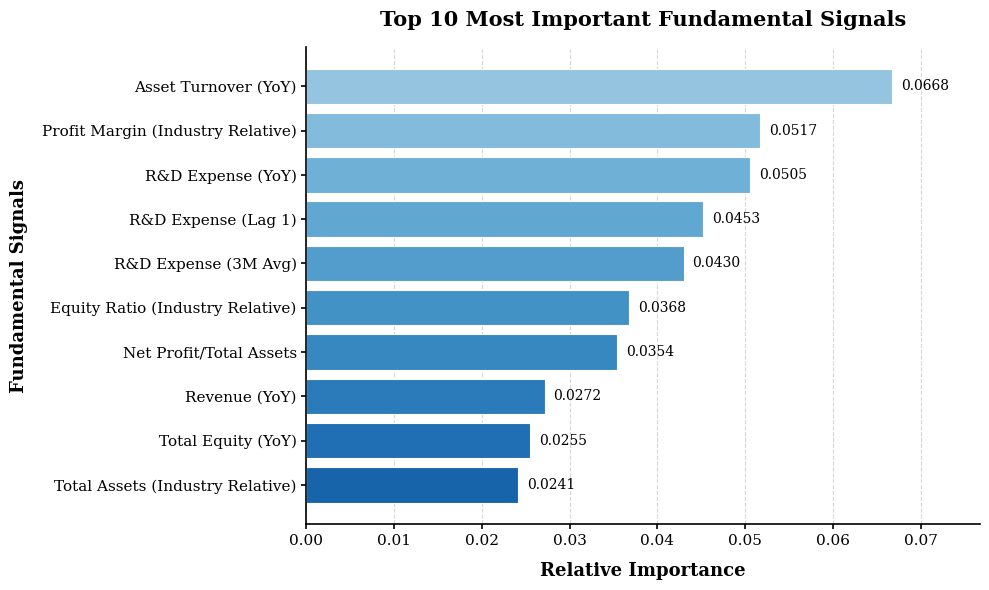

In [197]:
import matplotlib.pyplot as plt
import matplotlib as mpl

# ===================== 全局样式配置（学术期刊标准） =====================
# 设置字体（支持中文+英文，避免乱码）
plt.rcParams['font.sans-serif'] = ['Times New Roman', 'SimHei']  # 英文优先，中文兜底
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题
plt.rcParams['font.family'] = 'serif'  # 学术论文常用衬线字体

# 设置全局样式
mpl.rcParams['axes.linewidth'] = 1.2  # 坐标轴宽度
mpl.rcParams['xtick.major.width'] = 1.2  # x轴刻度宽度
mpl.rcParams['ytick.major.width'] = 1.2  # y轴刻度宽度
mpl.rcParams['grid.linewidth'] = 0.8  # 网格线宽度
mpl.rcParams['grid.alpha'] = 0.3  # 网格透明度

# ===================== 数据准备 =====================
# 信号名称（优化为更简洁的学术命名，可根据论文需求调整）
signals = [
    'Asset Turnover (YoY)',
    'Profit Margin (Industry Relative)',
    'R&D Expense (YoY)',
    'R&D Expense (Lag 1)',
    'R&D Expense (3M Avg)',
    'Equity Ratio (Industry Relative)',
    'Net Profit/Total Assets',
    'Revenue (YoY)',
    'Total Equity (YoY)',
    'Total Assets (Industry Relative)'
]
importances = [
    0.066772, 0.051730, 0.050542, 0.045253, 0.043012,
    0.036751, 0.035421, 0.027158, 0.025530, 0.024132
]

# ===================== 绘图 =====================
fig, ax = plt.subplots(figsize=(10, 6))  # 调整画布比例（更适配论文排版）

# 绘制水平条形图（渐变配色+精准数值标注）
colors = plt.cm.Blues(np.linspace(0.4, 0.8, len(signals)))  # 蓝色系渐变（学术常用）
bars = ax.barh(
    signals[::-1],  # 倒序显示（重要性从高到低）
    importances[::-1],
    color=colors[::-1],
    edgecolor='white',  # 条形边缘白色描边，提升层次感
    linewidth=0.8
)

# ===================== 细节优化 =====================
# 1. 坐标轴标签（学术字体大小+加粗）
ax.set_xlabel('Relative Importance', fontsize=13, fontweight='bold', labelpad=10)
ax.set_ylabel('Fundamental Signals', fontsize=13, fontweight='bold', labelpad=10)

# 2. 标题（居中+字体层级）
ax.set_title(
    'Top 10 Most Important Fundamental Signals',
    fontsize=15, fontweight='bold', pad=15, loc='center'
)

# 3. 数值标注（精准对齐+字体大小）
for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 0.001,  # 数值与条形图间距
        bar.get_y() + bar.get_height()/2,  # 垂直居中
        f'{width:.4f}',  # 保留4位小数（学术精度）
        ha='left', va='center',  # 对齐方式
        fontsize=10, fontweight='normal'
    )

# 4. 网格线（仅x轴+虚线+低透明度）
ax.grid(axis='x', linestyle='--', alpha=0.5)
ax.set_axisbelow(True)  # 网格线置于条形图下方

# 5. 坐标轴刻度（字体大小+移除顶部/右侧边框）
ax.tick_params(axis='x', labelsize=11)
ax.tick_params(axis='y', labelsize=11)
ax.spines['top'].set_visible(False)  # 隐藏顶部边框
ax.spines['right'].set_visible(False)  # 隐藏右侧边框
ax.spines['left'].set_linewidth(1.2)  # 左侧边框加粗
ax.spines['bottom'].set_linewidth(1.2)  # 底部边框加粗

# 6. x轴范围（留出数值标注空间）
ax.set_xlim(0, max(importances) + 0.01)

# ===================== 保存与显示 =====================
# 保存为高分辨率图片（适配论文印刷，支持eps矢量图）
plt.tight_layout()  # 自动调整布局
plt.savefig(
    'feature_importance_academic.png',
    dpi=600,  # 600DPI 高清（学术期刊要求）
    bbox_inches='tight',  # 去除多余空白
    facecolor='white'  # 背景白色（避免导出透明背景）
)
# 可选：保存为矢量图（LaTeX论文推荐）
# plt.savefig('feature_importance_academic.eps', format='eps', bbox_inches='tight')

plt.show()

不同信号数量的策略表现对比（30 vs 100 信号）

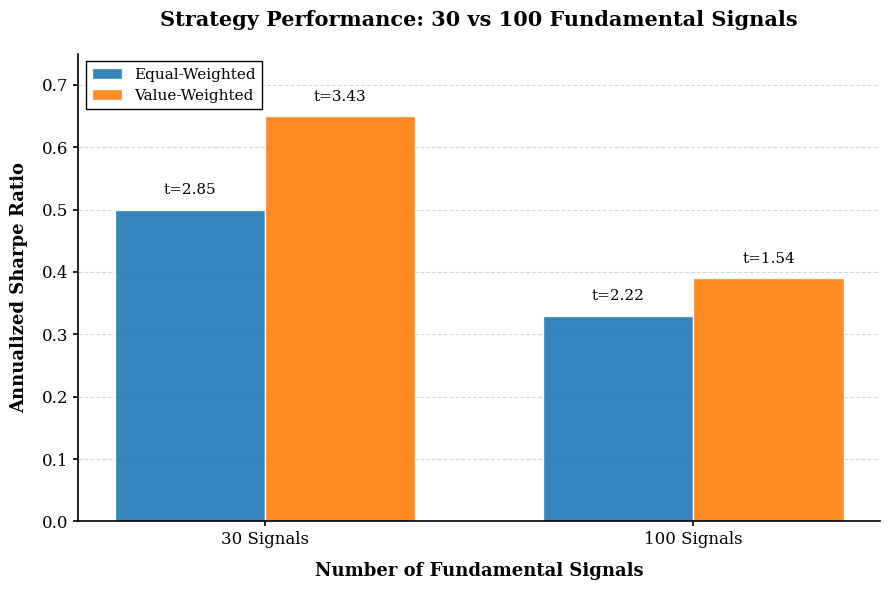

In [200]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# ===================== 全局学术样式配置 =====================
# 字体设置（支持中英文，学术期刊标准）
plt.rcParams['font.sans-serif'] = ['Times New Roman', 'SimHei']  # 英文优先，中文兜底
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题
plt.rcParams['font.family'] = 'serif'  # 衬线字体更符合学术风格

# 全局线条/网格样式
mpl.rcParams['axes.linewidth'] = 1.2    # 坐标轴边框宽度
mpl.rcParams['xtick.major.width'] = 1.2 # x轴刻度宽度
mpl.rcParams['ytick.major.width'] = 1.2 # y轴刻度宽度
mpl.rcParams['grid.linewidth'] = 0.8    # 网格线宽度
mpl.rcParams['grid.alpha'] = 0.3        # 网格透明度
mpl.rcParams['legend.framealpha'] = 1.0 # 图例背景不透明
mpl.rcParams['legend.edgecolor'] = 'black' # 图例边框

# ===================== 数据准备 =====================
data = {
    'Signals': ['30', '100', '30', '100'],
    'Weight': ['Equal', 'Equal', 'Value', 'Value'],
    'Sharpe': [0.5, 0.33, 0.65, 0.39],  # 替换为你的真实 SR
    't_stat': [2.85, 2.22, 3.43, 1.54]   # 替换为你的真实 t 值
}
df_sr = pd.DataFrame(data)

# ===================== 绘图核心逻辑 =====================
fig, ax1 = plt.subplots(figsize=(9, 6))  # 优化画布比例（适配论文排版）

# 分组柱状图配置
x = np.arange(2)  # 30/100信号两组
width = 0.35      # 柱子宽度（学术图表适中比例）

# 提取数据
sr_eq = df_sr[df_sr['Weight'] == 'Equal']['Sharpe'].values
sr_vw = df_sr[df_sr['Weight'] == 'Value']['Sharpe'].values
t_eq = df_sr[df_sr['Weight'] == 'Equal']['t_stat'].values
t_vw = df_sr[df_sr['Weight'] == 'Value']['t_stat'].values

# 绘制柱状图（学术配色+描边提升质感）
colors = ['#1f77b4', '#ff7f0e']  # 蓝/橙配色（金融顶刊常用，辨识度高）
bar1 = ax1.bar(
    x - width/2, sr_eq, width, 
    label='Equal-Weighted', color=colors[0], 
    edgecolor='white', linewidth=1.0, alpha=0.9
)
bar2 = ax1.bar(
    x + width/2, sr_vw, width, 
    label='Value-Weighted', color=colors[1], 
    edgecolor='white', linewidth=1.0, alpha=0.9
)

# ===================== 学术级细节优化 =====================
# 1. 坐标轴与标题（分级字体大小+加粗）
ax1.set_xlabel('Number of Fundamental Signals', fontsize=13, fontweight='bold', labelpad=10)
ax1.set_ylabel('Annualized Sharpe Ratio', fontsize=13, fontweight='bold', labelpad=10)
ax1.set_title(
    'Strategy Performance: 30 vs 100 Fundamental Signals',
    fontsize=15, fontweight='bold', pad=20, loc='center'
)

# 2. X轴刻度（清晰标注+字体大小）
ax1.set_xticks(x)
ax1.set_xticklabels(['30 Signals', '100 Signals'], fontsize=12)
ax1.tick_params(axis='y', labelsize=12)

# 3. 网格线（仅Y轴+虚线+低透明度，避免干扰）
ax1.grid(axis='y', linestyle='--', alpha=0.5)
ax1.set_axisbelow(True)  # 网格线置于柱状图下方

# 4. 移除冗余边框（仅保留左/下边框，学术简洁风格）
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_linewidth(1.2)
ax1.spines['bottom'].set_linewidth(1.2)

# 5. 精准标注t统计量（学术精度+位置优化）
# 等权组合t值标注
for i, (sr, t) in enumerate(zip(sr_eq, t_eq)):
    ax1.text(
        i - width/2, sr + 0.02,  # 位置：柱子顶部+微小偏移
        f't={t:.2f}',            # 保留2位小数（计量学标准）
        ha='center', va='bottom', fontsize=11, fontweight='normal',
        color='black'            # 黑色标注更清晰
    )
# 市值加权组合t值标注
for i, (sr, t) in enumerate(zip(sr_vw, t_vw)):
    ax1.text(
        i + width/2, sr + 0.02,
        f't={t:.2f}',
        ha='center', va='bottom', fontsize=11, fontweight='normal',
        color='black'
    )

# 6. 图例优化（位置+字体+边框）
ax1.legend(
    loc='upper left',  # 位置：左上不遮挡数据
    fontsize=11, 
    frameon=True,     # 显示图例边框
    edgecolor='black',# 边框黑色
    fancybox=False,   # 直角边框（学术风格）
    shadow=False      # 无阴影
)

# 7. Y轴范围优化（留出标注空间，避免顶格）
y_max = max(max(sr_eq), max(sr_vw)) + 0.1
ax1.set_ylim(0, y_max)

# ===================== 高清保存（适配论文印刷） =====================
plt.tight_layout()  # 自动调整布局，避免标签截断
plt.savefig(
    'signal_count_comparison_academic.png',
    dpi=600,                # 600DPI高清（期刊印刷要求）
    bbox_inches='tight',    # 去除多余空白
    facecolor='white',      # 背景白色（避免透明背景）
    edgecolor='none'        # 无边缘色
)
# 可选：保存为矢量图（LaTeX排版无像素损失）
# plt.savefig('signal_count_comparison_academic.eps', format='eps', bbox_inches='tight')

plt.show()

风险调整后 alpha 的热力图

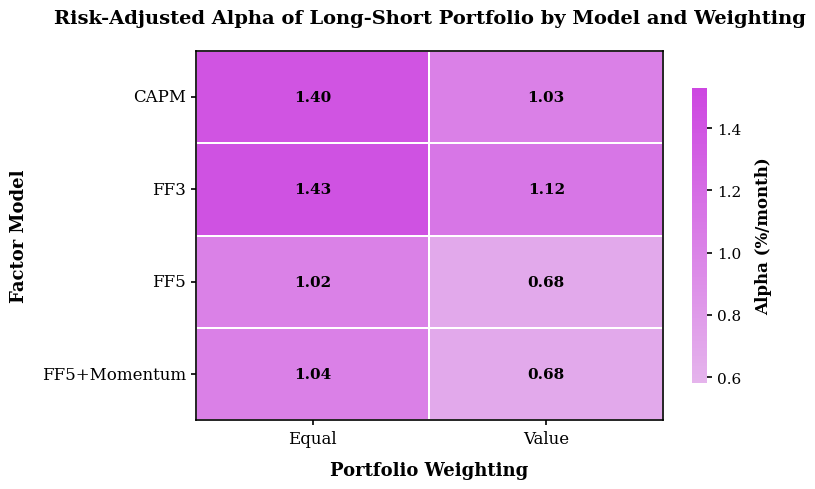

In [208]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl

# ===================== 全局学术样式配置 =====================
# 字体设置（支持中英文，学术期刊标准）
plt.rcParams['font.sans-serif'] = ['Times New Roman', 'SimHei']  # 英文优先，中文兜底
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题
plt.rcParams['font.family'] = 'serif'       # 衬线字体更符合学术风格

# 全局线条/网格样式
mpl.rcParams['axes.linewidth'] = 1.2    # 坐标轴边框宽度
mpl.rcParams['xtick.major.width'] = 1.2 # x轴刻度宽度
mpl.rcParams['ytick.major.width'] = 1.2 # y轴刻度宽度
mpl.rcParams['grid.linewidth'] = 0.8    # 网格线宽度
mpl.rcParams['grid.alpha'] = 0.3        # 网格透明度

data = {
    '分组': ['10-1', '10-1', '10-1', '10-1', '10-1（多空）', '10-1（多空）', '10-1（多空）', '10-1（多空）'],
    '模型': ['CAPM', 'FF3', 'FF5', 'FF5+Momentum', 'CAPM', 'FF3', 'FF5', 'FF5+Momentum'],
    '加权方式': ['Equal','Equal', 'Equal','Equal', 'Value', 'Value', 'Value', 'Value'],
    'Alpha(月均，%)': ['1.40', '1.43', '1.02', '1.04', '1.03', '1.12', '0.68', '0.68']
}
table2 = pd.DataFrame(data)

# ===================== 数据预处理（与原逻辑一致，优化鲁棒性） =====================
# 1. 只保留多空组合（10-1）
df_ls = table2[table2['分组'].isin(['10-1', '10-1（多空）'])].copy()

# 2. 提取 alpha（去掉显著性星号，增加异常值处理）
df_ls['Alpha_num'] = df_ls['Alpha(月均，%)'].str.replace(r'[***\*\s]', '', regex=True)
df_ls['Alpha_num'] = pd.to_numeric(df_ls['Alpha_num'], errors='coerce').fillna(0)

# 3. 透视：行=模型，列=加权方式，值=alpha（排序优化）
# 定义模型顺序（符合金融计量学惯例）
model_order = ['CAPM', 'FF3', 'FF5', 'FF5+Momentum']
# 定义加权方式顺序
weight_order = ['Equal','Value'] if 'Equal' in df_ls['加权方式'].unique() else ['E', 'V']

alpha_pivot = df_ls.pivot(index='模型', columns='加权方式', values='Alpha_num')
# 重新排序行和列
alpha_pivot = alpha_pivot.reindex(model_order)
alpha_pivot = alpha_pivot[weight_order]

# ===================== 绘制学术级热力图（修复labelpad错误） =====================
fig, ax = plt.subplots(figsize=(8, 5))  # 优化画布比例（适配论文排版）

# 自定义配色方案（金融顶刊风格：绿=正Alpha，红=负Alpha，白=0）
cmap = sns.diverging_palette(145, 300, s=80, l=55, sep=10, as_cmap=True)

# 绘制热力图（核心修复：移除cbar_kws中的labelpad参数）
heatmap = sns.heatmap(
    alpha_pivot,
    annot=True,                # 显示数值
    fmt='.2f',                 # 保留2位小数（学术精度）
    cmap=cmap,                 # 自定义配色
    center=0,                  # 0为中心（正负Alpha对比）
    cbar_kws={
        'label': 'Alpha (%/month)',  # 色条标签
        'orientation': 'vertical',   # 垂直色条
        'shrink': 0.8,               # 色条缩放（适配画布）
        'pad': 0.05                 # 色条与热力图间距
    },
    ax=ax,
    linewidths=1.2,            # 单元格边框宽度（提升清晰度）
    linecolor='white',         # 单元格边框白色（学术风格）
    annot_kws={
        'fontsize': 11,        # 标注字体大小
        'fontweight': 'bold',  # 标注加粗（易读）
        'color': 'black'       # 标注黑色（对比鲜明）
    },
    vmin=alpha_pivot.min().min() - 0.1,  # 最小值下限（避免顶格）
    vmax=alpha_pivot.max().max() + 0.1   # 最大值上限（避免顶格）
)

# ===================== 学术级细节优化 =====================
# 1. 标题与轴标签（分级字体+加粗）
ax.set_title(
    'Risk-Adjusted Alpha of Long-Short Portfolio by Model and Weighting',
    fontsize=14, fontweight='bold', pad=20, loc='center'
)
ax.set_ylabel('Factor Model', fontsize=13, fontweight='bold', labelpad=10)
ax.set_xlabel('Portfolio Weighting', fontsize=13, fontweight='bold', labelpad=10)

# 2. 刻度优化（字体大小+旋转）
ax.set_xticklabels(ax.get_xticklabels(), fontsize=12, rotation=0)  # X轴刻度不旋转
ax.set_yticklabels(ax.get_yticklabels(), fontsize=12, rotation=0)  # Y轴刻度不旋转

# 3. 色条标签优化（单独设置colorbar的标签属性，替代labelpad）
cbar = heatmap.collections[0].colorbar
cbar.set_label('Alpha (%/month)', fontsize=12, fontweight='bold', labelpad=10)  # 这里用labelpad是合法的
cbar.ax.tick_params(labelsize=11)  # 色条刻度字体大小

# 4. 边框优化（仅保留外边框，学术简洁风格）
for _, spine in ax.spines.items():
    spine.set_visible(True)
    spine.set_linewidth(1.2)
    spine.set_color('black')

# ===================== 高清保存（适配论文印刷） =====================
plt.tight_layout()  # 自动调整布局，避免标签截断
plt.savefig(
    'alpha_heatmap_academic.png',
    dpi=600,                # 600DPI高清（期刊印刷要求）
    bbox_inches='tight',    # 去除多余空白
    facecolor='white',      # 背景白色（避免透明背景）
    edgecolor='none'        # 无边缘色
)
# 可选：保存为矢量图（LaTeX排版无像素损失）
# plt.savefig('alpha_heatmap_academic.eps', format='eps', bbox_inches='tight')

plt.show()